1. EDA
   - 데이터 구조 확인
   - 결측치/타입 확인
   - 전체 이탈률 확인
   - Contract, tenure, MonthlyCharges, PaymentMethod 등과 Churn의 관계 분석
   - 이탈 위험 요인 후보 도출
   -
(1) 전체 컬럼을 하나씩 확인한다.
(2). 각 컬럼별 이탈률을 비교한다.
(3) 의미가 비슷한 컬럼들을 묶어서 해석한다.
(4) 그중 이탈률 차이가 큰 Feature를 주요 이탈 요인 후보로 선정한다.
(5) 이후 Logistic Regression, Decision Tree, LightGBM에서 그 요인들이 실제로 중요한지 확인한다.

2. 데이터 전처리
   - customerID 등 불필요한 변수 제거
   - TotalCharges 숫자형 변환 및 결측 처리
   - Churn을 0/1로 변환
   - 범주형 변수 인코딩
   - Train/Test 데이터 분리

3. Logistic Regression Baseline
   - 가장 기본적인 기준 모델 학습
   - Accuracy, Recall, Precision, F1 등 성능 확인
   - 계수를 통해 이탈 가능성을 높이는 변수 해석

4. Decision Tree 기반 세그먼테이션
   - 이탈률이 높은 고객군을 조건 기반으로 분리
   - 해석 가능한 고위험군 규칙 도출
   - 예: Month-to-month + 짧은 tenure + TechSupport 없음

5. Random Forest 모델
   - 더 성능 좋은 모델 학습

   
6.  LightGBM 모델
   - 더 성능 좋은 모델 학습

7. Feature Importance 또는 SHAP으로 주요 이탈 요인 재확인   


8. 리텐션 전략 제안
   - 고위험군별 맞춤 전략 제안
   - 예: 단기 계약 고객 → 장기 계약 전환 혜택
   - TechSupport 미사용 고객 → 무료 기술지원 체험 제공
   - 고요금 고객 → 요금제 최적화 추천

# 1. EDA
* 데이터 구조 확인
* 결측치/타입 확인
* 전체 이탈률 확인
* Contract, tenure, MonthlyCharges, PaymentMethod 등과 Churn의 관계 분석
* 이탈 위험 요인 후보 도출
* 세부 분석 순서:
  1. 전체 컬럼을 하나씩 확인한다.
  2. 각 컬럼별 이탈률을 비교한다.
  3. 의미가 비슷한 컬럼들을 묶어서 해석한다.
  4. 그중 이탈률 차이가 큰 Feature를 주요 이탈 요인 후보로 선정한다.
  5. 이후 Logistic Regression, Decision Tree, LightGBM에서 그 요인들이 실제로 중요한지 확인한다.


##1-1. 데이터 형태 확인하기 Data Profiling


In [23]:
# =========================
# 1-1. 데이터 형태 확인하기 Data Profiling
# =========================

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 200)

# 구글드라이브 내 프로젝트 폴더 경로
folder_path = "/content/drive/MyDrive/AI@Sogang_mini_project_2"

# 폴더 안 파일 목록 확인
print("폴더 안 파일 목록:")
print(os.listdir(folder_path))

# 데이터 파일 경로
file_path = folder_path + "/telco_churn_with_income.csv"

# 데이터 불러오기
df = pd.read_csv(file_path)

# 원본 보존용 복사본 생성
df_eda = df.copy()

# Total Charges는 숫자형 변수인데 문자열로 저장되어 있을 가능성이 있으므로 변환
df_eda["Total Charges"] = pd.to_numeric(df_eda["Total Charges"], errors="coerce")

print("\n데이터 불러오기 완료")
print("데이터 크기:", df_eda.shape)

print("\n상위 5개 행:")
display(df_eda.head())

# 컬럼별 데이터 타입, 결측치, 고유값 개수, 예시값 확인
profile_table = pd.DataFrame({
    "dtype": df_eda.dtypes,
    "missing_count": df_eda.isnull().sum(),
    "missing_rate(%)": (df_eda.isnull().mean() * 100).round(2),
    "unique_count": df_eda.nunique()
})

example_values = []

for col in df_eda.columns:
    examples = df_eda[col].dropna().unique()[:5]
    example_values.append(list(examples))

profile_table["example_values"] = example_values

print("\n컬럼별 요약 정보:")
display(profile_table)

print("\n수치형 변수 기초 통계:")
display(df_eda.describe())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
폴더 안 파일 목록:
['telco_churn_with_income.csv']

데이터 불러오기 완료
데이터 크기: (7043, 38)

상위 5개 행:


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason,Area_Total_Households,Area_Median_Income,Area_Mean_Income,Income_Charge_Ratio,Area_Income_Level
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer,17782.0,56030.0,70030.0,0.011533,Medium
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved,18289.0,49419.0,83299.0,0.017167,Medium
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,Yes,1,86,5372,Moved,19709.0,51998.0,69243.0,0.022997,Medium
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved,2696.0,101455.0,132434.0,0.012396,High
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,Yes,1,89,5340,Competitor had better devices,13366.0,69268.0,106533.0,0.017965,Medium



컬럼별 요약 정보:


,dtype,missing_count,missing_rate(%),unique_count,example_values
CustomerID,object,0,0.00,7043,"[3668-QPYBK, 9237-HQITU, 9305-CDSKC, 7892-POOK..."
Count,int64,0,0.00,1,[1]
Country,object,0,0.00,1,[United States]
State,object,0,0.00,1,[California]
City,object,0,0.00,1129,"[Los Angeles, Beverly Hills, Huntington Park, ..."
Zip Code,int64,0,0.00,1652,"[90003, 90005, 90006, 90010, 90015]"
Lat Long,object,0,0.00,1652,"[33.964131, -118.272783, 34.059281, -118.30742..."
Latitude,float64,0,0.00,1652,"[33.964131, 34.059281, 34.048013, 34.062125, 3..."
Longitude,float64,0,0.00,1651,"[-118.272783, -118.30742, -118.293953, -118.31..."
Gender,object,0,0.00,2,"[Male, Female]"



수치형 변수 기초 통계:


,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Total Charges,Churn Value,Churn Score,CLTV,Area_Total_Households,Area_Median_Income,Area_Mean_Income,Income_Charge_Ratio
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7032.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,2283.300441,0.265370,58.699418,4400.295755,8225.588244,98805.827772,130776.798665,0.009190
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,2266.771362,0.441561,21.525131,1183.057152,7485.946881,39088.344545,62385.215449,0.006162
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,18.800000,0.000000,5.000000,2003.000000,0.000000,13333.000000,18550.000000,0.000941
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,401.450000,0.000000,40.000000,3469.000000,796.000000,72445.000000,90036.000000,0.004493
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,1397.475000,0.000000,61.000000,4527.000000,7076.000000,92854.500000,117555.500000,0.008200
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,3794.737500,1.000000,75.000000,5380.500000,13759.000000,116667.000000,155024.000000,0.012318
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,8684.800000,1.000000,100.000000,6500.000000,32594.000000,246045.000000,579268.000000,0.058786


> 본 데이터는 7043명의 고객과 38개의 변수로 구성되어 있으며, 고객의 서비스 이용 정보, 계약/결제 정보, 요금 정보, 지역 소득 정보, 이탈 여부를 포함한다. 대부분의 변수에는 결측치가 없었으나, `Total Charges`에는 11개의 결측치가 존재했고 `Churn Reason`은 이탈 고객에게만 존재하는 사후 정보이므로 모델 학습에서는 제외한다.
---

##1-2. 타깃 변수 확인 및 전체 이탈률 분석

Churn Label 분포:


,count
Churn Label,
No,5174
Yes,1869



Churn Value 분포:


,count
Churn Value,
0,5174
1,1869



Churn Label과 Churn Value 교차표:


Churn Value,0,1
Churn Label,,
No,5174,0
Yes,0,1869


전체 고객 수: 7043
이탈 고객 수: 1869
비이탈 고객 수: 5174
전체 이탈률: 26.54%


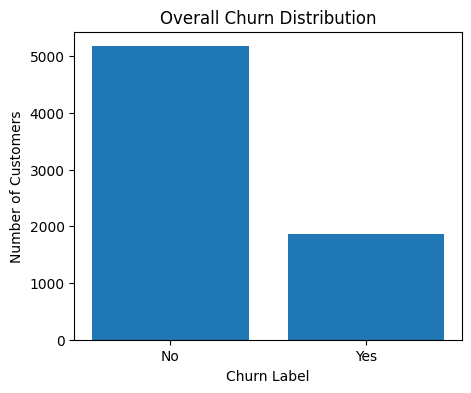

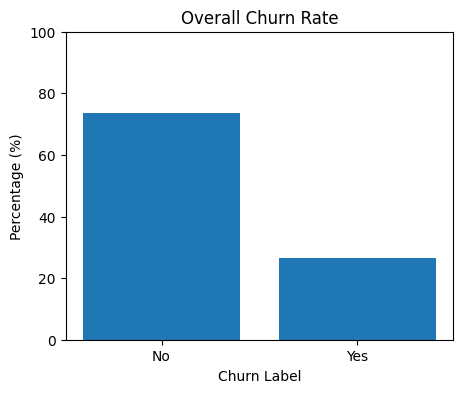

,percentage(%)
Churn Label,
No,73.46
Yes,26.54


In [24]:
# =========================
# 1-2. 타깃 변수 확인 및 전체 이탈률 분석
# =========================

target = "Churn Value"

print("Churn Label 분포:")
display(df_eda["Churn Label"].value_counts())

print("\nChurn Value 분포:")
display(df_eda["Churn Value"].value_counts())

print("\nChurn Label과 Churn Value 교차표:")
display(pd.crosstab(df_eda["Churn Label"], df_eda["Churn Value"]))

# 전체 이탈률 계산
total_customers = len(df_eda)
churn_customers = df_eda[target].sum()
non_churn_customers = total_customers - churn_customers
overall_churn_rate = df_eda[target].mean() * 100

print(f"전체 고객 수: {total_customers}")
print(f"이탈 고객 수: {churn_customers}")
print(f"비이탈 고객 수: {non_churn_customers}")
print(f"전체 이탈률: {overall_churn_rate:.2f}%")

# 전체 이탈 분포 시각화
churn_counts = df_eda["Churn Label"].value_counts()

plt.figure(figsize=(5, 4))
plt.bar(churn_counts.index, churn_counts.values)
plt.title("Overall Churn Distribution")
plt.xlabel("Churn Label")
plt.ylabel("Number of Customers")
plt.show()

# 이탈률 비율 그래프
churn_rate_table = df_eda["Churn Label"].value_counts(normalize=True).mul(100).round(2)

plt.figure(figsize=(5, 4))
plt.bar(churn_rate_table.index, churn_rate_table.values)
plt.title("Overall Churn Rate")
plt.xlabel("Churn Label")
plt.ylabel("Percentage (%)")
plt.ylim(0, 100)
plt.show()

display(churn_rate_table.to_frame(name="percentage(%)"))

> 전체 7043명의 고객 중 이탈 고객은 1869명으로, 전체 이탈률은 26.54%로 나타났다. `Churn Label`과 `Churn Value`가 정확히 대응하므로 이후 분석에서는 `Churn Value`를 이탈 여부를 나타내는 타깃 변수로 사용한다.
---

##1-3. 전체 컬럼을 분석 가능 / 제외 / 주의 컬럼으로 분류하기

이번 단계는 바로 이탈률 계산으로 들어가기 전에,
어떤 컬럼을 EDA에서 볼지, 어떤 컬럼은 모델에서 제외할지 정리하는 단계

In [25]:
# =========================
# 1-3. 전체 컬럼을 분석 가능 / 제외 / 주의 컬럼으로 분류하기
# =========================

target_col = "Churn Value"

# 모델 학습에서 제외할 컬럼
exclude_model_cols = [
    "CustomerID",      # 고객 식별자
    "Count",           # 모든 값이 1
    "Country",         # 모든 값이 United States
    "State",           # 모든 값이 California
    "Churn Label",     # Churn Value와 같은 정보
    "Churn Value",     # 타깃 변수
    "Churn Score",     # 이탈 가능성과 직접 연결된 누수 가능 변수
    "Churn Reason",    # 이탈 후에 알 수 있는 사후 정보
    "Lat Long"         # Latitude, Longitude와 중복되는 위치 정보
]

# EDA에서는 확인 가능하지만, 모델 학습에서는 조심해야 하는 컬럼
caution_cols = [
    "City",
    "Zip Code",
    "Latitude",
    "Longitude"
]

# 의미 기반 컬럼 그룹
column_groups = {
    "식별자/상수/중복 정보": [
        "CustomerID", "Count", "Country", "State", "Lat Long"
    ],
    "지역 정보": [
        "City", "Zip Code", "Latitude", "Longitude"
    ],
    "고객 인구통계 정보": [
        "Gender", "Senior Citizen", "Partner", "Dependents"
    ],
    "기본 서비스 정보": [
        "Phone Service", "Multiple Lines", "Internet Service"
    ],
    "보안/지원 서비스 정보": [
        "Online Security", "Online Backup", "Device Protection", "Tech Support"
    ],
    "콘텐츠 부가서비스 정보": [
        "Streaming TV", "Streaming Movies"
    ],
    "계약/결제 정보": [
        "Contract", "Paperless Billing", "Payment Method"
    ],
    "기간/요금/고객가치 정보": [
        "Tenure Months", "Monthly Charges", "Total Charges", "CLTV"
    ],
    "지역 소득 정보": [
        "Area_Total_Households", "Area_Median_Income", "Area_Mean_Income",
        "Income_Charge_Ratio", "Area_Income_Level"
    ],
    "이탈 관련 정보": [
        "Churn Label", "Churn Value", "Churn Score", "Churn Reason"
    ]
}

# 컬럼별 그룹명 찾기 함수
def find_group(col):
    for group_name, cols in column_groups.items():
        if col in cols:
            return group_name
    return "기타"

# 컬럼별 사용 목적 분류 함수
def assign_role(col):
    if col == target_col:
        return "타깃 변수"
    elif col in ["Churn Score", "Churn Reason", "Churn Label"]:
        return "누수/사후정보로 모델 제외"
    elif col in ["CustomerID", "Count", "Country", "State", "Lat Long"]:
        return "정보량 부족/중복으로 모델 제외"
    elif col in caution_cols:
        return "EDA 참고, 모델 사용 주의"
    else:
        return "EDA 및 모델 후보"

# 분류표 생성
column_role_table = pd.DataFrame({
    "column": df_eda.columns,
    "group": [find_group(col) for col in df_eda.columns],
    "dtype": [df_eda[col].dtype for col in df_eda.columns],
    "missing_count": [df_eda[col].isnull().sum() for col in df_eda.columns],
    "unique_count": [df_eda[col].nunique() for col in df_eda.columns],
    "role": [assign_role(col) for col in df_eda.columns]
})

display(column_role_table)

print("역할별 컬럼 개수:")
display(column_role_table["role"].value_counts())

print("그룹별 컬럼 개수:")
display(column_role_table["group"].value_counts())

# 이후 EDA에서 사용할 후보 컬럼 목록
eda_candidate_cols = column_role_table[
    column_role_table["role"].isin(["EDA 및 모델 후보", "EDA 참고, 모델 사용 주의"])
]["column"].tolist()

model_candidate_cols = column_role_table[
    column_role_table["role"] == "EDA 및 모델 후보"
]["column"].tolist()

print("\nEDA에서 확인할 후보 컬럼:")
print(eda_candidate_cols)

print("\n모델 학습 후보 컬럼:")
print(model_candidate_cols)

,column,group,dtype,missing_count,unique_count,role
0,CustomerID,식별자/상수/중복 정보,object,0,7043,정보량 부족/중복으로 모델 제외
1,Count,식별자/상수/중복 정보,int64,0,1,정보량 부족/중복으로 모델 제외
2,Country,식별자/상수/중복 정보,object,0,1,정보량 부족/중복으로 모델 제외
3,State,식별자/상수/중복 정보,object,0,1,정보량 부족/중복으로 모델 제외
4,City,지역 정보,object,0,1129,"EDA 참고, 모델 사용 주의"
5,Zip Code,지역 정보,int64,0,1652,"EDA 참고, 모델 사용 주의"
6,Lat Long,식별자/상수/중복 정보,object,0,1652,정보량 부족/중복으로 모델 제외
7,Latitude,지역 정보,float64,0,1652,"EDA 참고, 모델 사용 주의"
8,Longitude,지역 정보,float64,0,1651,"EDA 참고, 모델 사용 주의"
9,Gender,고객 인구통계 정보,object,0,2,EDA 및 모델 후보


역할별 컬럼 개수:


,count
role,
EDA 및 모델 후보,25
정보량 부족/중복으로 모델 제외,5
"EDA 참고, 모델 사용 주의",4
누수/사후정보로 모델 제외,3
타깃 변수,1


그룹별 컬럼 개수:


,count
group,
식별자/상수/중복 정보,5
지역 소득 정보,5
지역 정보,4
고객 인구통계 정보,4
보안/지원 서비스 정보,4
기간/요금/고객가치 정보,4
이탈 관련 정보,4
기본 서비스 정보,3
계약/결제 정보,3



EDA에서 확인할 후보 컬럼:
['City', 'Zip Code', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV', 'Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income', 'Income_Charge_Ratio', 'Area_Income_Level']

모델 학습 후보 컬럼:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'CLTV', 'Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income', 'Income_Charge_Ratio', 'Area_Income_Level']


> 전체 38개 컬럼 중 25개는 EDA 및 모델 학습 후보로 분류하였다. `CustomerID`, `Count`, `Country`, `State` 등은 식별자 또는 정보량이 낮은 변수이므로 제외하고, `Churn Score`, `Churn Reason`, `Churn Label`은 이탈과 직접 연결된 누수 가능 정보이므로 모델 학습에서 제외한다. `City`, `Zip Code`, `Latitude`, `Longitude`는 지역 정보로 EDA에서는 참고하되 고유값이 많아 모델 사용에는 주의가 필요하다.
---

##1-4. 범주형 / 수치형 변수 분리 및 단일 변수 요약

이번 단계는 아직 이탈률 비교가 아니라, 각 변수가 어떤 형태인지 정리하는 단계입니다.

즉,범주형 변수는 어떤 값이 많이 등장하는지
수치형 변수는 평균, 중앙값, 최솟값, 최댓값, 왜도 등이 어떤지 확인

In [26]:
# =========================
# 1-4. 범주형 / 수치형 변수 분리 및 단일 변수 요약
# =========================

# 1-3에서 만든 model_candidate_cols를 기준으로 분석
candidate_cols = model_candidate_cols.copy()

# 범주형 / 수치형 변수 분리
categorical_features = [
    col for col in candidate_cols
    if df_eda[col].dtype == "object"
]

numeric_features = [
    col for col in candidate_cols
    if pd.api.types.is_numeric_dtype(df_eda[col])
]

print("범주형 변수 개수:", len(categorical_features))
print(categorical_features)

print("\n수치형 변수 개수:", len(numeric_features))
print(numeric_features)


# =========================
# 범주형 변수 단일 변수 요약
# =========================

categorical_summary_list = []

for col in categorical_features:
    value_counts = df_eda[col].value_counts(dropna=False)
    total_count = len(df_eda)

    top_category = value_counts.index[0]
    top_count = value_counts.iloc[0]
    top_rate = top_count / total_count * 100

    categorical_summary_list.append({
        "feature": col,
        "unique_count": df_eda[col].nunique(dropna=False),
        "top_category": top_category,
        "top_count": top_count,
        "top_rate(%)": round(top_rate, 2),
        "missing_count": df_eda[col].isnull().sum()
    })

categorical_uni_summary = pd.DataFrame(categorical_summary_list)

print("\n범주형 변수 단일 요약:")
display(categorical_uni_summary)


# =========================
# 수치형 변수 단일 변수 요약
# =========================

numeric_summary_list = []

for col in numeric_features:
    numeric_summary_list.append({
        "feature": col,
        "count": df_eda[col].count(),
        "missing_count": df_eda[col].isnull().sum(),
        "mean": round(df_eda[col].mean(), 3),
        "median": round(df_eda[col].median(), 3),
        "std": round(df_eda[col].std(), 3),
        "min": round(df_eda[col].min(), 3),
        "q1": round(df_eda[col].quantile(0.25), 3),
        "q3": round(df_eda[col].quantile(0.75), 3),
        "max": round(df_eda[col].max(), 3),
        "skewness": round(df_eda[col].skew(), 3)
    })

numeric_uni_summary = pd.DataFrame(numeric_summary_list)

print("\n수치형 변수 단일 요약:")
display(numeric_uni_summary)

범주형 변수 개수: 17
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Area_Income_Level']

수치형 변수 개수: 8
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income', 'Income_Charge_Ratio']

범주형 변수 단일 요약:


,feature,unique_count,top_category,top_count,top_rate(%),missing_count
0,Gender,2,Male,3555,50.48,0
1,Senior Citizen,2,No,5901,83.79,0
2,Partner,2,No,3641,51.70,0
3,Dependents,2,No,5416,76.90,0
4,Phone Service,2,Yes,6361,90.32,0
5,Multiple Lines,3,No,3390,48.13,0
6,Internet Service,3,Fiber optic,3096,43.96,0
7,Online Security,3,No,3498,49.67,0
8,Online Backup,3,No,3088,43.84,0
9,Device Protection,3,No,3095,43.94,0



수치형 변수 단일 요약:


,feature,count,missing_count,mean,median,std,min,q1,q3,max,skewness
0,Tenure Months,7043,0,32.371,29.000,24.559,0.000,9.000,55.000,72.000,0.240
1,Monthly Charges,7043,0,64.762,70.350,30.090,18.250,35.500,89.850,118.750,-0.221
2,Total Charges,7032,11,2283.300,1397.475,2266.771,18.800,401.450,3794.738,8684.800,0.962
3,CLTV,7043,0,4400.296,4527.000,1183.057,2003.000,3469.000,5380.500,6500.000,-0.312
4,Area_Total_Households,7043,0,8225.588,7076.000,7485.947,0.000,796.000,13759.000,32594.000,0.620
5,Area_Median_Income,7043,0,98805.828,92854.500,39088.345,13333.000,72445.000,116667.000,246045.000,1.038
6,Area_Mean_Income,7043,0,130776.799,117555.500,62385.215,18550.000,90036.000,155024.000,579268.000,1.839
7,Income_Charge_Ratio,7043,0,0.009,0.008,0.006,0.001,0.004,0.012,0.059,1.626


> 모델 학습 후보 변수 25개를 확인한 결과, 범주형 변수는 17개, 수치형 변수는 8개로 구성되었다. 범주형 변수에서는 계약, 결제 방식, 인터넷 서비스, 보안/지원 서비스 관련 변수가 포함되며, 수치형 변수에서는 가입 기간, 월 요금, 총 요금, CLTV, 지역 소득 관련 변수가 포함된다.
---

##1-5. 범주형 변수의 개별 분포 확인

이번 단계는 아직 이탈률 비교가 아니라, 범주형 변수 자체의 분포를 보는 단계입니다.

예를 들어 Contract에서 Month-to-month 고객이 많은지, Tech Support에서 No 고객이 많은지 먼저 확인합니다.

범주형 변수별 상세 분포:


,feature,category,count,rate(%)
0,Gender,Male,3555,50.48
1,Gender,Female,3488,49.52
2,Senior Citizen,No,5901,83.79
3,Senior Citizen,Yes,1142,16.21
4,Partner,No,3641,51.70
5,Partner,Yes,3402,48.30
6,Dependents,No,5416,76.90
7,Dependents,Yes,1627,23.10
8,Phone Service,Yes,6361,90.32
9,Phone Service,No,682,9.68



범주형 변수별 최빈 category 요약:


,feature,top_category,top_count,top_rate(%)
0,Area_Income_Level,High,3393,48.18
1,Contract,Month-to-month,3875,55.02
2,Dependents,No,5416,76.90
3,Device Protection,No,3095,43.94
4,Gender,Male,3555,50.48
5,Internet Service,Fiber optic,3096,43.96
6,Multiple Lines,No,3390,48.13
7,Online Backup,No,3088,43.84
8,Online Security,No,3498,49.67
9,Paperless Billing,Yes,4171,59.22



최빈 category 비율이 높은 변수 순서:


,feature,top_category,top_count,top_rate(%)
12,Phone Service,Yes,6361,90.32
13,Senior Citizen,No,5901,83.79
2,Dependents,No,5416,76.90
9,Paperless Billing,Yes,4171,59.22
1,Contract,Month-to-month,3875,55.02
10,Partner,No,3641,51.70
4,Gender,Male,3555,50.48
8,Online Security,No,3498,49.67
16,Tech Support,No,3473,49.31
0,Area_Income_Level,High,3393,48.18


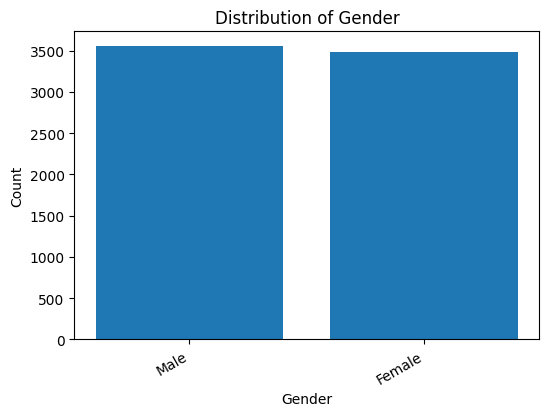

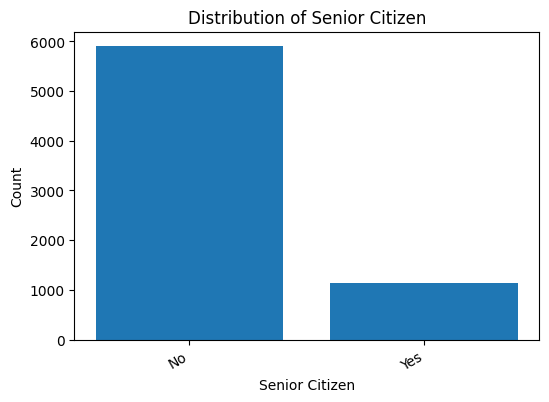

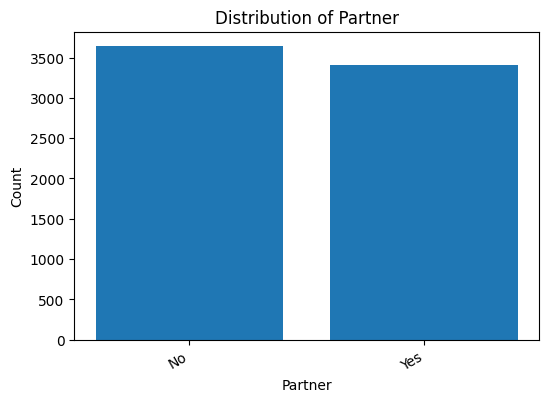

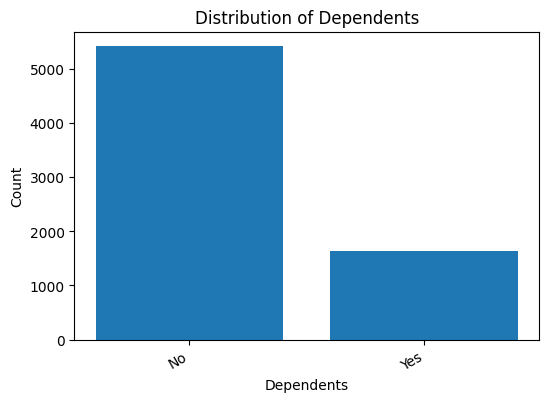

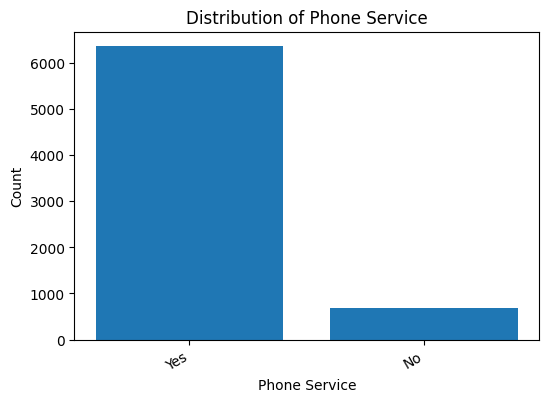

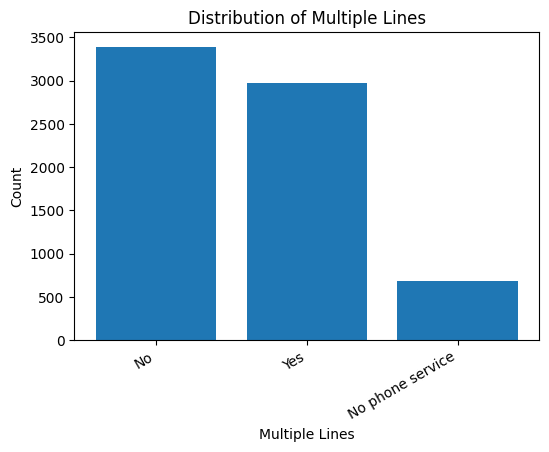

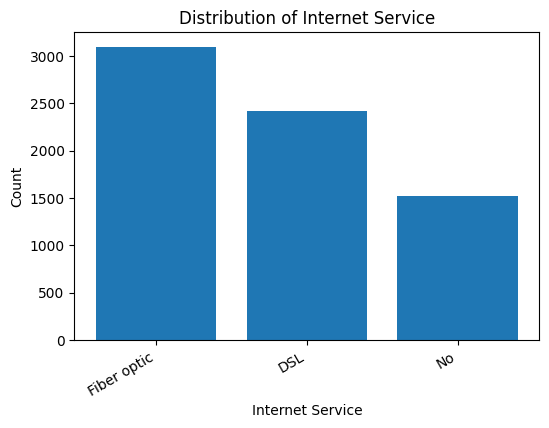

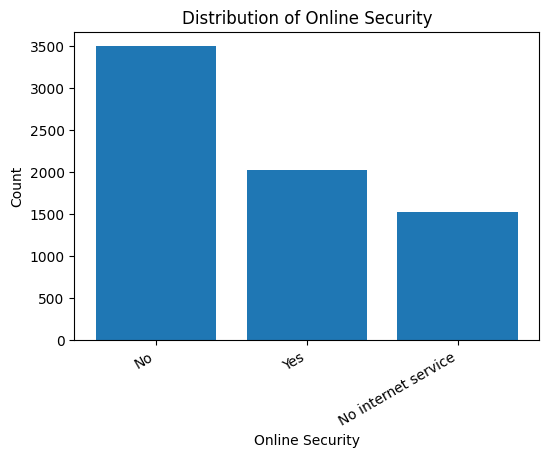

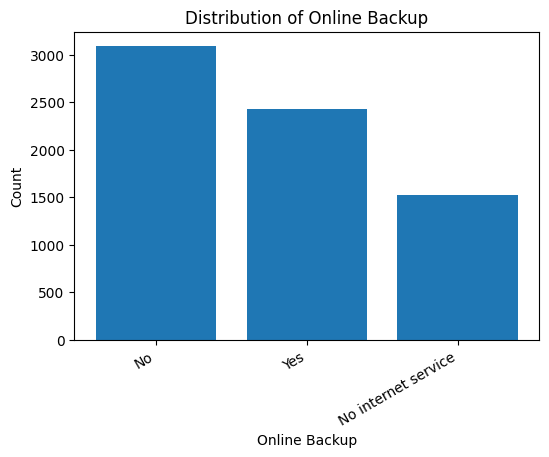

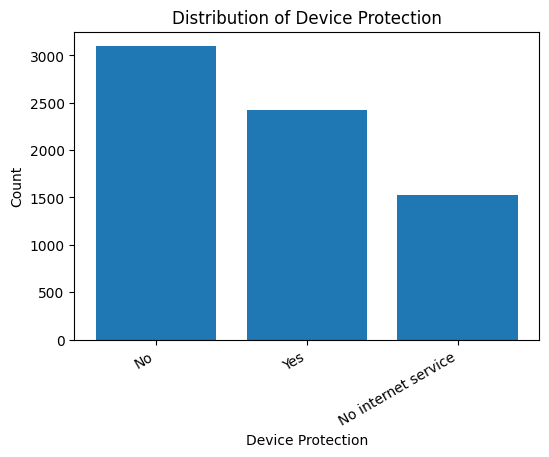

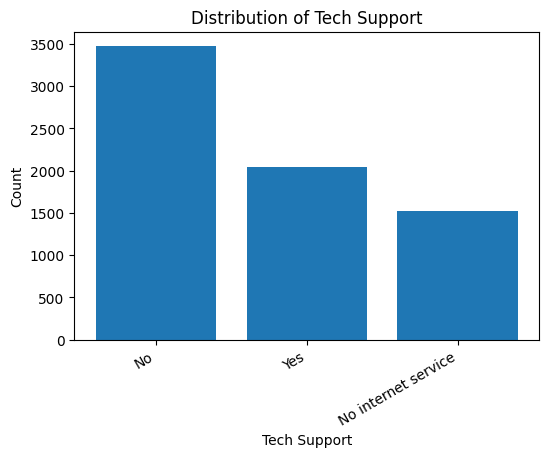

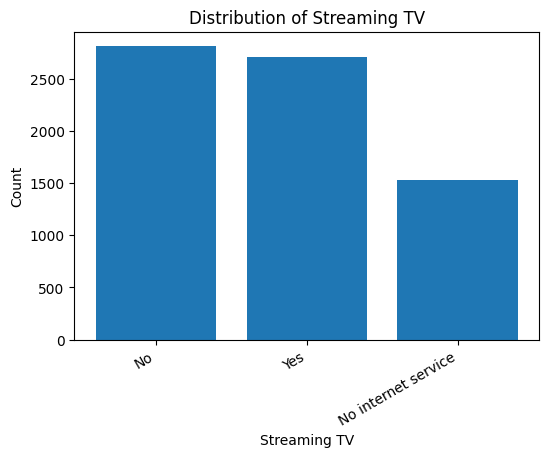

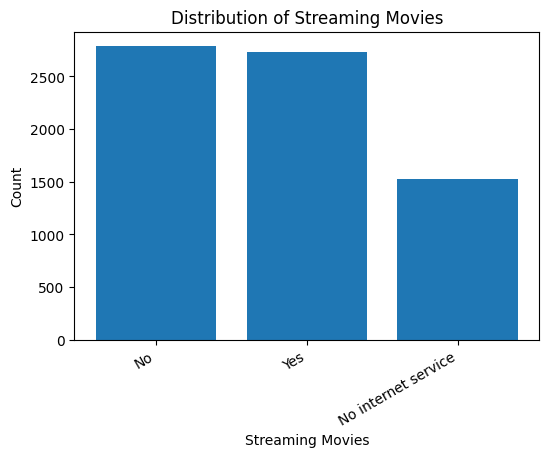

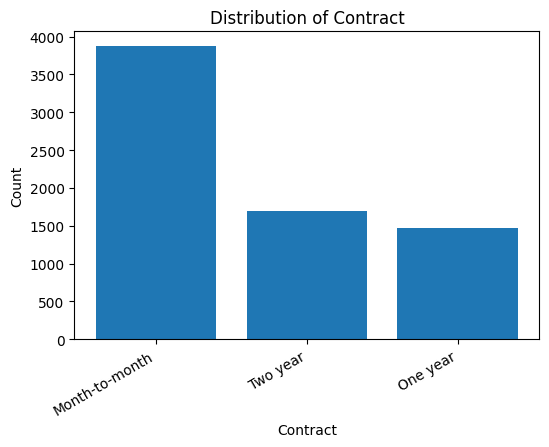

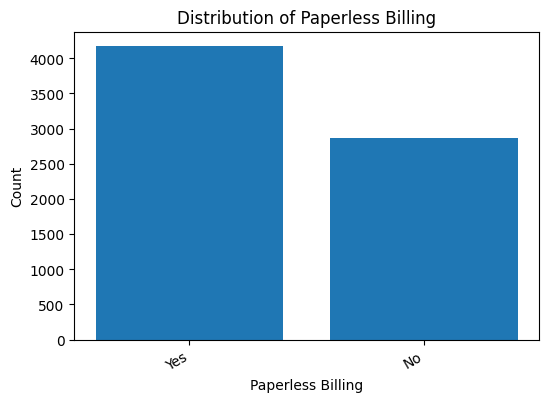

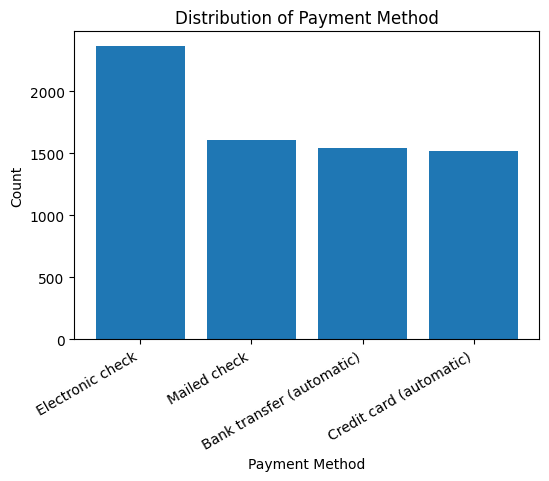

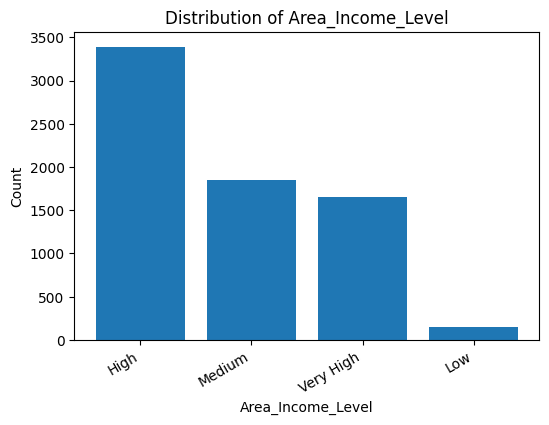

In [27]:
# =========================
# 1-5. 범주형 변수의 개별 분포 확인
# =========================

categorical_distribution_list = []

for col in categorical_features:
    temp = df_eda[col].value_counts(dropna=False).reset_index()
    temp.columns = ["category", "count"]
    temp["rate(%)"] = (temp["count"] / len(df_eda) * 100).round(2)
    temp["feature"] = col

    temp = temp[["feature", "category", "count", "rate(%)"]]
    categorical_distribution_list.append(temp)

categorical_distribution_detail = pd.concat(
    categorical_distribution_list,
    axis=0
).reset_index(drop=True)

print("범주형 변수별 상세 분포:")
display(categorical_distribution_detail)


# 변수별 최빈 category 요약
categorical_top_summary = categorical_distribution_detail.sort_values(
    ["feature", "count"],
    ascending=[True, False]
).groupby("feature").head(1).reset_index(drop=True)

categorical_top_summary = categorical_top_summary.rename(columns={
    "category": "top_category",
    "count": "top_count",
    "rate(%)": "top_rate(%)"
})

print("\n범주형 변수별 최빈 category 요약:")
display(categorical_top_summary)


# 보고서 참고용: 최빈 category 비율이 높은 변수 순서
categorical_top_summary_sorted = categorical_top_summary.sort_values(
    "top_rate(%)",
    ascending=False
)

print("\n최빈 category 비율이 높은 변수 순서:")
display(categorical_top_summary_sorted)


# 범주형 변수별 분포 그래프
for col in categorical_features:
    temp = df_eda[col].value_counts(dropna=False)

    plt.figure(figsize=(6, 4))
    plt.bar(temp.index.astype(str), temp.values)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.xticks(rotation=30, ha="right")
    plt.show()

> 범주형 변수의 분포를 확인한 결과, `Phone Service`는 Yes가 90.32%로 대부분을 차지했고, `Senior Citizen`은 No가 83.79%, `Dependents`는 No가 76.90%로 나타났다. 서비스 관련 변수에서는 `Online Security`, `Online Backup`, `Device Protection`, `Tech Support` 모두 No 비율이 가장 높았으며, 계약 정보에서는 `Month-to-month` 고객이 55.02%로 가장 많았다.
---

##1-6. 수치형 변수의 개별 분포 확인

이번 단계는 수치형 변수의 분포를 보는 단계입니다.

확인할 것:

Tenure Months가 짧은 고객이 많은지
Monthly Charges가 특정 구간에 몰려 있는지
Total Charges, CLTV, 소득 관련 변수가 한쪽으로 치우쳐 있는지
히스토그램과 박스플롯으로 이상치 가능성이 있는지

수치형 변수 목록:
['Tenure Months', 'Monthly Charges', 'Total Charges', 'CLTV', 'Area_Total_Households', 'Area_Median_Income', 'Area_Mean_Income', 'Income_Charge_Ratio']

수치형 변수 분포 요약:


,count,missing_count,mean,median,std,min,25%,50%,75%,max,skewness
Tenure Months,7043.0,0,32.371,29.000,24.559,0.000,9.000,29.000,55.000,72.000,0.240
Monthly Charges,7043.0,0,64.762,70.350,30.090,18.250,35.500,70.350,89.850,118.750,-0.221
Total Charges,7032.0,11,2283.300,1397.475,2266.771,18.800,401.450,1397.475,3794.738,8684.800,0.962
CLTV,7043.0,0,4400.296,4527.000,1183.057,2003.000,3469.000,4527.000,5380.500,6500.000,-0.312
Area_Total_Households,7043.0,0,8225.588,7076.000,7485.947,0.000,796.000,7076.000,13759.000,32594.000,0.620
Area_Median_Income,7043.0,0,98805.828,92854.500,39088.345,13333.000,72445.000,92854.500,116667.000,246045.000,1.038
Area_Mean_Income,7043.0,0,130776.799,117555.500,62385.215,18550.000,90036.000,117555.500,155024.000,579268.000,1.839
Income_Charge_Ratio,7043.0,0,0.009,0.008,0.006,0.001,0.004,0.008,0.012,0.059,1.626



왜도 기준 정렬:


,mean,median,skewness
Area_Mean_Income,130776.799,117555.500,1.839
Income_Charge_Ratio,0.009,0.008,1.626
Area_Median_Income,98805.828,92854.500,1.038
Total Charges,2283.300,1397.475,0.962
Area_Total_Households,8225.588,7076.000,0.620
Tenure Months,32.371,29.000,0.240
Monthly Charges,64.762,70.350,-0.221
CLTV,4400.296,4527.000,-0.312



[Tenure Months] 분포 확인


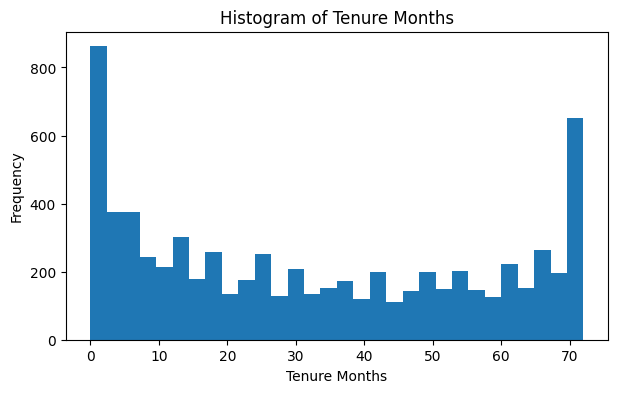

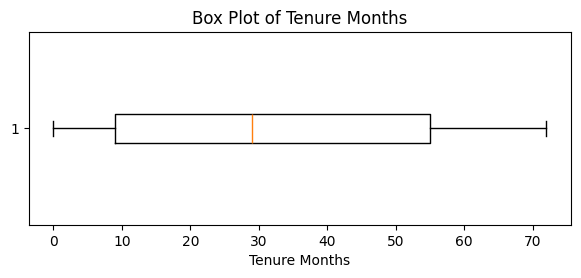


[Monthly Charges] 분포 확인


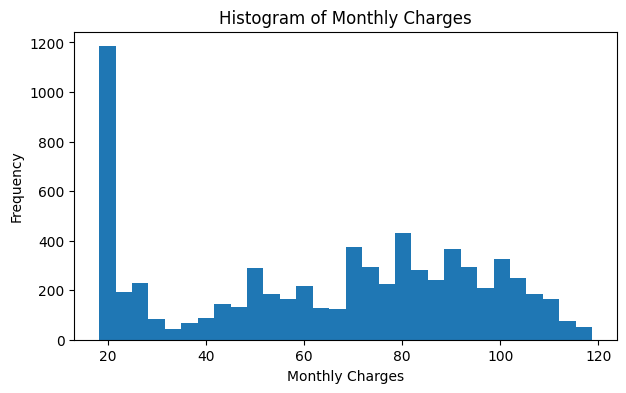

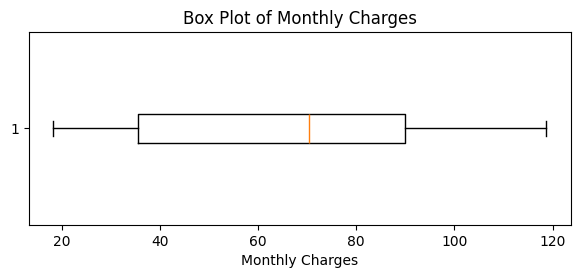


[Total Charges] 분포 확인


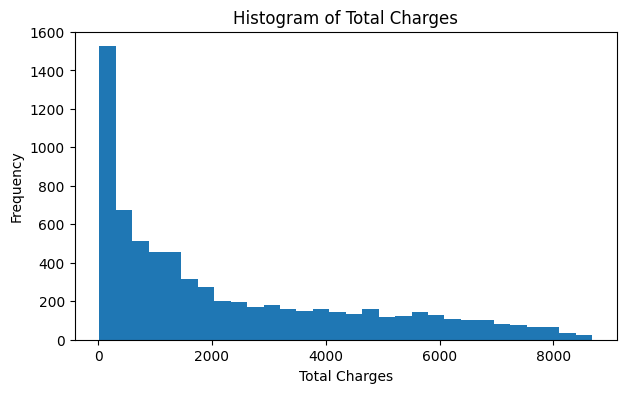

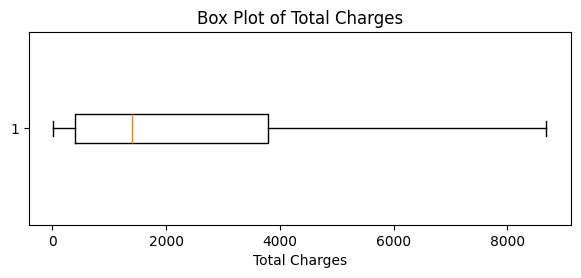


[CLTV] 분포 확인


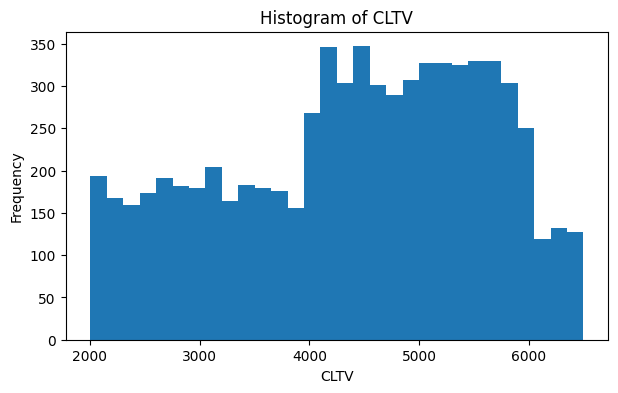

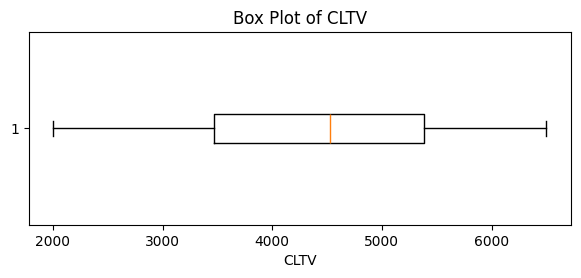


[Area_Total_Households] 분포 확인


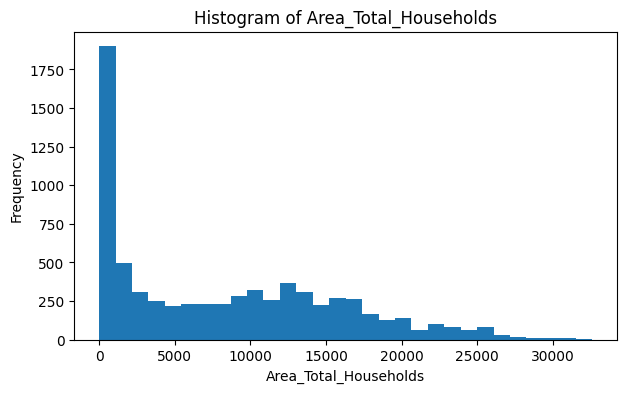

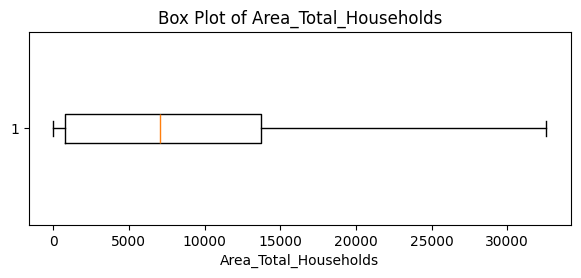


[Area_Median_Income] 분포 확인


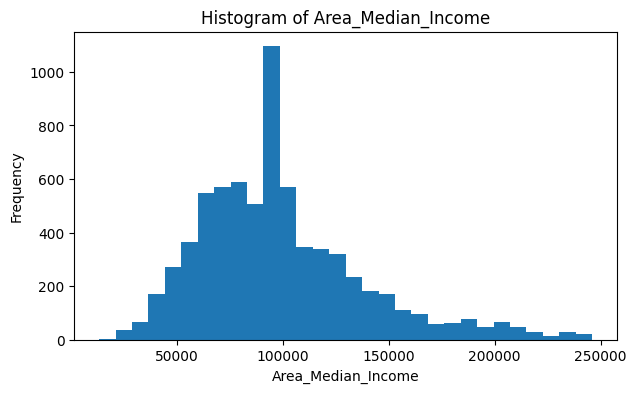

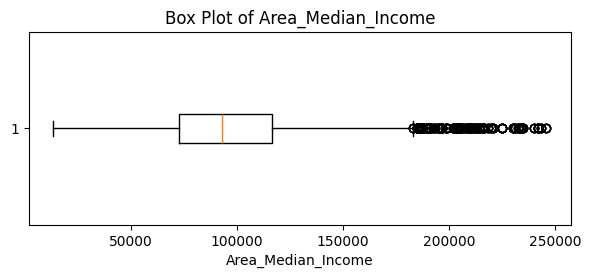


[Area_Mean_Income] 분포 확인


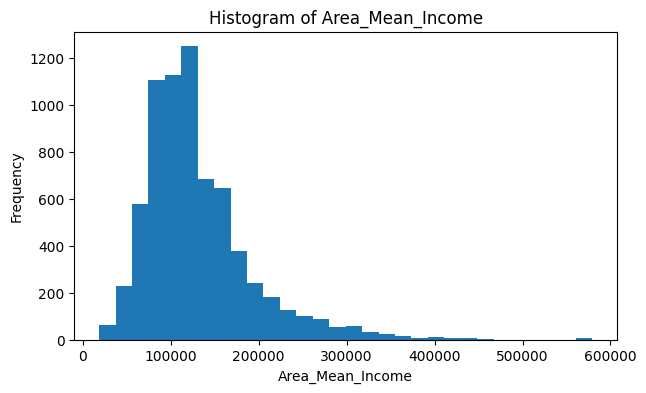

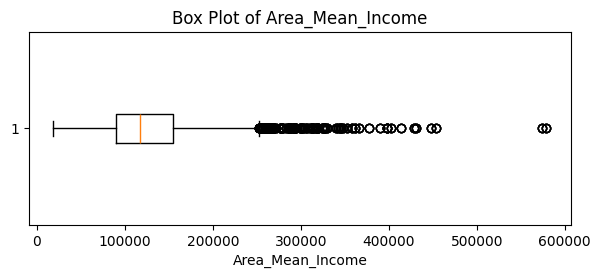


[Income_Charge_Ratio] 분포 확인


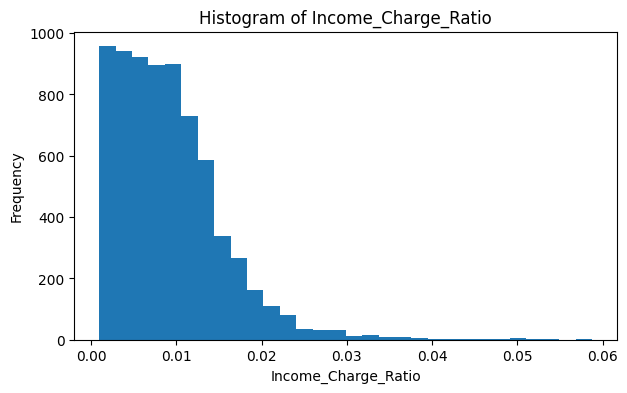

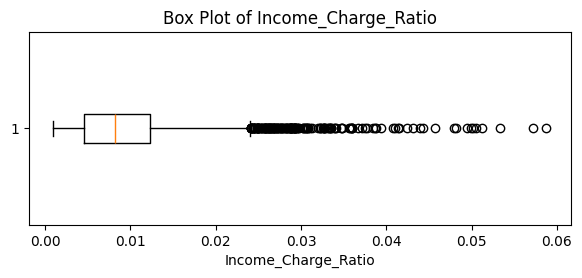

In [28]:
# =========================
# 1-6. 수치형 변수의 개별 분포 확인
# =========================

# 수치형 변수 목록 확인
print("수치형 변수 목록:")
print(numeric_features)

# 수치형 변수 요약 통계 재확인
numeric_distribution_summary = df_eda[numeric_features].describe().T

numeric_distribution_summary["missing_count"] = df_eda[numeric_features].isnull().sum()
numeric_distribution_summary["skewness"] = df_eda[numeric_features].skew()
numeric_distribution_summary["median"] = df_eda[numeric_features].median()

numeric_distribution_summary = numeric_distribution_summary[
    ["count", "missing_count", "mean", "median", "std", "min", "25%", "50%", "75%", "max", "skewness"]
].round(3)

print("\n수치형 변수 분포 요약:")
display(numeric_distribution_summary)

# 왜도 기준 정렬
skewness_sorted = numeric_distribution_summary[["mean", "median", "skewness"]].sort_values(
    "skewness",
    ascending=False
)

print("\n왜도 기준 정렬:")
display(skewness_sorted)

# 히스토그램과 박스플롯 출력
for col in numeric_features:
    print("\n" + "=" * 80)
    print(f"[{col}] 분포 확인")

    plt.figure(figsize=(7, 4))
    plt.hist(df_eda[col].dropna(), bins=30)
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

    plt.figure(figsize=(7, 2.5))
    plt.boxplot(df_eda[col].dropna(), vert=False)
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
    plt.show()

> 수치형 변수의 분포를 확인한 결과, `Tenure Months`는 0~72개월 범위에 분포하며 평균은 약 32.37개월로 나타났다. `Monthly Charges`의 평균은 약 64.76달러이고, `Total Charges`는 평균이 중앙값보다 높아 일부 장기 고객 또는 고요금 고객에 의해 오른쪽으로 치우친 분포를 보였다. 지역 소득 관련 변수와 `Income_Charge_Ratio` 역시 양의 왜도를 보여 고소득 지역 또는 요금 부담이 큰 일부 고객이 존재함을 확인하였다.
---

##1-7. 범주형 변수별 이탈률 비교

핵심 EDA입니다.
이번 단계에서는 범주형 변수 전체를 대상으로 각 category별 이탈률을 계산합니다.

아직 파생변수는 만들지 않고, 먼저 어떤 범주형 변수에서 이탈률 차이가 큰지 확인합니다.

범주형 변수별 이탈률 상세표:


,feature,category,customer_count,churn_count,churn_rate(%)
0,Gender,Female,3488,939,26.92
1,Gender,Male,3555,930,26.16
2,Senior Citizen,Yes,1142,476,41.68
3,Senior Citizen,No,5901,1393,23.61
4,Partner,No,3641,1200,32.96
5,Partner,Yes,3402,669,19.66
6,Dependents,No,5416,1763,32.55
7,Dependents,Yes,1627,106,6.52
8,Phone Service,Yes,6361,1699,26.71
9,Phone Service,No,682,170,24.93



범주형 변수별 이탈률 차이 요약:


,feature,max_churn_rate(%),min_churn_rate(%),gap(%p),high_risk_category,high_risk_customer_count,low_risk_category
13,Contract,42.71,2.83,39.88,Month-to-month,3875,Two year
6,Internet Service,41.89,7.40,34.49,Fiber optic,3096,No
7,Online Security,41.77,7.40,34.37,No,3498,No internet service
10,Tech Support,41.64,7.40,34.24,No,3473,No internet service
8,Online Backup,39.93,7.40,32.53,No,3088,No internet service
9,Device Protection,39.13,7.40,31.73,No,3095,No internet service
15,Payment Method,45.29,15.24,30.05,Electronic check,2365,Credit card (automatic)
12,Streaming Movies,33.68,7.40,26.28,No,2785,No internet service
11,Streaming TV,33.52,7.40,26.12,No,2810,No internet service
3,Dependents,32.55,6.52,26.03,No,5416,Yes



이탈률 차이가 큰 상위 범주형 변수:
['Contract', 'Internet Service', 'Online Security', 'Tech Support', 'Online Backup', 'Device Protection', 'Payment Method', 'Streaming Movies']


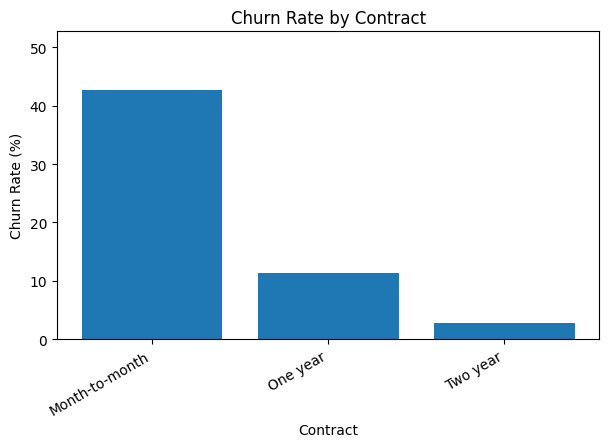

,Contract,customer_count,churn_count,churn_rate(%)
0,Month-to-month,3875,1655,42.71
1,One year,1473,166,11.27
2,Two year,1695,48,2.83


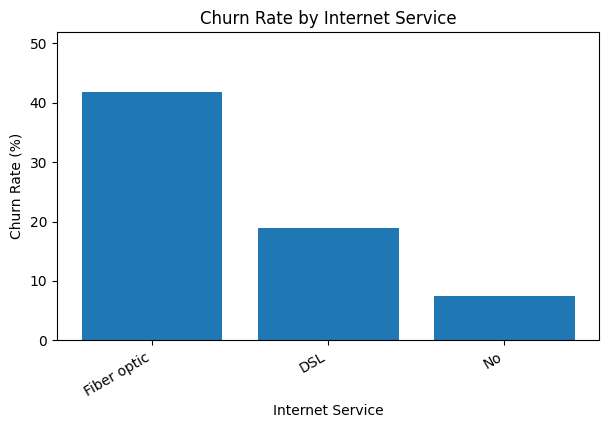

,Internet Service,customer_count,churn_count,churn_rate(%)
1,Fiber optic,3096,1297,41.89
0,DSL,2421,459,18.96
2,No,1526,113,7.40


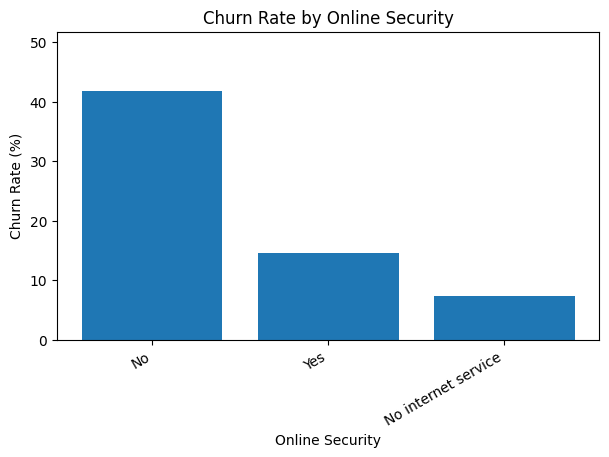

,Online Security,customer_count,churn_count,churn_rate(%)
0,No,3498,1461,41.77
2,Yes,2019,295,14.61
1,No internet service,1526,113,7.40


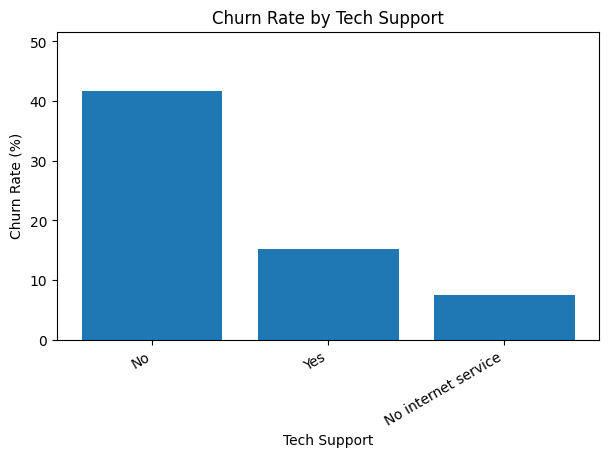

,Tech Support,customer_count,churn_count,churn_rate(%)
0,No,3473,1446,41.64
2,Yes,2044,310,15.17
1,No internet service,1526,113,7.40


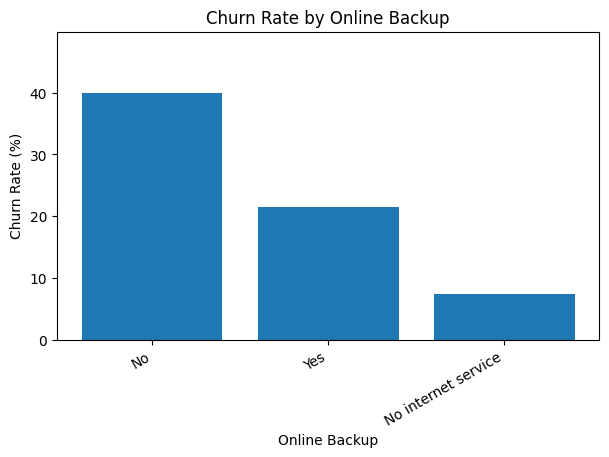

,Online Backup,customer_count,churn_count,churn_rate(%)
0,No,3088,1233,39.93
2,Yes,2429,523,21.53
1,No internet service,1526,113,7.40


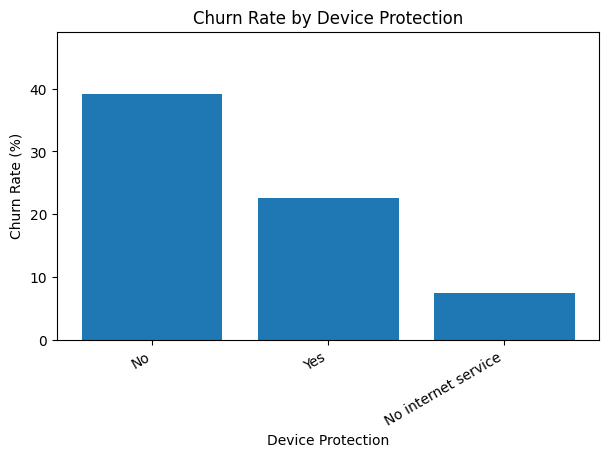

,Device Protection,customer_count,churn_count,churn_rate(%)
0,No,3095,1211,39.13
2,Yes,2422,545,22.50
1,No internet service,1526,113,7.40


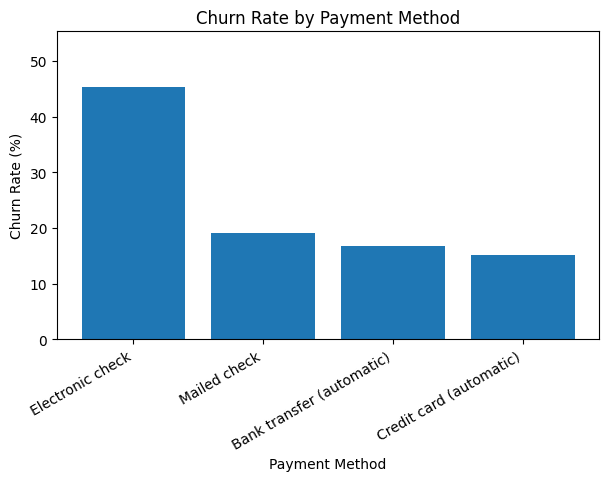

,Payment Method,customer_count,churn_count,churn_rate(%)
2,Electronic check,2365,1071,45.29
3,Mailed check,1612,308,19.11
0,Bank transfer (automatic),1544,258,16.71
1,Credit card (automatic),1522,232,15.24


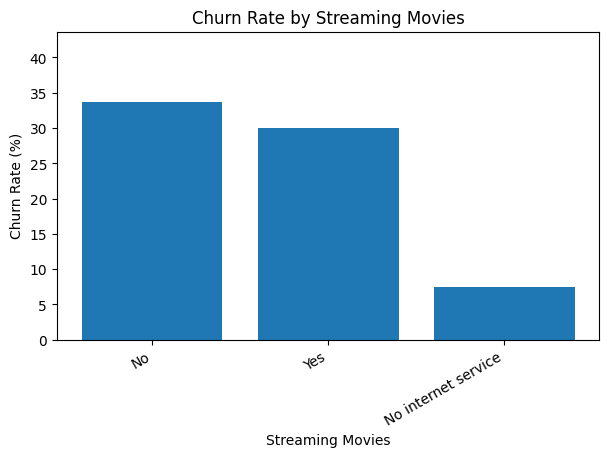

,Streaming Movies,customer_count,churn_count,churn_rate(%)
0,No,2785,938,33.68
2,Yes,2732,818,29.94
1,No internet service,1526,113,7.40


In [29]:
# =========================
# 1-7. 범주형 변수별 이탈률 비교
# =========================

target = "Churn Value"

# 범주형 변수별 이탈률 계산 함수
def categorical_churn_rate_table(data, col, target="Churn Value"):
    table = data.groupby(col, dropna=False).agg(
        customer_count=(target, "count"),
        churn_count=(target, "sum"),
        churn_rate=(target, "mean")
    ).reset_index()

    table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
    table = table.drop(columns="churn_rate")
    table = table.sort_values("churn_rate(%)", ascending=False)

    return table


# 전체 범주형 변수별 이탈률 상세표 생성
categorical_churn_detail_list = []

for col in categorical_features:
    temp = categorical_churn_rate_table(df_eda, col, target)
    temp["feature"] = col

    # 컬럼 순서 정리
    temp = temp.rename(columns={col: "category"})
    temp = temp[["feature", "category", "customer_count", "churn_count", "churn_rate(%)"]]

    categorical_churn_detail_list.append(temp)

categorical_churn_detail = pd.concat(
    categorical_churn_detail_list,
    axis=0
).reset_index(drop=True)

print("범주형 변수별 이탈률 상세표:")
display(categorical_churn_detail)


# 각 범주형 변수별 이탈률 차이 계산
categorical_churn_gap_list = []

for col in categorical_features:
    temp = categorical_churn_rate_table(df_eda, col, target)

    max_rate = temp["churn_rate(%)"].max()
    min_rate = temp["churn_rate(%)"].min()
    gap = max_rate - min_rate

    high_risk_category = temp.loc[temp["churn_rate(%)"].idxmax(), col]
    low_risk_category = temp.loc[temp["churn_rate(%)"].idxmin(), col]

    high_risk_count = temp.loc[temp["churn_rate(%)"].idxmax(), "customer_count"]

    categorical_churn_gap_list.append({
        "feature": col,
        "max_churn_rate(%)": max_rate,
        "min_churn_rate(%)": min_rate,
        "gap(%p)": round(gap, 2),
        "high_risk_category": high_risk_category,
        "high_risk_customer_count": high_risk_count,
        "low_risk_category": low_risk_category
    })

categorical_churn_gap_summary = pd.DataFrame(categorical_churn_gap_list)
categorical_churn_gap_summary = categorical_churn_gap_summary.sort_values(
    "gap(%p)",
    ascending=False
)

print("\n범주형 변수별 이탈률 차이 요약:")
display(categorical_churn_gap_summary)


# 이탈률 차이가 큰 상위 변수만 그래프로 확인
top_categorical_features = categorical_churn_gap_summary.head(8)["feature"].tolist()

print("\n이탈률 차이가 큰 상위 범주형 변수:")
print(top_categorical_features)

for col in top_categorical_features:
    temp = categorical_churn_rate_table(df_eda, col, target)

    plt.figure(figsize=(7, 4))
    plt.bar(temp[col].astype(str), temp["churn_rate(%)"])
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, max(temp["churn_rate(%)"]) + 10)
    plt.show()

    display(temp)

| 순위 | 변수                | 고위험 category     |    이탈률 |
| -: | ----------------- | ---------------- | -----: |
|  1 | Contract          | Month-to-month   | 42.71% |
|  2 | Internet Service  | Fiber optic      | 41.89% |
|  3 | Online Security   | No               | 41.77% |
|  4 | Tech Support      | No               | 41.64% |
|  5 | Online Backup     | No               | 39.93% |
|  6 | Device Protection | No               | 39.13% |
|  7 | Payment Method    | Electronic check | 45.29% |


> 범주형 변수별 이탈률을 비교한 결과, `Contract`, `Internet Service`, `Online Security`, `Tech Support`, `Online Backup`, `Device Protection`, `Payment Method`에서 이탈률 차이가 크게 나타났다. 특히 월 단위 계약 고객, Fiber optic 이용 고객, 보안/지원 서비스를 이용하지 않는 고객, Electronic check 결제 고객의 이탈률이 높았다. 또한 보안/지원 서비스 관련 변수들이 공통적으로 No일 때 높은 이탈률을 보여, 이후 파생변수 생성 후보로 활용할 수 있다.
---

##1-8. 수치형 변수 구간별 이탈률 비교

이번 단계는 수치형 변수 전체를 대상으로 구간을 나누고, 각 구간별 이탈률을 비교합니다.

예를 들어 Tenure Months가 낮은 구간에서 이탈률이 높은지, Monthly Charges나 Income_Charge_Ratio가 높은 구간에서 이탈률이 높은지 확인합니다.

수치형 변수 구간별 이탈률 상세표:


,feature,bin,customer_count,churn_count,churn_rate(%),avg_value
0,Tenure Months,"(-0.001, 9.0]",1854,923,49.78,3.608
1,Tenure Months,"(9.0, 29.0]",1715,486,28.34,18.718
2,Tenure Months,"(29.0, 55.0]",1719,324,18.85,42.581
3,Tenure Months,"(55.0, 72.0]",1755,136,7.75,66.098
4,Monthly Charges,"(18.249, 35.5]",1762,198,11.24,22.230
5,Monthly Charges,"(35.5, 70.35]",1766,434,24.58,55.729
6,Monthly Charges,"(70.35, 89.85]",1757,659,37.51,80.335
7,Monthly Charges,"(89.85, 118.75]",1758,578,32.88,100.899
8,Total Charges,"(18.799, 401.45]",1758,764,43.46,152.965
9,Total Charges,"(401.45, 1397.475]",1758,445,25.31,861.382



수치형 변수별 이탈률 차이 요약:


,feature,max_churn_rate(%),min_churn_rate(%),gap(%p),high_risk_bin,high_risk_customer_count,low_risk_bin
0,Tenure Months,49.78,7.75,42.03,"(-0.001, 9.0]",1854,"(55.0, 72.0]"
2,Total Charges,43.46,14.51,28.95,"(18.799, 401.45]",1758,"(3794.738, 8684.8]"
1,Monthly Charges,37.51,11.24,26.27,"(70.35, 89.85]",1757,"(18.249, 35.5]"
7,Income_Charge_Ratio,32.99,13.46,19.53,"(0.0123, 0.0588]",1761,"(-5.9000000000000025e-05, 0.00449]"
3,CLTV,34.43,20.73,13.70,"(2002.999, 3469.0]",1763,"(5380.5, 6500.0]"
5,Area_Median_Income,27.96,25.31,2.65,"(13332.999, 72445.0]",1763,"(72445.0, 92854.5]"
6,Area_Mean_Income,28.12,25.67,2.45,"(18549.999, 90036.0]",1764,"(90036.0, 117555.5]"
4,Area_Total_Households,27.13,26.24,0.89,"(7076.0, 13759.0]",1762,"(796.0, 7076.0]"



이탈률 차이가 큰 상위 수치형 변수:
['Tenure Months', 'Total Charges', 'Monthly Charges', 'Income_Charge_Ratio', 'CLTV', 'Area_Median_Income', 'Area_Mean_Income', 'Area_Total_Households']


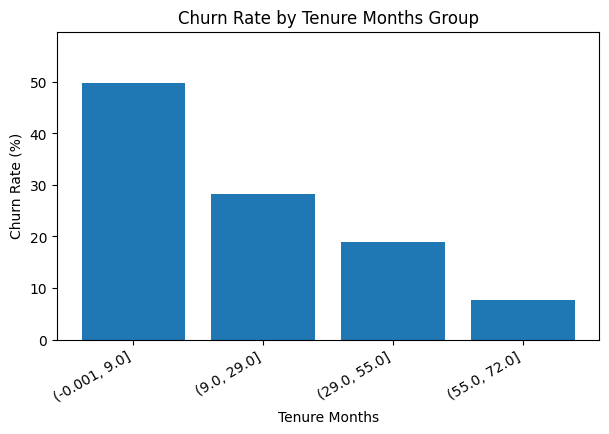

,Tenure Months_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(-0.001, 9.0]",1854,923,3.608,49.78
1,"(9.0, 29.0]",1715,486,18.718,28.34
2,"(29.0, 55.0]",1719,324,42.581,18.85
3,"(55.0, 72.0]",1755,136,66.098,7.75


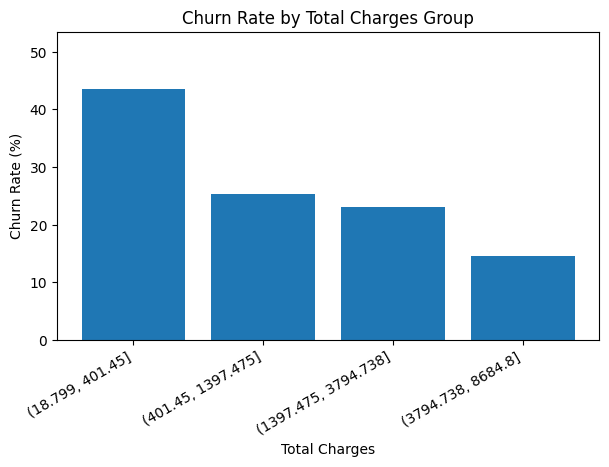

,Total Charges_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(18.799, 401.45]",1758,764,152.965,43.46
1,"(401.45, 1397.475]",1758,445,861.382,25.31
2,"(1397.475, 3794.738]",1758,405,2399.576,23.04
3,"(3794.738, 8684.8]",1758,255,5719.278,14.51


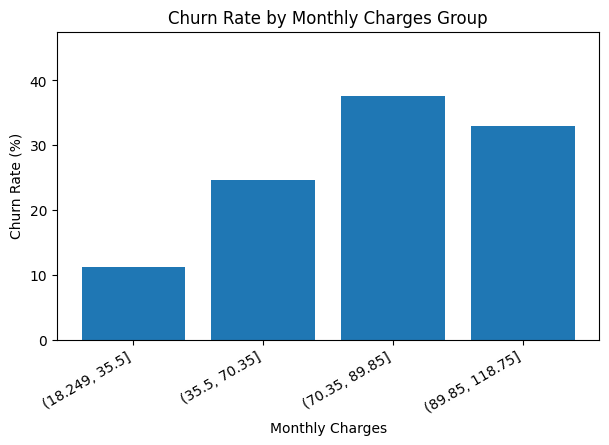

,Monthly Charges_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(18.249, 35.5]",1762,198,22.230,11.24
1,"(35.5, 70.35]",1766,434,55.729,24.58
2,"(70.35, 89.85]",1757,659,80.335,37.51
3,"(89.85, 118.75]",1758,578,100.899,32.88


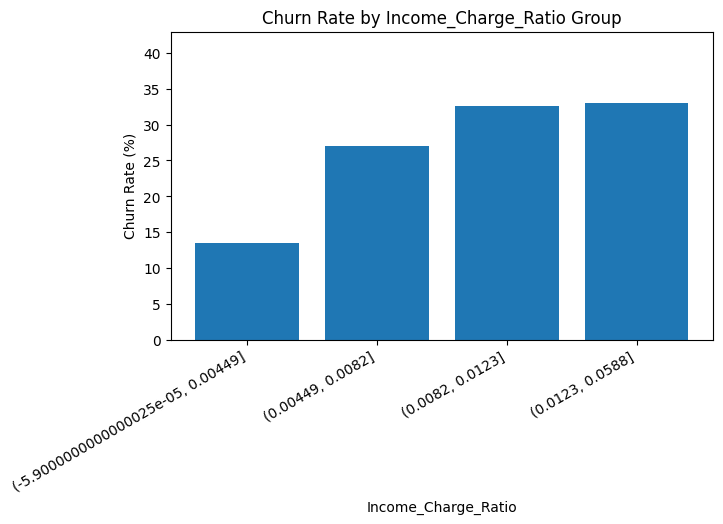

,Income_Charge_Ratio_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(-5.9000000000000025e-05, 0.00449]",1761,237,0.003,13.46
1,"(0.00449, 0.0082]",1761,476,0.006,27.03
2,"(0.0082, 0.0123]",1760,575,0.010,32.67
3,"(0.0123, 0.0588]",1761,581,0.017,32.99


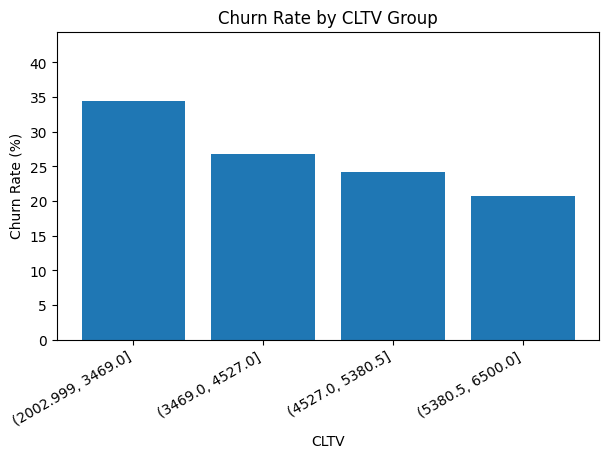

,CLTV_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(2002.999, 3469.0]",1763,607,2743.633,34.43
1,"(3469.0, 4527.0]",1759,472,4079.810,26.83
2,"(4527.0, 5380.5]",1760,425,4959.761,24.15
3,"(5380.5, 6500.0]",1761,365,5819.814,20.73


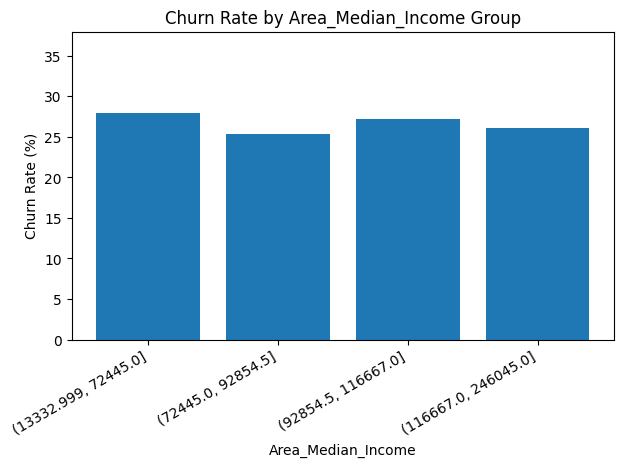

,Area_Median_Income_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(13332.999, 72445.0]",1763,493,56748.029,27.96
1,"(72445.0, 92854.5]",2086,528,85183.492,25.31
2,"(92854.5, 116667.0]",1435,390,104184.081,27.18
3,"(116667.0, 246045.0]",1759,458,152726.406,26.04


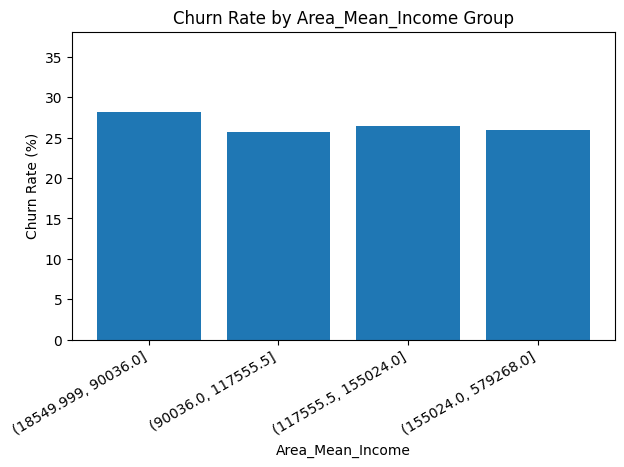

,Area_Mean_Income_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(18549.999, 90036.0]",1764,496,71396.401,28.12
1,"(90036.0, 117555.5]",1889,485,105197.524,25.67
2,"(117555.5, 155024.0]",1630,431,134645.293,26.44
3,"(155024.0, 579268.0]",1760,457,214163.518,25.97


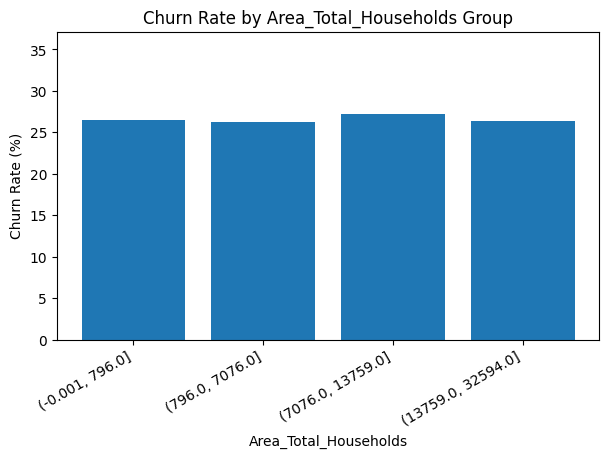

,Area_Total_Households_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(-0.001, 796.0]",1763,467,272.866,26.49
1,"(796.0, 7076.0]",1761,462,3357.761,26.24
2,"(7076.0, 13759.0]",1762,478,10636.454,27.13
3,"(13759.0, 32594.0]",1757,462,18666.652,26.29


In [30]:
# =========================
# 1-8. 수치형 변수 구간별 이탈률 비교
# =========================

target = "Churn Value"

# 수치형 변수 구간별 이탈률 계산 함수
def numeric_churn_rate_table(data, col, target="Churn Value", q=4):
    temp = data[[col, target]].dropna().copy()

    # 고유값이 너무 적으면 구간화 제외
    if temp[col].nunique() <= 2:
        return None

    try:
        temp[col + "_bin"] = pd.qcut(
            temp[col],
            q=q,
            duplicates="drop"
        )
    except:
        return None

    table = temp.groupby(col + "_bin", observed=False).agg(
        customer_count=(target, "count"),
        churn_count=(target, "sum"),
        churn_rate=(target, "mean"),
        avg_value=(col, "mean")
    ).reset_index()

    table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
    table["avg_value"] = table["avg_value"].round(3)
    table = table.drop(columns="churn_rate")

    return table


# 전체 수치형 변수별 구간 이탈률 상세표 생성
numeric_churn_detail_list = []

for col in numeric_features:
    temp = numeric_churn_rate_table(df_eda, col, target, q=4)

    if temp is not None:
        temp["feature"] = col
        temp = temp.rename(columns={col + "_bin": "bin"})
        temp = temp[["feature", "bin", "customer_count", "churn_count", "churn_rate(%)", "avg_value"]]
        numeric_churn_detail_list.append(temp)

numeric_churn_detail = pd.concat(
    numeric_churn_detail_list,
    axis=0
).reset_index(drop=True)

print("수치형 변수 구간별 이탈률 상세표:")
display(numeric_churn_detail)


# 각 수치형 변수별 이탈률 차이 계산
numeric_churn_gap_list = []

for col in numeric_features:
    temp = numeric_churn_rate_table(df_eda, col, target, q=4)

    if temp is None:
        continue

    max_rate = temp["churn_rate(%)"].max()
    min_rate = temp["churn_rate(%)"].min()
    gap = max_rate - min_rate

    high_risk_bin = temp.loc[temp["churn_rate(%)"].idxmax(), col + "_bin"]
    low_risk_bin = temp.loc[temp["churn_rate(%)"].idxmin(), col + "_bin"]
    high_risk_count = temp.loc[temp["churn_rate(%)"].idxmax(), "customer_count"]

    numeric_churn_gap_list.append({
        "feature": col,
        "max_churn_rate(%)": max_rate,
        "min_churn_rate(%)": min_rate,
        "gap(%p)": round(gap, 2),
        "high_risk_bin": high_risk_bin,
        "high_risk_customer_count": high_risk_count,
        "low_risk_bin": low_risk_bin
    })

numeric_churn_gap_summary = pd.DataFrame(numeric_churn_gap_list)
numeric_churn_gap_summary = numeric_churn_gap_summary.sort_values(
    "gap(%p)",
    ascending=False
)

print("\n수치형 변수별 이탈률 차이 요약:")
display(numeric_churn_gap_summary)


# 이탈률 차이가 큰 상위 수치형 변수 그래프
top_numeric_features = numeric_churn_gap_summary.head(8)["feature"].tolist()

print("\n이탈률 차이가 큰 상위 수치형 변수:")
print(top_numeric_features)

for col in top_numeric_features:
    temp = numeric_churn_rate_table(df_eda, col, target, q=4)

    plt.figure(figsize=(7, 4))
    plt.bar(temp[col + "_bin"].astype(str), temp["churn_rate(%)"])
    plt.title(f"Churn Rate by {col} Group")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, max(temp["churn_rate(%)"]) + 10)
    plt.show()

    display(temp)

>수치형 변수에서는 Tenure Months가 가장 강한 이탈률 차이를 보였고, 그다음으로 Total Charges, Monthly Charges, Income_Charge_Ratio가 눈에 띕니다.

>특히 해석할 때 주의할 점은 Total Charges입니다.
Total Charges가 낮은 고객의 이탈률이 높은 이유는 “돈을 적게 낸 고객이라서 이탈한다”라기보다, 가입 기간이 짧아서 아직 누적 요금이 낮은 신규 고객일 가능성이 큽니다. 그래서 이후에는 Total Charges를 단독 위험 요인으로 보기보다 Tenure Months와 함께 해석하는 게 좋습니다.

> 수치형 변수 구간별 이탈률을 비교한 결과, `Tenure Months`에서 가장 큰 차이가 나타났다. 가입 기간 9개월 이하 고객의 이탈률은 49.78%인 반면, 55개월 초과 고객의 이탈률은 7.75%로 낮았다. 또한 `Monthly Charges`와 `Income_Charge_Ratio`가 높을수록 이탈률이 증가하는 경향을 보여, 짧은 가입 기간과 요금 부담이 주요 이탈 위험 요인 후보로 확인되었다.
---

##1-9. 전체 변수 이탈률 차이 통합 요약

이번 단계에서는 1-7의 범주형 변수 결과와 1-8의 수치형 변수 결과를 합쳐서, 전체 변수 중 이탈률 차이가 큰 순서대로 정리합니다.

이 표를 보면 EDA 기반으로 어떤 변수를 주요 이탈 위험 요인 후보로 볼 수 있는지 한눈에 볼 수 있습니다.

In [31]:
# =========================
# 1-9. 전체 변수 이탈률 차이 통합 요약
# =========================

# 의미 기반 그룹 매핑 함수
def get_feature_group(feature):
    for group_name, cols in column_groups.items():
        if feature in cols:
            return group_name
    return "기타"


# =========================
# 범주형 변수 요약 정리
# =========================

cat_summary = categorical_churn_gap_summary.copy()

cat_summary["feature_type"] = "categorical"
cat_summary["group"] = cat_summary["feature"].apply(get_feature_group)

cat_summary = cat_summary.rename(columns={
    "high_risk_category": "high_risk_segment",
    "low_risk_category": "low_risk_segment"
})

cat_summary = cat_summary[[
    "feature",
    "group",
    "feature_type",
    "max_churn_rate(%)",
    "min_churn_rate(%)",
    "gap(%p)",
    "high_risk_segment",
    "high_risk_customer_count",
    "low_risk_segment"
]]


# =========================
# 수치형 변수 요약 정리
# =========================

num_summary = numeric_churn_gap_summary.copy()

num_summary["feature_type"] = "numeric"
num_summary["group"] = num_summary["feature"].apply(get_feature_group)

num_summary = num_summary.rename(columns={
    "high_risk_bin": "high_risk_segment",
    "low_risk_bin": "low_risk_segment"
})

num_summary = num_summary[[
    "feature",
    "group",
    "feature_type",
    "max_churn_rate(%)",
    "min_churn_rate(%)",
    "gap(%p)",
    "high_risk_segment",
    "high_risk_customer_count",
    "low_risk_segment"
]]


# =========================
# 전체 변수 통합
# =========================

eda_risk_factor_summary = pd.concat(
    [cat_summary, num_summary],
    axis=0
).sort_values("gap(%p)", ascending=False).reset_index(drop=True)

print("전체 변수 이탈률 차이 통합 요약:")
display(eda_risk_factor_summary)


# =========================
# 주요 위험 요인 후보만 추출
# 기준: 이탈률 차이 20%p 이상
# =========================

major_risk_candidates = eda_risk_factor_summary[
    eda_risk_factor_summary["gap(%p)"] >= 20
].reset_index(drop=True)

print("\n이탈률 차이 20%p 이상 주요 후보:")
display(major_risk_candidates)


# =========================
# 그룹별 평균 gap 확인
# 같은 의미 그룹에서 위험 신호가 반복되는지 확인
# =========================

group_gap_summary = eda_risk_factor_summary.groupby("group").agg(
    feature_count=("feature", "count"),
    avg_gap=("gap(%p)", "mean"),
    max_gap=("gap(%p)", "max")
).reset_index()

group_gap_summary["avg_gap"] = group_gap_summary["avg_gap"].round(2)
group_gap_summary = group_gap_summary.sort_values("avg_gap", ascending=False)

print("\n의미 그룹별 이탈률 차이 요약:")
display(group_gap_summary)

전체 변수 이탈률 차이 통합 요약:


,feature,group,feature_type,max_churn_rate(%),min_churn_rate(%),gap(%p),high_risk_segment,high_risk_customer_count,low_risk_segment
0,Tenure Months,기간/요금/고객가치 정보,numeric,49.78,7.75,42.03,"(-0.001, 9.0]",1854,"(55.0, 72.0]"
1,Contract,계약/결제 정보,categorical,42.71,2.83,39.88,Month-to-month,3875,Two year
2,Internet Service,기본 서비스 정보,categorical,41.89,7.40,34.49,Fiber optic,3096,No
3,Online Security,보안/지원 서비스 정보,categorical,41.77,7.40,34.37,No,3498,No internet service
4,Tech Support,보안/지원 서비스 정보,categorical,41.64,7.40,34.24,No,3473,No internet service
5,Online Backup,보안/지원 서비스 정보,categorical,39.93,7.40,32.53,No,3088,No internet service
6,Device Protection,보안/지원 서비스 정보,categorical,39.13,7.40,31.73,No,3095,No internet service
7,Payment Method,계약/결제 정보,categorical,45.29,15.24,30.05,Electronic check,2365,Credit card (automatic)
8,Total Charges,기간/요금/고객가치 정보,numeric,43.46,14.51,28.95,"(18.799, 401.45]",1758,"(3794.738, 8684.8]"
9,Streaming Movies,콘텐츠 부가서비스 정보,categorical,33.68,7.40,26.28,No,2785,No internet service



이탈률 차이 20%p 이상 주요 후보:


,feature,group,feature_type,max_churn_rate(%),min_churn_rate(%),gap(%p),high_risk_segment,high_risk_customer_count,low_risk_segment
0,Tenure Months,기간/요금/고객가치 정보,numeric,49.78,7.75,42.03,"(-0.001, 9.0]",1854,"(55.0, 72.0]"
1,Contract,계약/결제 정보,categorical,42.71,2.83,39.88,Month-to-month,3875,Two year
2,Internet Service,기본 서비스 정보,categorical,41.89,7.40,34.49,Fiber optic,3096,No
3,Online Security,보안/지원 서비스 정보,categorical,41.77,7.40,34.37,No,3498,No internet service
4,Tech Support,보안/지원 서비스 정보,categorical,41.64,7.40,34.24,No,3473,No internet service
5,Online Backup,보안/지원 서비스 정보,categorical,39.93,7.40,32.53,No,3088,No internet service
6,Device Protection,보안/지원 서비스 정보,categorical,39.13,7.40,31.73,No,3095,No internet service
7,Payment Method,계약/결제 정보,categorical,45.29,15.24,30.05,Electronic check,2365,Credit card (automatic)
8,Total Charges,기간/요금/고객가치 정보,numeric,43.46,14.51,28.95,"(18.799, 401.45]",1758,"(3794.738, 8684.8]"
9,Streaming Movies,콘텐츠 부가서비스 정보,categorical,33.68,7.40,26.28,No,2785,No internet service



의미 그룹별 이탈률 차이 요약:


,group,feature_count,avg_gap,max_gap
4,보안/지원 서비스 정보,4,33.22,34.37
0,계약/결제 정보,3,29.06,39.88
2,기간/요금/고객가치 정보,4,27.74,42.03
6,콘텐츠 부가서비스 정보,2,26.20,26.28
1,고객 인구통계 정보,4,14.54,26.03
3,기본 서비스 정보,3,13.32,34.49
5,지역 소득 정보,5,5.98,19.53


> 전체 변수의 이탈률 차이를 통합 비교한 결과, `Tenure Months`, `Contract`, `Internet Service`, 보안/지원 서비스 변수, `Payment Method`, `Monthly Charges`가 주요 이탈 위험 요인 후보로 나타났다. 특히 보안/지원 서비스, 계약/결제, 기간/요금 관련 변수 그룹에서 이탈률 차이가 반복적으로 크게 나타나, 이후 그룹 단위 해석과 파생변수 생성이 필요하다.
---

##1-10. 의미 그룹별 위험 패턴 확인

이번 단계에서는 단순히 “상위 변수”를 보는 게 아니라,
비슷한 의미의 변수들이 같은 방향의 이탈률 구조를 보이는지 확인합니다.

특히 중요한 점은 Online Security, Tech Support 같은 변수에서 No internet service가 낮은 이탈률로 잡히기 때문에,
보안/지원 서비스 해석은 인터넷 이용 고객 내부에서 No와 Yes를 비교하는 것이 더 정확합니다.

In [32]:
# =========================
# 1-10. 의미 그룹별 위험 패턴 확인
# =========================

target = "Churn Value"

# ---------------------------------------
# 1. 주요 그룹별 변수 목록 정의
# ---------------------------------------

support_service_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support"
]

contract_payment_cols = [
    "Contract",
    "Paperless Billing",
    "Payment Method"
]

content_service_cols = [
    "Streaming TV",
    "Streaming Movies"
]

numeric_key_cols = [
    "Tenure Months",
    "Total Charges",
    "Monthly Charges",
    "Income_Charge_Ratio",
    "CLTV"
]


# ---------------------------------------
# 2. 보안/지원 서비스 패턴 확인
# 인터넷 이용 고객 내부에서 Yes / No 비교
# ---------------------------------------

internet_users = df_eda[df_eda["Internet Service"] != "No"].copy()

support_pattern_list = []

for col in support_service_cols:
    temp = internet_users.groupby(col).agg(
        customer_count=(target, "count"),
        churn_count=(target, "sum"),
        churn_rate=(target, "mean")
    ).reset_index()

    temp["churn_rate(%)"] = (temp["churn_rate"] * 100).round(2)
    temp = temp.drop(columns="churn_rate")
    temp["feature"] = col
    temp = temp.rename(columns={col: "category"})
    temp = temp[["feature", "category", "customer_count", "churn_count", "churn_rate(%)"]]

    support_pattern_list.append(temp)

support_pattern_table = pd.concat(support_pattern_list, axis=0).reset_index(drop=True)

print("보안/지원 서비스 변수 패턴")
print("인터넷 이용 고객 내부에서 Yes / No 비교")
display(support_pattern_table)


# ---------------------------------------
# 3. 보안/지원 서비스 No vs Yes 이탈률 차이 요약
# ---------------------------------------

support_gap_list = []

for col in support_service_cols:
    temp = support_pattern_table[support_pattern_table["feature"] == col]

    no_rate = temp.loc[temp["category"] == "No", "churn_rate(%)"].values[0]
    yes_rate = temp.loc[temp["category"] == "Yes", "churn_rate(%)"].values[0]
    no_count = temp.loc[temp["category"] == "No", "customer_count"].values[0]
    yes_count = temp.loc[temp["category"] == "Yes", "customer_count"].values[0]

    support_gap_list.append({
        "feature": col,
        "No_churn_rate(%)": no_rate,
        "Yes_churn_rate(%)": yes_rate,
        "gap_No_minus_Yes(%p)": round(no_rate - yes_rate, 2),
        "No_customer_count": no_count,
        "Yes_customer_count": yes_count
    })

support_gap_summary = pd.DataFrame(support_gap_list).sort_values(
    "gap_No_minus_Yes(%p)",
    ascending=False
)

print("\n보안/지원 서비스 No vs Yes 이탈률 차이")
display(support_gap_summary)


# ---------------------------------------
# 4. 계약/결제 정보 패턴 확인
# ---------------------------------------

contract_payment_pattern_list = []

for col in contract_payment_cols:
    temp = categorical_churn_rate_table(df_eda, col, target)
    temp["feature"] = col
    temp = temp.rename(columns={col: "category"})
    temp = temp[["feature", "category", "customer_count", "churn_count", "churn_rate(%)"]]

    contract_payment_pattern_list.append(temp)

contract_payment_pattern_table = pd.concat(
    contract_payment_pattern_list,
    axis=0
).reset_index(drop=True)

print("\n계약/결제 정보 변수 패턴")
display(contract_payment_pattern_table)


# ---------------------------------------
# 5. 콘텐츠 부가서비스 패턴 확인
# 인터넷 이용 고객 내부에서 Yes / No 비교
# ---------------------------------------

content_pattern_list = []

for col in content_service_cols:
    temp = internet_users.groupby(col).agg(
        customer_count=(target, "count"),
        churn_count=(target, "sum"),
        churn_rate=(target, "mean")
    ).reset_index()

    temp["churn_rate(%)"] = (temp["churn_rate"] * 100).round(2)
    temp = temp.drop(columns="churn_rate")
    temp["feature"] = col
    temp = temp.rename(columns={col: "category"})
    temp = temp[["feature", "category", "customer_count", "churn_count", "churn_rate(%)"]]

    content_pattern_list.append(temp)

content_pattern_table = pd.concat(content_pattern_list, axis=0).reset_index(drop=True)

print("\n콘텐츠 부가서비스 변수 패턴")
print("인터넷 이용 고객 내부에서 Yes / No 비교")
display(content_pattern_table)


# ---------------------------------------
# 6. 수치형 핵심 변수 방향성 확인
# ---------------------------------------

numeric_pattern_list = []

for col in numeric_key_cols:
    temp = numeric_churn_rate_table(df_eda, col, target, q=4)
    temp = temp.rename(columns={col + "_bin": "bin"})
    temp["feature"] = col
    temp = temp[["feature", "bin", "customer_count", "churn_count", "avg_value", "churn_rate(%)"]]
    numeric_pattern_list.append(temp)

numeric_pattern_table = pd.concat(numeric_pattern_list, axis=0).reset_index(drop=True)

print("\n수치형 핵심 변수 구간별 패턴")
display(numeric_pattern_table)


# ---------------------------------------
# 7. 파생변수 생성 후보 요약
# ---------------------------------------

derived_feature_candidate_summary = pd.DataFrame({
    "candidate_derived_feature": [
        "Support_Service_Count",
        "No_Support_Service",
        "Contract_Payment_Risk_Score",
        "Tenure_Group",
        "Charge_Burden_Group",
        "Low_Tenure_High_Charge"
    ],
    "source_features": [
        "Online Security, Online Backup, Device Protection, Tech Support",
        "Online Security, Online Backup, Device Protection, Tech Support",
        "Contract, Payment Method, Paperless Billing",
        "Tenure Months",
        "Monthly Charges, Income_Charge_Ratio",
        "Tenure Months, Monthly Charges"
    ],
    "reason": [
        "보안/지원 서비스 미이용 시 이탈률이 반복적으로 높게 나타나는지 확인",
        "보안/지원 서비스를 하나도 사용하지 않는 고객군을 별도 위험군으로 정의 가능",
        "월 단위 계약, Electronic check, Paperless Billing이 동시에 위험 신호인지 확인",
        "가입 기간이 짧을수록 이탈률이 높아 고객 생애주기 구간화 필요",
        "월 요금 또는 소득 대비 요금 부담이 높을수록 이탈률이 높아 요금 부담 구간화 필요",
        "짧은 가입 기간과 높은 요금이 결합된 고객군의 위험도 확인 필요"
    ]
})

print("\n파생변수 생성 후보 요약")
display(derived_feature_candidate_summary)

보안/지원 서비스 변수 패턴
인터넷 이용 고객 내부에서 Yes / No 비교


,feature,category,customer_count,churn_count,churn_rate(%)
0,Online Security,No,3498,1461,41.77
1,Online Security,Yes,2019,295,14.61
2,Online Backup,No,3088,1233,39.93
3,Online Backup,Yes,2429,523,21.53
4,Device Protection,No,3095,1211,39.13
5,Device Protection,Yes,2422,545,22.50
6,Tech Support,No,3473,1446,41.64
7,Tech Support,Yes,2044,310,15.17



보안/지원 서비스 No vs Yes 이탈률 차이


,feature,No_churn_rate(%),Yes_churn_rate(%),gap_No_minus_Yes(%p),No_customer_count,Yes_customer_count
0,Online Security,41.77,14.61,27.16,3498,2019
3,Tech Support,41.64,15.17,26.47,3473,2044
1,Online Backup,39.93,21.53,18.40,3088,2429
2,Device Protection,39.13,22.50,16.63,3095,2422



계약/결제 정보 변수 패턴


...

,feature,category,customer_count,churn_count,churn_rate(%)
0,Streaming TV,No,2810,942,33.52
1,Streaming TV,Yes,2707,814,30.07
2,Streaming Movies,No,2785,938,33.68
3,Streaming Movies,Yes,2732,818,29.94



수치형 핵심 변수 구간별 패턴


,feature,bin,customer_count,churn_count,avg_value,churn_rate(%)
0,Tenure Months,"(-0.001, 9.0]",1854,923,3.608,49.78
1,Tenure Months,"(9.0, 29.0]",1715,486,18.718,28.34
2,Tenure Months,"(29.0, 55.0]",1719,324,42.581,18.85
3,Tenure Months,"(55.0, 72.0]",1755,136,66.098,7.75
4,Total Charges,"(18.799, 401.45]",1758,764,152.965,43.46
5,Total Charges,"(401.45, 1397.475]",1758,445,861.382,25.31
6,Total Charges,"(1397.475, 3794.738]",1758,405,2399.576,23.04
7,Total Charges,"(3794.738, 8684.8]",1758,255,5719.278,14.51
8,Monthly Charges,"(18.249, 35.5]",1762,198,22.230,11.24
9,Monthly Charges,"(35.5, 70.35]",1766,434,55.729,24.58



파생변수 생성 후보 요약


,candidate_derived_feature,source_features,reason
0,Support_Service_Count,"Online Security, Online Backup, Device Protect...",보안/지원 서비스 미이용 시 이탈률이 반복적으로 높게 나타나는지 확인
1,No_Support_Service,"Online Security, Online Backup, Device Protect...",보안/지원 서비스를 하나도 사용하지 않는 고객군을 별도 위험군으로 정의 가능
2,Contract_Payment_Risk_Score,"Contract, Payment Method, Paperless Billing","월 단위 계약, Electronic check, Paperless Billing이 ..."
3,Tenure_Group,Tenure Months,가입 기간이 짧을수록 이탈률이 높아 고객 생애주기 구간화 필요
4,Charge_Burden_Group,"Monthly Charges, Income_Charge_Ratio",월 요금 또는 소득 대비 요금 부담이 높을수록 이탈률이 높아 요금 부담 구간화 필요
5,Low_Tenure_High_Charge,"Tenure Months, Monthly Charges",짧은 가입 기간과 높은 요금이 결합된 고객군의 위험도 확인 필요


>핵심은 다음입니다.

>Online Security, Tech Support, Online Backup, Device Protection은 모두 No일 때 이탈률이 높음
특히 Online Security, Tech Support는 No와 Yes의 이탈률 차이가 각각 27.16%p, 26.47%p로 큼
Contract, Payment Method, Paperless Billing에서는 Month-to-month, Electronic check, Paperless Billing Yes가 위험 신호
Streaming TV, Streaming Movies는 No일 때 이탈률이 조금 높지만, 보안/지원 서비스보다 차이가 작음
수치형 변수에서는 짧은 가입 기간, 낮은 누적 요금, 높은 월 요금, 높은 소득 대비 요금 부담이 위험 패턴으로 나타남


> 의미가 비슷한 변수들을 묶어 확인한 결과, 보안/지원 서비스 변수들은 공통적으로 No일 때 이탈률이 높게 나타났다. 또한 계약/결제 변수에서는 월 단위 계약, Electronic check 결제, Paperless Billing 사용 고객의 이탈률이 높았다. 수치형 변수에서는 짧은 가입 기간과 높은 요금 부담이 반복적으로 위험 패턴을 보여, 이후 파생변수 생성 기준으로 활용한다.
---

##1-11. EDA 기반 파생변수 생성 및 이탈률 확인

이번 단계에서는 앞에서 발견한 패턴을 바탕으로 파생변수를 만듭니다.

중요한 점은 No internet service 고객을 단순히 “보안/지원 서비스 미사용자”로 보면 안 된다는 것입니다.
그래서 보안/지원 서비스 파생변수는 인터넷 이용 고객과 비이용 고객을 구분해서 만듭니다.

생성된 파생변수:
['Is_Internet_User', 'Support_Service_Count', 'Support_Service_Level', 'Internet_User_No_Support', 'Contract_Payment_Risk_Score', 'Contract_Payment_Risk_Level', 'Tenure_Group', 'Monthly_Charge_Group', 'Income_Charge_Burden_Group', 'Low_Tenure_High_Charge']


,Is_Internet_User,Support_Service_Count,Support_Service_Level,Internet_User_No_Support,Contract_Payment_Risk_Score,Contract_Payment_Risk_Level,Tenure_Group,Monthly_Charge_Group,Income_Charge_Burden_Group,Low_Tenure_High_Charge,Churn Value
0,1,2,2_services,0,2,2_high,0-9 months,mid,mid_high,0,1
1,1,0,0_services,1,3,3_very_high,0-9 months,high,high,1,1
2,1,1,1_services,0,3,3_very_high,0-9 months,very_high,high,1,1
3,1,2,2_services,0,3,3_very_high,10-29 months,very_high,high,0,1
4,1,2,2_services,0,2,2_high,30-55 months,very_high,high,0,1



파생변수별 이탈률 상세표:


/tmp/ipykernel_5190/408519947.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(col, dropna=False).agg(
/tmp/ipykernel_5190/408519947.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(col, dropna=False).agg(
/tmp/ipykernel_5190/408519947.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(col, dropna=False).agg(


,feature,segment,customer_count,churn_count,churn_rate(%)
0,Is_Internet_User,1,5517,1756,31.83
1,Is_Internet_User,0,1526,113,7.40
2,Support_Service_Count,1,1467,570,38.85
3,Support_Service_Count,0,2793,831,29.75
4,Support_Service_Count,2,1372,326,23.76
5,Support_Service_Count,3,941,117,12.43
6,Support_Service_Count,4,470,25,5.32
7,Support_Service_Level,0_services,1267,718,56.67
8,Support_Service_Level,1_services,1467,570,38.85
9,Support_Service_Level,2_services,1372,326,23.76



파생변수별 이탈률 차이 요약:


/tmp/ipykernel_5190/408519947.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(col, dropna=False).agg(
/tmp/ipykernel_5190/408519947.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(col, dropna=False).agg(
/tmp/ipykernel_5190/408519947.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(col, dropna=False).agg(


,derived_feature,max_churn_rate(%),min_churn_rate(%),gap(%p),high_risk_segment,high_risk_customer_count,low_risk_segment
0,Contract_Payment_Risk_Score,57.70,3.33,54.37,3,1397,0
1,Contract_Payment_Risk_Level,57.70,3.33,54.37,3_very_high,1397,0_low
2,Support_Service_Level,56.67,5.32,51.35,0_services,1267,4_services
3,Low_Tenure_High_Charge,70.38,21.76,48.62,1,692,0
4,Tenure_Group,49.78,7.75,42.03,0-9 months,1854,56-72 months
5,Internet_User_No_Support,56.67,19.93,36.74,1,1267,0
6,Support_Service_Count,38.85,5.32,33.53,1,1467,4
7,Monthly_Charge_Group,37.51,11.24,26.27,high,1757,low
8,Is_Internet_User,31.83,7.40,24.43,1,5517,0
9,Income_Charge_Burden_Group,32.99,13.46,19.53,high,1761,low


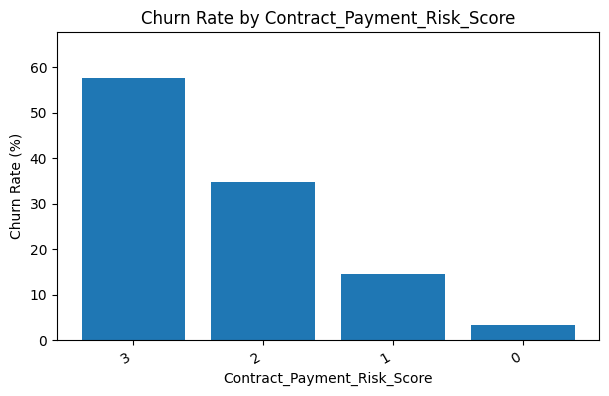

,Contract_Payment_Risk_Score,customer_count,churn_count,churn_rate(%)
3,3,1397,806,57.70
2,2,1987,692,34.83
1,1,2246,324,14.43
0,0,1413,47,3.33


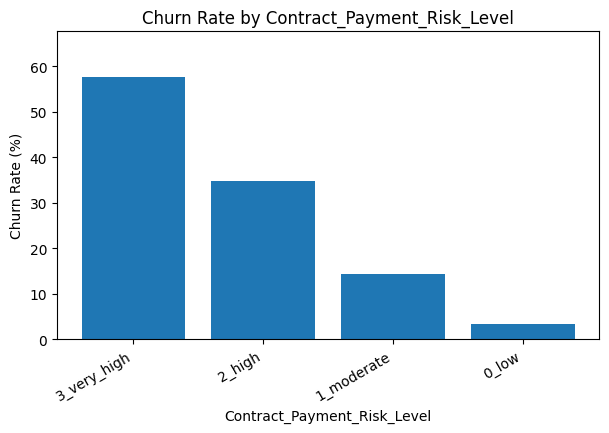

,Contract_Payment_Risk_Level,customer_count,churn_count,churn_rate(%)
3,3_very_high,1397,806,57.70
2,2_high,1987,692,34.83
1,1_moderate,2246,324,14.43
0,0_low,1413,47,3.33


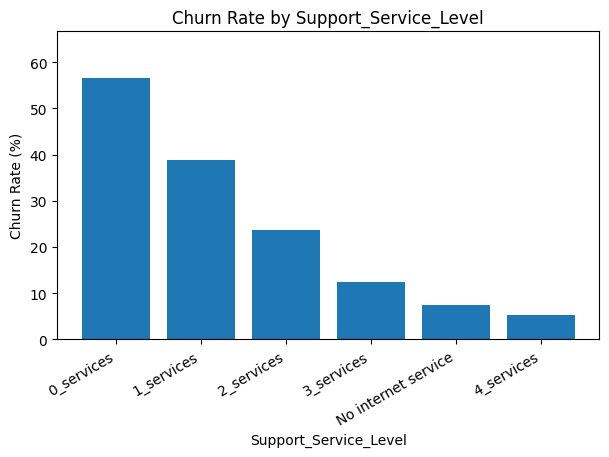

,Support_Service_Level,customer_count,churn_count,churn_rate(%)
0,0_services,1267,718,56.67
1,1_services,1467,570,38.85
2,2_services,1372,326,23.76
3,3_services,941,117,12.43
5,No internet service,1526,113,7.40
4,4_services,470,25,5.32


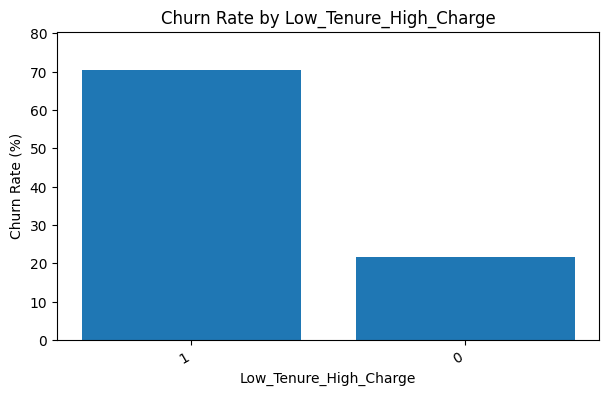

,Low_Tenure_High_Charge,customer_count,churn_count,churn_rate(%)
1,1,692,487,70.38
0,0,6351,1382,21.76


/tmp/ipykernel_5190/408519947.py:130: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  table = data.groupby(col, dropna=False).agg(


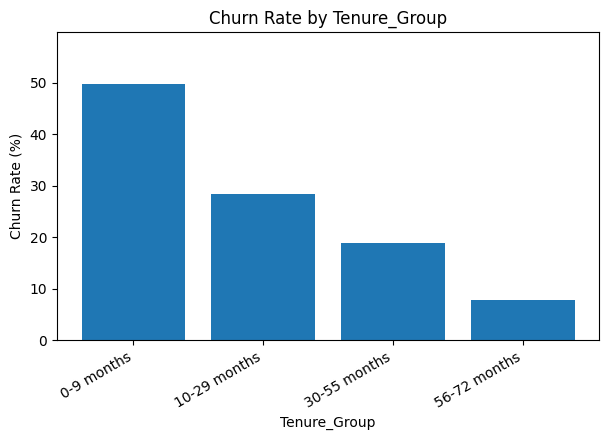

,Tenure_Group,customer_count,churn_count,churn_rate(%)
0,0-9 months,1854,923,49.78
1,10-29 months,1715,486,28.34
2,30-55 months,1719,324,18.85
3,56-72 months,1755,136,7.75


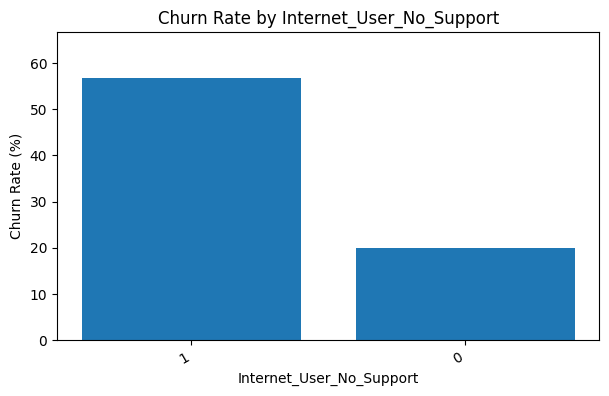

,Internet_User_No_Support,customer_count,churn_count,churn_rate(%)
1,1,1267,718,56.67
0,0,5776,1151,19.93


In [34]:
# =========================
# 1-11. EDA 기반 파생변수 생성 및 이탈률 확인
# =========================

df_fe = df_eda.copy()

target = "Churn Value"

# ---------------------------------------
# 1. 보안/지원 서비스 관련 파생변수
# ---------------------------------------

support_service_cols = [
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support"
]

# 인터넷 이용 여부
df_fe["Is_Internet_User"] = np.where(df_fe["Internet Service"] != "No", 1, 0)

# 보안/지원 서비스 Yes 개수
df_fe["Support_Service_Count"] = (df_fe[support_service_cols] == "Yes").sum(axis=1)

# 보안/지원 서비스 수준
# No internet service 고객은 별도 category로 분리
df_fe["Support_Service_Level"] = np.where(
    df_fe["Is_Internet_User"] == 0,
    "No internet service",
    df_fe["Support_Service_Count"].astype(str) + "_services"
)

# 인터넷 이용 고객 중 보안/지원 서비스를 하나도 사용하지 않는 고객
df_fe["Internet_User_No_Support"] = np.where(
    (df_fe["Is_Internet_User"] == 1) & (df_fe["Support_Service_Count"] == 0),
    1,
    0
)


# ---------------------------------------
# 2. 계약/결제 위험 점수
# ---------------------------------------

df_fe["Contract_Payment_Risk_Score"] = (
    (df_fe["Contract"] == "Month-to-month").astype(int)
    + (df_fe["Payment Method"] == "Electronic check").astype(int)
    + (df_fe["Paperless Billing"] == "Yes").astype(int)
)

df_fe["Contract_Payment_Risk_Level"] = df_fe["Contract_Payment_Risk_Score"].map({
    0: "0_low",
    1: "1_moderate",
    2: "2_high",
    3: "3_very_high"
})


# ---------------------------------------
# 3. 가입 기간 그룹
# 1-8 결과의 분위수 기준 사용
# ---------------------------------------

df_fe["Tenure_Group"] = pd.cut(
    df_fe["Tenure Months"],
    bins=[-1, 9, 29, 55, 72],
    labels=["0-9 months", "10-29 months", "30-55 months", "56-72 months"]
)


# ---------------------------------------
# 4. 요금 부담 관련 파생변수
# ---------------------------------------

df_fe["Monthly_Charge_Group"] = pd.cut(
    df_fe["Monthly Charges"],
    bins=[18.249, 35.5, 70.35, 89.85, 118.75],
    labels=["low", "mid", "high", "very_high"],
    include_lowest=True
)

df_fe["Income_Charge_Burden_Group"] = pd.qcut(
    df_fe["Income_Charge_Ratio"],
    q=4,
    labels=["low", "mid_low", "mid_high", "high"],
    duplicates="drop"
)


# ---------------------------------------
# 5. 짧은 가입 기간 + 높은 월 요금 결합 위험 변수
# ---------------------------------------

df_fe["Low_Tenure_High_Charge"] = np.where(
    (df_fe["Tenure Months"] <= 9) & (df_fe["Monthly Charges"] > 70.35),
    1,
    0
)


# ---------------------------------------
# 6. 파생변수 목록
# ---------------------------------------

derived_features = [
    "Is_Internet_User",
    "Support_Service_Count",
    "Support_Service_Level",
    "Internet_User_No_Support",
    "Contract_Payment_Risk_Score",
    "Contract_Payment_Risk_Level",
    "Tenure_Group",
    "Monthly_Charge_Group",
    "Income_Charge_Burden_Group",
    "Low_Tenure_High_Charge"
]

print("생성된 파생변수:")
print(derived_features)

display(df_fe[derived_features + [target]].head())


# ---------------------------------------
# 7. 파생변수별 이탈률 계산 함수
# ---------------------------------------

def derived_churn_rate_table(data, col, target="Churn Value"):
    table = data.groupby(col, dropna=False).agg(
        customer_count=(target, "count"),
        churn_count=(target, "sum"),
        churn_rate=(target, "mean")
    ).reset_index()

    table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
    table = table.drop(columns="churn_rate")
    table = table.sort_values("churn_rate(%)", ascending=False)

    return table


# ---------------------------------------
# 8. 파생변수별 이탈률 상세표
# ---------------------------------------

derived_churn_detail_list = []

for col in derived_features:
    temp = derived_churn_rate_table(df_fe, col, target)
    temp["feature"] = col
    temp = temp.rename(columns={col: "segment"})
    temp = temp[["feature", "segment", "customer_count", "churn_count", "churn_rate(%)"]]
    derived_churn_detail_list.append(temp)

derived_churn_detail = pd.concat(
    derived_churn_detail_list,
    axis=0
).reset_index(drop=True)

print("\n파생변수별 이탈률 상세표:")
display(derived_churn_detail)


# ---------------------------------------
# 9. 파생변수별 이탈률 차이 요약
# ---------------------------------------

derived_gap_list = []

for col in derived_features:
    temp = derived_churn_rate_table(df_fe, col, target)

    max_rate = temp["churn_rate(%)"].max()
    min_rate = temp["churn_rate(%)"].min()
    gap = max_rate - min_rate

    high_risk_segment = temp.loc[temp["churn_rate(%)"].idxmax(), col]
    low_risk_segment = temp.loc[temp["churn_rate(%)"].idxmin(), col]
    high_risk_count = temp.loc[temp["churn_rate(%)"].idxmax(), "customer_count"]

    derived_gap_list.append({
        "derived_feature": col,
        "max_churn_rate(%)": max_rate,
        "min_churn_rate(%)": min_rate,
        "gap(%p)": round(gap, 2),
        "high_risk_segment": high_risk_segment,
        "high_risk_customer_count": high_risk_count,
        "low_risk_segment": low_risk_segment
    })

derived_gap_summary = pd.DataFrame(derived_gap_list).sort_values(
    "gap(%p)",
    ascending=False
).reset_index(drop=True)

print("\n파생변수별 이탈률 차이 요약:")
display(derived_gap_summary)


# ---------------------------------------
# 10. 이탈률 차이가 큰 파생변수 그래프
# ---------------------------------------

top_derived_features = derived_gap_summary.head(6)["derived_feature"].tolist()

for col in top_derived_features:
    temp = derived_churn_rate_table(df_fe, col, target)

    plt.figure(figsize=(7, 4))
    plt.bar(temp[col].astype(str), temp["churn_rate(%)"])
    plt.title(f"Churn Rate by {col}")
    plt.xlabel(col)
    plt.ylabel("Churn Rate (%)")
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, max(temp["churn_rate(%)"]) + 10)
    plt.show()

    display(temp)

| 파생변수                          | 묶은 원본 변수                                                                | 생성 의미                                                               | 유용성                                                |
| ----------------------------- | ----------------------------------------------------------------------- | ------------------------------------------------------------------- | -------------------------------------------------- |
| `Is_Internet_User`            | `Internet Service`                                                      | 인터넷 서비스 이용 여부                                                       | 인터넷 미이용 고객과 이용 고객의 이탈률 구조가 다르므로 기본 구분 변수로 사용       |
| `Support_Service_Count`       | `Online Security`, `Online Backup`, `Device Protection`, `Tech Support` | 보안/지원 서비스 이용 개수                                                     | 서비스 이용 개수가 많을수록 이탈률이 낮아지는지 확인 가능                   |
| `Support_Service_Level`       | `Support_Service_Count` + `Internet Service`                            | 인터넷 미이용 고객을 따로 분리하고, 인터넷 이용 고객은 0~4개 서비스 이용 수준으로 구분                 | 가장 유용함. 0개 이용 고객 이탈률 56.67%, 4개 이용 고객 5.32%로 차이가 큼 |
| `Internet_User_No_Support`    | `Internet Service` + 보안/지원 4개 변수                                        | 인터넷은 쓰지만 보안/지원 서비스를 하나도 쓰지 않는 고객                                    | 명확한 고위험군 정의 가능. 해당 고객 이탈률 56.67%                   |
| `Contract_Payment_Risk_Score` | `Contract`, `Payment Method`, `Paperless Billing`                       | Month-to-month, Electronic check, Paperless Billing Yes를 각각 1점으로 합산 | 계약/결제 위험 신호가 누적될수록 이탈률이 단계적으로 증가                   |
| `Contract_Payment_Risk_Level` | `Contract_Payment_Risk_Score`                                           | 위험 점수를 low/moderate/high/very high로 라벨링                             | 보고서와 전략 제안에서 해석하기 쉬움                               |
| `Tenure_Group`                | `Tenure Months`                                                         | 가입 기간을 0-9, 10-29, 30-55, 56-72개월로 구간화                              | 신규 고객일수록 이탈률이 높은 패턴을 명확히 보여줌                       |
| `Monthly_Charge_Group`        | `Monthly Charges`                                                       | 월 요금 수준을 low/mid/high/very high로 구간화                                | 요금 부담과 이탈률의 관계 확인 가능                               |
| `Income_Charge_Burden_Group`  | `Income_Charge_Ratio`                                                   | 지역 소득 대비 요금 부담 수준 구간화                                               | 단순 요금보다 상대적 요금 부담을 반영                              |
| `Low_Tenure_High_Charge`      | `Tenure Months`, `Monthly Charges`                                      | 가입 기간 9개월 이하이면서 월 요금이 높은 고객                                         | 가장 강한 고위험군 중 하나. 이탈률 70.38%                        |


>가장 강하게 나온 파생변수는 Contract_Payment_Risk_Score, Support_Service_Level, Low_Tenure_High_Charge입니다.

>특히 Contract_Payment_Risk_Score는 위험 점수가 0점일 때 이탈률이 **3.33%**인데, 3점일 때는 **57.70%**까지 증가했습니다. 즉, 월 단위 계약 + Electronic check + Paperless Billing이 동시에 나타나는 고객은 매우 높은 이탈 위험군으로 볼 수 있습니다.

>Support_Service_Level도 매우 좋습니다. 보안/지원 서비스를 하나도 사용하지 않는 인터넷 고객의 이탈률은 **56.67%**인 반면, 4개 서비스를 모두 사용하는 고객의 이탈률은 **5.32%**입니다. 이 변수는 단순히 Online Security, Tech Support를 따로 보는 것보다 “지원 서비스 이용 수준”이라는 하나의 해석 가능한 위험 요인으로 정리할 수 있습니다.

>Low_Tenure_High_Charge는 가입 기간이 짧고 월 요금이 높은 고객을 따로 묶은 변수입니다. 이 고객군의 이탈률은 **70.38%**로 매우 높게 나타났습니다. 따라서 리텐션 전략에서는 이 고객군을 최우선 관리 대상으로 볼 수 있습니다.

> EDA 결과를 바탕으로 의미가 비슷한 변수들을 묶어 파생변수를 생성하였다. 보안/지원 서비스 관련 변수인 `Online Security`, `Online Backup`, `Device Protection`, `Tech Support`를 묶어 `Support_Service_Level`을 만들었고, 계약/결제 관련 변수인 `Contract`, `Payment Method`, `Paperless Billing`을 묶어 `Contract_Payment_Risk_Score`를 생성하였다. 또한 짧은 가입 기간과 높은 월 요금이 동시에 나타나는 고객을 구분하기 위해 `Low_Tenure_High_Charge` 변수를 만들었다.
>
> 파생변수 분석 결과, `Contract_Payment_Risk_Score`가 3점인 고객의 이탈률은 57.70%로 0점 고객의 3.33%보다 매우 높았다. 또한 보안/지원 서비스를 하나도 사용하지 않는 인터넷 고객의 이탈률은 56.67%, 짧은 가입 기간과 높은 월 요금을 동시에 가진 고객의 이탈률은 70.38%로 나타났다. 따라서 파생변수는 개별 변수보다 고위험 고객군을 더 명확하게 구분하는 데 유용하다.
---

###1-11 추가 분석: Zip Code 기반 지역 소득 변수의 효용성 확인


[Area_Median_Income] 이탈률 확인


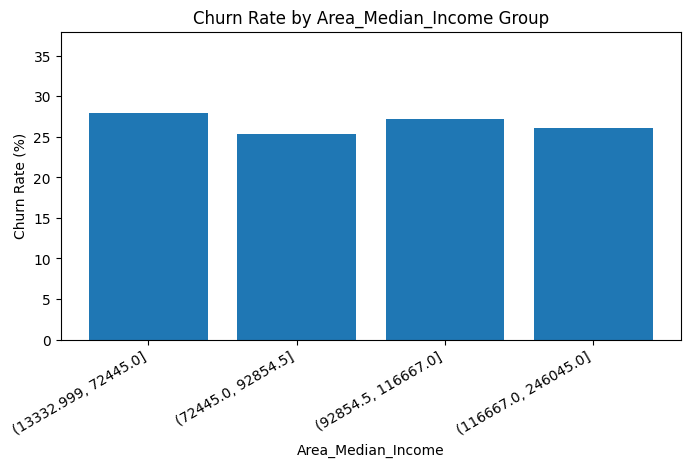

,Area_Median_Income_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(13332.999, 72445.0]",1763,493,56748.029,27.96
1,"(72445.0, 92854.5]",2086,528,85183.492,25.31
2,"(92854.5, 116667.0]",1435,390,104184.081,27.18
3,"(116667.0, 246045.0]",1759,458,152726.406,26.04



[Area_Mean_Income] 이탈률 확인


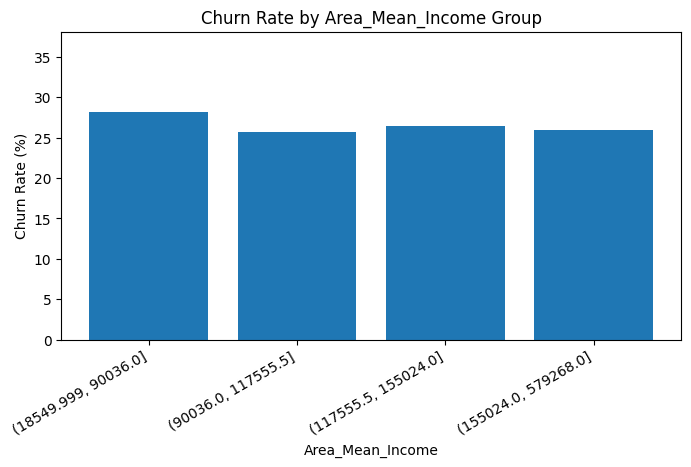

,Area_Mean_Income_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(18549.999, 90036.0]",1764,496,71396.401,28.12
1,"(90036.0, 117555.5]",1889,485,105197.524,25.67
2,"(117555.5, 155024.0]",1630,431,134645.293,26.44
3,"(155024.0, 579268.0]",1760,457,214163.518,25.97



[Area_Income_Level] 이탈률 확인


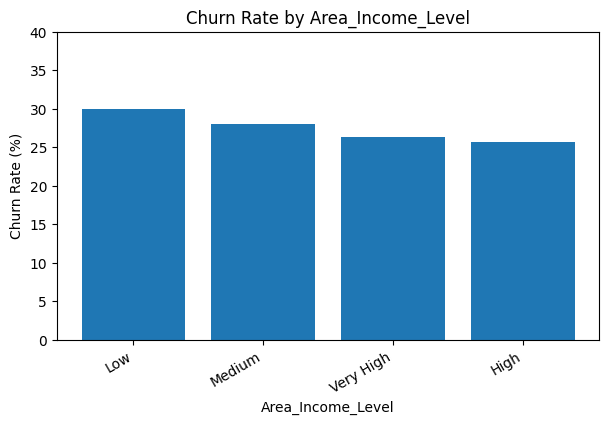

,Area_Income_Level,customer_count,churn_count,churn_rate(%)
1,Low,150,45,30.00
2,Medium,1852,520,28.08
3,Very High,1648,434,26.33
0,High,3393,870,25.64



[Income_Charge_Ratio] 이탈률 확인


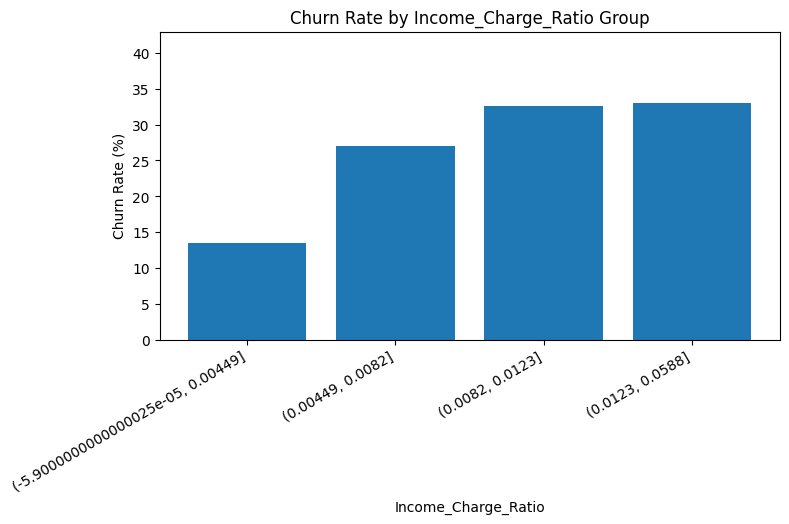

,Income_Charge_Ratio_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(-5.9000000000000025e-05, 0.00449]",1761,237,0.003,13.46
1,"(0.00449, 0.0082]",1761,476,0.006,27.03
2,"(0.0082, 0.0123]",1760,575,0.010,32.67
3,"(0.0123, 0.0588]",1761,581,0.017,32.99



지역 소득 변수별 이탈률 차이 요약:


,feature,max_churn_rate(%),min_churn_rate(%),gap(%p),high_risk_segment,low_risk_segment
3,Income_Charge_Ratio,32.99,13.46,19.53,"(0.0123, 0.0588]","(-5.9000000000000025e-05, 0.00449]"
2,Area_Income_Level,30.00,25.64,4.36,Low,High
0,Area_Median_Income,27.96,25.31,2.65,"(13332.999, 72445.0]","(72445.0, 92854.5]"
1,Area_Mean_Income,28.12,25.67,2.45,"(18549.999, 90036.0]","(90036.0, 117555.5]"


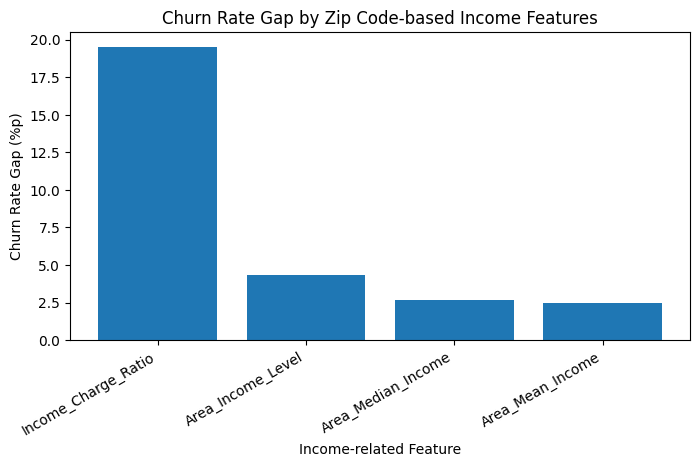

/tmp/ipykernel_5190/108922124.py:159: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


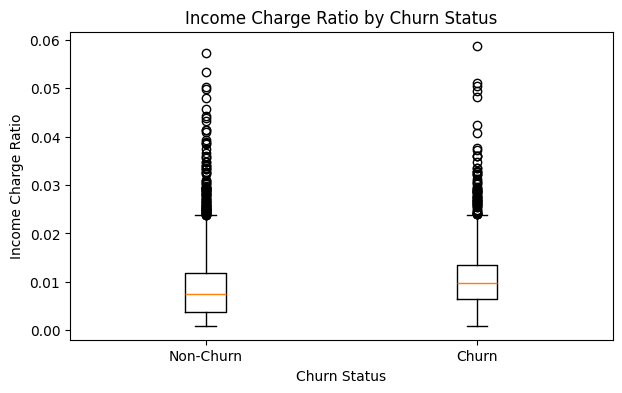

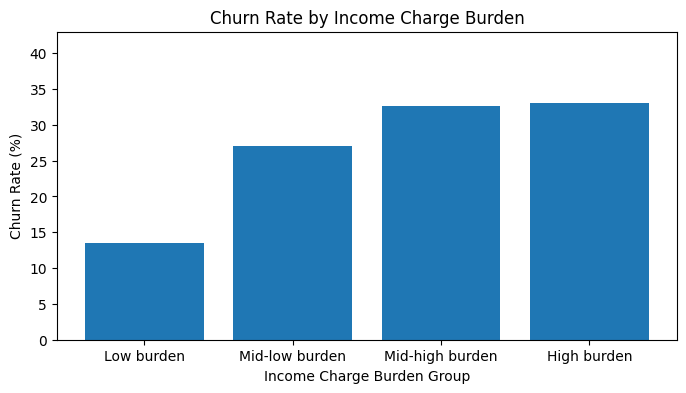

,Income_Charge_Ratio_bin,customer_count,churn_count,avg_value,churn_rate(%)
0,"(-5.9000000000000025e-05, 0.00449]",1761,237,0.003,13.46
1,"(0.00449, 0.0082]",1761,476,0.006,27.03
2,"(0.0082, 0.0123]",1760,575,0.010,32.67
3,"(0.0123, 0.0588]",1761,581,0.017,32.99


In [36]:
# =========================
# 1-11 추가. Zip Code 기반 지역 소득 변수의 효용성 확인
# =========================

target = "Churn Value"

income_features = [
    "Area_Median_Income",
    "Area_Mean_Income",
    "Area_Income_Level",
    "Income_Charge_Ratio"
]


# =========================
# 1. 범주형 변수 이탈률 계산 함수
# =========================

def churn_rate_by_category(data, col, target="Churn Value"):
    table = data.groupby(col, dropna=False).agg(
        customer_count=(target, "count"),
        churn_count=(target, "sum"),
        churn_rate=(target, "mean")
    ).reset_index()

    table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
    table = table.drop(columns="churn_rate")
    table = table.sort_values("churn_rate(%)", ascending=False)

    return table


# =========================
# 2. 수치형 변수 구간별 이탈률 계산 함수
# =========================

def churn_rate_by_numeric_bin(data, col, target="Churn Value", q=4):
    temp = data[[col, target]].dropna().copy()

    temp[col + "_bin"] = pd.qcut(
        temp[col],
        q=q,
        duplicates="drop"
    )

    table = temp.groupby(col + "_bin", observed=False).agg(
        customer_count=(target, "count"),
        churn_count=(target, "sum"),
        churn_rate=(target, "mean"),
        avg_value=(col, "mean")
    ).reset_index()

    table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
    table["avg_value"] = table["avg_value"].round(3)
    table = table.drop(columns="churn_rate")

    return table


# =========================
# 3. 지역 소득 변수별 이탈률 그래프
# =========================

for col in income_features:
    print("\n" + "=" * 80)
    print(f"[{col}] 이탈률 확인")

    if df_eda[col].dtype == "object":
        table = churn_rate_by_category(df_eda, col, target)

        plt.figure(figsize=(7, 4))
        plt.bar(table[col].astype(str), table["churn_rate(%)"])
        plt.title(f"Churn Rate by {col}")
        plt.xlabel(col)
        plt.ylabel("Churn Rate (%)")
        plt.xticks(rotation=30, ha="right")
        plt.ylim(0, max(table["churn_rate(%)"]) + 10)
        plt.show()

        display(table)

    else:
        table = churn_rate_by_numeric_bin(df_eda, col, target, q=4)

        plt.figure(figsize=(8, 4))
        plt.bar(table[col + "_bin"].astype(str), table["churn_rate(%)"])
        plt.title(f"Churn Rate by {col} Group")
        plt.xlabel(col)
        plt.ylabel("Churn Rate (%)")
        plt.xticks(rotation=30, ha="right")
        plt.ylim(0, max(table["churn_rate(%)"]) + 10)
        plt.show()

        display(table)


# =========================
# 4. 지역 소득 변수별 이탈률 차이 요약
# =========================

income_gap_list = []

for col in income_features:

    if df_eda[col].dtype == "object":
        table = churn_rate_by_category(df_eda, col, target)

        max_rate = table["churn_rate(%)"].max()
        min_rate = table["churn_rate(%)"].min()
        gap = max_rate - min_rate

        high_risk_segment = table.loc[table["churn_rate(%)"].idxmax(), col]
        low_risk_segment = table.loc[table["churn_rate(%)"].idxmin(), col]

    else:
        table = churn_rate_by_numeric_bin(df_eda, col, target, q=4)

        max_rate = table["churn_rate(%)"].max()
        min_rate = table["churn_rate(%)"].min()
        gap = max_rate - min_rate

        high_risk_segment = table.loc[table["churn_rate(%)"].idxmax(), col + "_bin"]
        low_risk_segment = table.loc[table["churn_rate(%)"].idxmin(), col + "_bin"]

    income_gap_list.append({
        "feature": col,
        "max_churn_rate(%)": max_rate,
        "min_churn_rate(%)": min_rate,
        "gap(%p)": round(gap, 2),
        "high_risk_segment": high_risk_segment,
        "low_risk_segment": low_risk_segment
    })

income_gap_summary = pd.DataFrame(income_gap_list)
income_gap_summary = income_gap_summary.sort_values("gap(%p)", ascending=False)

print("\n지역 소득 변수별 이탈률 차이 요약:")
display(income_gap_summary)


# =========================
# 5. 지역 소득 변수 효용성 비교 그래프
# =========================

plt.figure(figsize=(8, 4))
plt.bar(income_gap_summary["feature"], income_gap_summary["gap(%p)"])
plt.title("Churn Rate Gap by Zip Code-based Income Features")
plt.xlabel("Income-related Feature")
plt.ylabel("Churn Rate Gap (%p)")
plt.xticks(rotation=30, ha="right")
plt.show()


# =========================
# 6. Churn 여부에 따른 Income_Charge_Ratio 분포 비교
# =========================

plt.figure(figsize=(7, 4))
plt.boxplot(
    [
        df_eda[df_eda[target] == 0]["Income_Charge_Ratio"].dropna(),
        df_eda[df_eda[target] == 1]["Income_Charge_Ratio"].dropna()
    ],
    labels=["Non-Churn", "Churn"]
)
plt.title("Income Charge Ratio by Churn Status")
plt.xlabel("Churn Status")
plt.ylabel("Income Charge Ratio")
plt.show()


# =========================
# 7. 보고서용 핵심 그래프: Income_Charge_Ratio 구간별 이탈률
# =========================

income_charge_table = churn_rate_by_numeric_bin(
    df_eda,
    "Income_Charge_Ratio",
    target,
    q=4
)

plt.figure(figsize=(8, 4))
plt.bar(
    ["Low burden", "Mid-low burden", "Mid-high burden", "High burden"],
    income_charge_table["churn_rate(%)"]
)
plt.title("Churn Rate by Income Charge Burden")
plt.xlabel("Income Charge Burden Group")
plt.ylabel("Churn Rate (%)")
plt.ylim(0, max(income_charge_table["churn_rate(%)"]) + 10)
plt.show()

display(income_charge_table)

> Zip Code 기반 지역 소득 변수의 효용성을 확인하기 위해 지역 중위소득, 지역 평균소득, 지역 소득 수준, 소득 대비 요금 부담 비율의 이탈률 차이를 비교하였다. 분석 결과, 지역 소득 자체를 나타내는 변수보다 `Income_Charge_Ratio`의 이탈률 차이가 더 크게 나타났다. 이는 고객 이탈을 설명할 때 단순히 거주 지역의 소득 수준보다, 해당 지역 소득 대비 월 요금 부담이 더 중요한 해석 변수일 수 있음을 의미한다.
---

##1-12. EDA 최종 위험 요인 후보 정리표
| 단계  | 구성                                     | 목적                                 |
| --- | -------------------------------------- | ---------------------------------- |
| 1단계 | 원본 변수만, `Income_Charge_Ratio` 제외       | 기존 Telco 변수만으로 위험 요인 확인            |
| 2단계 | 원본 변수만, `Income_Charge_Ratio` 포함       | Zip Code 기반 요금 부담 변수를 추가했을 때 변화 확인 |
| 3단계 | 원본 변수 + 파생변수, `Income_Charge_Ratio` 제외 | 파생변수의 효과 확인                        |
| 4단계 | 원본 변수 + 파생변수, `Income_Charge_Ratio` 포함 | 최종 확장 후보군 확인                       |


4단계 후보군 구성:


,stage,feature
0,1_original_without_income_charge_ratio,Tenure Months
1,1_original_without_income_charge_ratio,Contract
2,1_original_without_income_charge_ratio,Internet Service
3,1_original_without_income_charge_ratio,Online Security
4,1_original_without_income_charge_ratio,Tech Support
5,1_original_without_income_charge_ratio,Online Backup
6,1_original_without_income_charge_ratio,Device Protection
7,1_original_without_income_charge_ratio,Payment Method
8,1_original_without_income_charge_ratio,Total Charges
9,1_original_without_income_charge_ratio,Monthly Charges



전체 단계별 후보 변수 이탈률 차이 요약:


,stage,feature,high_risk_segment,high_risk_customer_count,high_risk_churn_count,high_risk_churn_rate(%),low_risk_segment,low_risk_churn_rate(%),gap(%p)
0,1_original_without_income_charge_ratio,Tenure Months,"(-0.001, 9.0]",1854,923,49.78,"(55.0, 72.0]",7.75,42.03
1,1_original_without_income_charge_ratio,Contract,Month-to-month,3875,1655,42.71,Two year,2.83,39.88
2,1_original_without_income_charge_ratio,Internet Service,Fiber optic,3096,1297,41.89,No,7.40,34.49
3,1_original_without_income_charge_ratio,Online Security,No,3498,1461,41.77,No internet service,7.40,34.37
4,1_original_without_income_charge_ratio,Tech Support,No,3473,1446,41.64,No internet service,7.40,34.24
5,1_original_without_income_charge_ratio,Online Backup,No,3088,1233,39.93,No internet service,7.40,32.53
6,1_original_without_income_charge_ratio,Device Protection,No,3095,1211,39.13,No internet service,7.40,31.73
7,1_original_without_income_charge_ratio,Payment Method,Electronic check,2365,1071,45.29,Credit card (automatic),15.24,30.05
8,1_original_without_income_charge_ratio,Total Charges,"(18.799, 401.45]",1758,764,43.46,"(3794.738, 8684.8]",14.51,28.95
9,1_original_without_income_charge_ratio,Streaming Movies,No,2785,938,33.68,No internet service,7.40,26.28



단계별 Top 10 위험 요인 후보:


,stage,feature,high_risk_segment,high_risk_customer_count,high_risk_churn_count,high_risk_churn_rate(%),low_risk_segment,low_risk_churn_rate(%),gap(%p)
0,1_original_without_income_charge_ratio,Tenure Months,"(-0.001, 9.0]",1854,923,49.78,"(55.0, 72.0]",7.75,42.03
1,1_original_without_income_charge_ratio,Contract,Month-to-month,3875,1655,42.71,Two year,2.83,39.88
2,1_original_without_income_charge_ratio,Internet Service,Fiber optic,3096,1297,41.89,No,7.40,34.49
3,1_original_without_income_charge_ratio,Online Security,No,3498,1461,41.77,No internet service,7.40,34.37
4,1_original_without_income_charge_ratio,Tech Support,No,3473,1446,41.64,No internet service,7.40,34.24
5,1_original_without_income_charge_ratio,Online Backup,No,3088,1233,39.93,No internet service,7.40,32.53
6,1_original_without_income_charge_ratio,Device Protection,No,3095,1211,39.13,No internet service,7.40,31.73
7,1_original_without_income_charge_ratio,Payment Method,Electronic check,2365,1071,45.29,Credit card (automatic),15.24,30.05
8,1_original_without_income_charge_ratio,Total Charges,"(18.799, 401.45]",1758,764,43.46,"(3794.738, 8684.8]",14.51,28.95
9,1_original_without_income_charge_ratio,Streaming Movies,No,2785,938,33.68,No internet service,7.40,26.28



단계별 요약:


,stage,feature_count,max_gap,mean_top5_gap,best_feature
0,1_original_without_income_charge_ratio,16,42.03,37.00,Tenure Months
1,2_original_with_income_charge_ratio,17,42.03,37.00,Tenure Months
2,3_derived_without_income_charge_ratio,24,54.37,48.79,Contract_Payment_Risk_Level
3,4_derived_with_income_charge_ratio,26,54.37,48.79,Contract_Payment_Risk_Level


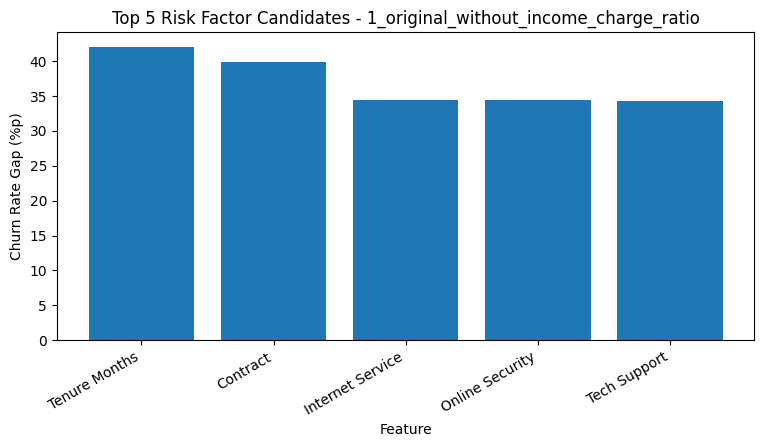

,stage,feature,high_risk_segment,high_risk_customer_count,high_risk_churn_count,high_risk_churn_rate(%),low_risk_segment,low_risk_churn_rate(%),gap(%p)
0,1_original_without_income_charge_ratio,Tenure Months,"(-0.001, 9.0]",1854,923,49.78,"(55.0, 72.0]",7.75,42.03
1,1_original_without_income_charge_ratio,Contract,Month-to-month,3875,1655,42.71,Two year,2.83,39.88
2,1_original_without_income_charge_ratio,Internet Service,Fiber optic,3096,1297,41.89,No,7.40,34.49
3,1_original_without_income_charge_ratio,Online Security,No,3498,1461,41.77,No internet service,7.40,34.37
4,1_original_without_income_charge_ratio,Tech Support,No,3473,1446,41.64,No internet service,7.40,34.24


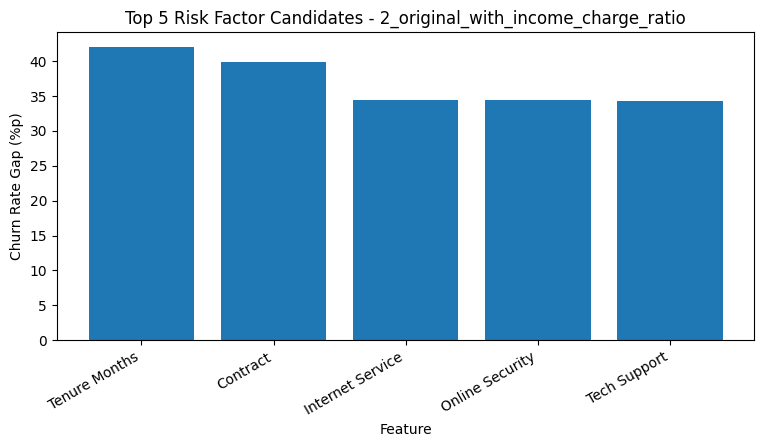

,stage,feature,high_risk_segment,high_risk_customer_count,high_risk_churn_count,high_risk_churn_rate(%),low_risk_segment,low_risk_churn_rate(%),gap(%p)
16,2_original_with_income_charge_ratio,Tenure Months,"(-0.001, 9.0]",1854,923,49.78,"(55.0, 72.0]",7.75,42.03
17,2_original_with_income_charge_ratio,Contract,Month-to-month,3875,1655,42.71,Two year,2.83,39.88
18,2_original_with_income_charge_ratio,Internet Service,Fiber optic,3096,1297,41.89,No,7.40,34.49
19,2_original_with_income_charge_ratio,Online Security,No,3498,1461,41.77,No internet service,7.40,34.37
20,2_original_with_income_charge_ratio,Tech Support,No,3473,1446,41.64,No internet service,7.40,34.24


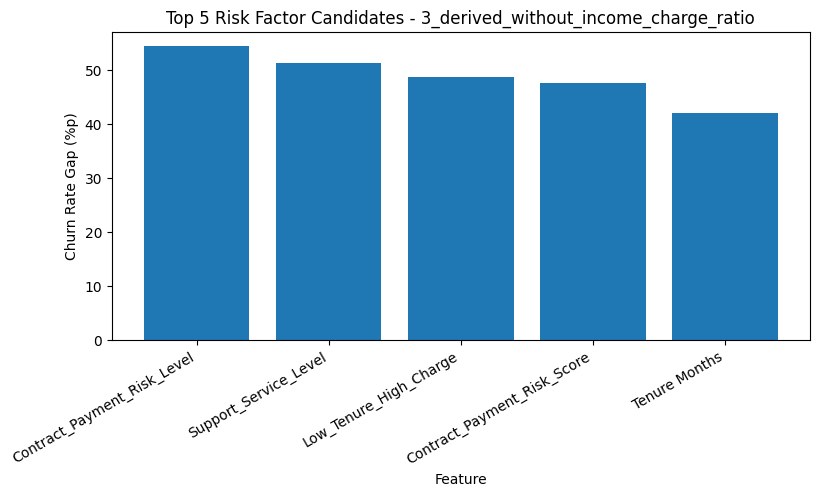

,stage,feature,high_risk_segment,high_risk_customer_count,high_risk_churn_count,high_risk_churn_rate(%),low_risk_segment,low_risk_churn_rate(%),gap(%p)
33,3_derived_without_income_charge_ratio,Contract_Payment_Risk_Level,3_very_high,1397,806,57.70,0_low,3.33,54.37
34,3_derived_without_income_charge_ratio,Support_Service_Level,0_services,1267,718,56.67,4_services,5.32,51.35
35,3_derived_without_income_charge_ratio,Low_Tenure_High_Charge,1,692,487,70.38,0,21.76,48.62
36,3_derived_without_income_charge_ratio,Contract_Payment_Risk_Score,"(2.0, 3.0]",1397,806,57.70,"(-0.001, 1.0]",10.14,47.56
37,3_derived_without_income_charge_ratio,Tenure Months,"(-0.001, 9.0]",1854,923,49.78,"(55.0, 72.0]",7.75,42.03


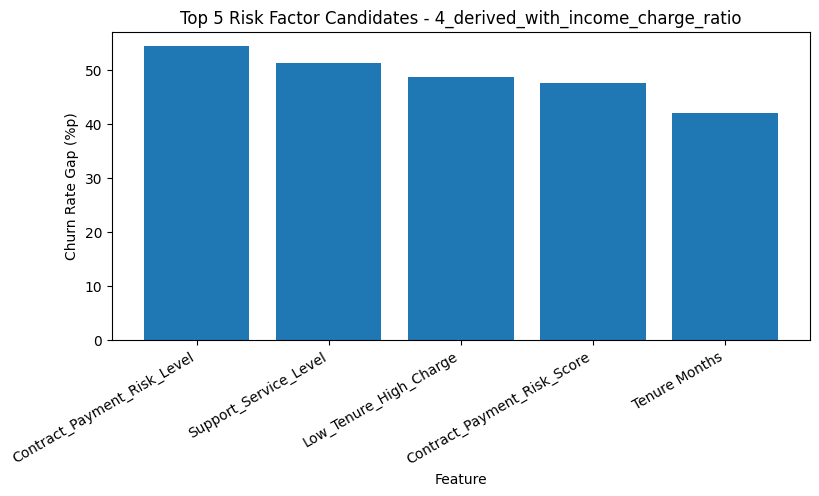

,stage,feature,high_risk_segment,high_risk_customer_count,high_risk_churn_count,high_risk_churn_rate(%),low_risk_segment,low_risk_churn_rate(%),gap(%p)
57,4_derived_with_income_charge_ratio,Contract_Payment_Risk_Level,3_very_high,1397,806,57.70,0_low,3.33,54.37
58,4_derived_with_income_charge_ratio,Support_Service_Level,0_services,1267,718,56.67,4_services,5.32,51.35
59,4_derived_with_income_charge_ratio,Low_Tenure_High_Charge,1,692,487,70.38,0,21.76,48.62
60,4_derived_with_income_charge_ratio,Contract_Payment_Risk_Score,"(2.0, 3.0]",1397,806,57.70,"(-0.001, 1.0]",10.14,47.56
61,4_derived_with_income_charge_ratio,Tenure Months,"(-0.001, 9.0]",1854,923,49.78,"(55.0, 72.0]",7.75,42.03


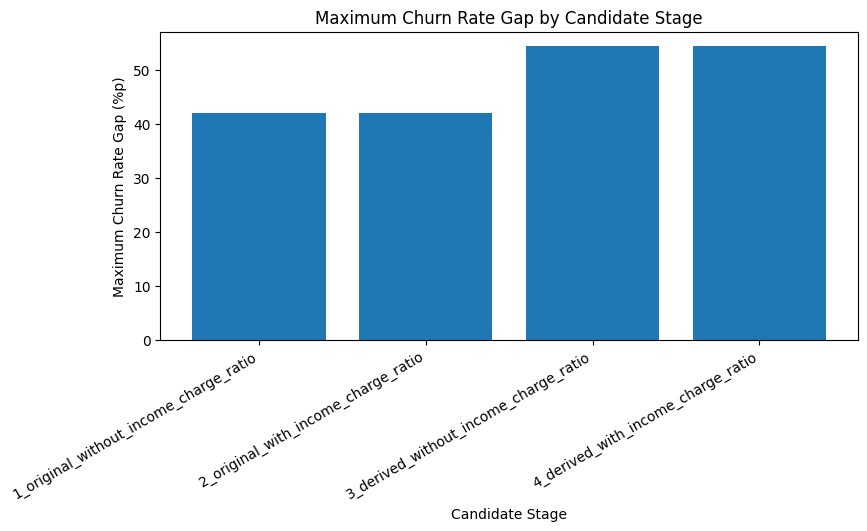

In [38]:
# =========================
# 1-12. 최종 후보군 4단계 비교
# =========================

target = "Churn Value"


# -------------------------------------------------
# 1. 이탈률 계산 함수
# -------------------------------------------------

def churn_rate_table_for_feature(data, col, target="Churn Value", q=4):
    """
    범주형 변수는 category별 이탈률,
    수치형 변수는 분위수 구간별 이탈률을 계산한다.
    """

    if pd.api.types.is_numeric_dtype(data[col]):
        temp = data[[col, target]].dropna().copy()

        if temp[col].nunique() <= 2:
            table = temp.groupby(col, dropna=False).agg(
                customer_count=(target, "count"),
                churn_count=(target, "sum"),
                churn_rate=(target, "mean")
            ).reset_index()

            table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
            table = table.drop(columns="churn_rate")
            table = table.rename(columns={col: "segment"})
            return table

        temp[col + "_bin"] = pd.qcut(
            temp[col],
            q=q,
            duplicates="drop"
        )

        table = temp.groupby(col + "_bin", observed=False).agg(
            customer_count=(target, "count"),
            churn_count=(target, "sum"),
            churn_rate=(target, "mean"),
            avg_value=(col, "mean")
        ).reset_index()

        table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
        table["avg_value"] = table["avg_value"].round(3)
        table = table.drop(columns="churn_rate")
        table = table.rename(columns={col + "_bin": "segment"})

        return table

    else:
        table = data.groupby(col, dropna=False, observed=False).agg(
            customer_count=(target, "count"),
            churn_count=(target, "sum"),
            churn_rate=(target, "mean")
        ).reset_index()

        table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
        table = table.drop(columns="churn_rate")
        table = table.rename(columns={col: "segment"})

        return table


def make_candidate_summary(data, feature_list, stage_name, target="Churn Value"):
    """
    후보 변수 리스트에 대해 이탈률 차이 요약표 생성
    """

    result_list = []

    for col in feature_list:
        table = churn_rate_table_for_feature(data, col, target)

        max_rate = table["churn_rate(%)"].max()
        min_rate = table["churn_rate(%)"].min()
        gap = max_rate - min_rate

        high_segment = table.loc[table["churn_rate(%)"].idxmax(), "segment"]
        low_segment = table.loc[table["churn_rate(%)"].idxmin(), "segment"]
        high_count = table.loc[table["churn_rate(%)"].idxmax(), "customer_count"]
        high_churn_count = table.loc[table["churn_rate(%)"].idxmax(), "churn_count"]

        result_list.append({
            "stage": stage_name,
            "feature": col,
            "high_risk_segment": high_segment,
            "high_risk_customer_count": high_count,
            "high_risk_churn_count": high_churn_count,
            "high_risk_churn_rate(%)": max_rate,
            "low_risk_segment": low_segment,
            "low_risk_churn_rate(%)": min_rate,
            "gap(%p)": round(gap, 2)
        })

    result = pd.DataFrame(result_list)
    result = result.sort_values("gap(%p)", ascending=False).reset_index(drop=True)

    return result


# -------------------------------------------------
# 2. 4단계 후보군 정의
# -------------------------------------------------

# 1단계: 파생변수 X, 원본 변수만, Income_Charge_Ratio 제외
stage1_features = [
    "Tenure Months",
    "Contract",
    "Internet Service",
    "Online Security",
    "Tech Support",
    "Online Backup",
    "Device Protection",
    "Payment Method",
    "Total Charges",
    "Monthly Charges",
    "Streaming TV",
    "Streaming Movies",
    "Dependents",
    "Senior Citizen",
    "Paperless Billing",
    "Partner"
]


# 2단계: 파생변수 X, 원본 변수만, Income_Charge_Ratio 포함
stage2_features = stage1_features + [
    "Income_Charge_Ratio"
]


# 3단계: 파생변수 O, Income_Charge_Ratio 제외
# 단, Income_Charge_Ratio 기반 파생변수인 Income_Charge_Burden_Group은 제외
stage3_features = stage1_features + [
    "Contract_Payment_Risk_Score",
    "Contract_Payment_Risk_Level",
    "Support_Service_Count",
    "Support_Service_Level",
    "Internet_User_No_Support",
    "Tenure_Group",
    "Monthly_Charge_Group",
    "Low_Tenure_High_Charge"
]


# 4단계: 파생변수 O, Income_Charge_Ratio 포함
# 원본 Income_Charge_Ratio와 이를 구간화한 Income_Charge_Burden_Group까지 포함
stage4_features = stage3_features + [
    "Income_Charge_Ratio",
    "Income_Charge_Burden_Group"
]


candidate_groups = {
    "1_original_without_income_charge_ratio": stage1_features,
    "2_original_with_income_charge_ratio": stage2_features,
    "3_derived_without_income_charge_ratio": stage3_features,
    "4_derived_with_income_charge_ratio": stage4_features
}


# -------------------------------------------------
# 3. 단계별 후보 변수 출력
# -------------------------------------------------

candidate_group_table = []

for stage_name, features in candidate_groups.items():
    for feature in features:
        candidate_group_table.append({
            "stage": stage_name,
            "feature": feature
        })

candidate_group_table = pd.DataFrame(candidate_group_table)

print("4단계 후보군 구성:")
display(candidate_group_table)


# -------------------------------------------------
# 4. 단계별 이탈률 차이 요약표 생성
# -------------------------------------------------

stage_summary_list = []

for stage_name, features in candidate_groups.items():
    summary = make_candidate_summary(
        df_fe,
        features,
        stage_name,
        target
    )
    stage_summary_list.append(summary)

all_stage_risk_summary = pd.concat(
    stage_summary_list,
    axis=0
).reset_index(drop=True)

print("\n전체 단계별 후보 변수 이탈률 차이 요약:")
display(all_stage_risk_summary)


# -------------------------------------------------
# 5. 각 단계별 Top 10 후보만 확인
# -------------------------------------------------

top10_by_stage = all_stage_risk_summary.groupby("stage").head(10).reset_index(drop=True)

print("\n단계별 Top 10 위험 요인 후보:")
display(top10_by_stage)


# -------------------------------------------------
# 6. 단계별 최고 gap 비교
# -------------------------------------------------

stage_level_summary = all_stage_risk_summary.groupby("stage").agg(
    feature_count=("feature", "count"),
    max_gap=("gap(%p)", "max"),
    mean_top5_gap=("gap(%p)", lambda x: round(x.sort_values(ascending=False).head(5).mean(), 2)),
    best_feature=("feature", lambda x: all_stage_risk_summary.loc[x.index, :].sort_values("gap(%p)", ascending=False).iloc[0]["feature"])
).reset_index()

stage_level_summary = stage_level_summary.sort_values("stage")

print("\n단계별 요약:")
display(stage_level_summary)


# -------------------------------------------------
# 7. 단계별 Top 5 후보 그래프
# -------------------------------------------------

for stage_name in candidate_groups.keys():
    temp = all_stage_risk_summary[
        all_stage_risk_summary["stage"] == stage_name
    ].head(5)

    plt.figure(figsize=(9, 4))
    plt.bar(temp["feature"], temp["gap(%p)"])
    plt.title(f"Top 5 Risk Factor Candidates - {stage_name}")
    plt.xlabel("Feature")
    plt.ylabel("Churn Rate Gap (%p)")
    plt.xticks(rotation=30, ha="right")
    plt.show()

    display(temp)


# -------------------------------------------------
# 8. 단계별 최고 후보 비교 그래프
# -------------------------------------------------

plt.figure(figsize=(9, 4))
plt.bar(stage_level_summary["stage"], stage_level_summary["max_gap"])
plt.title("Maximum Churn Rate Gap by Candidate Stage")
plt.xlabel("Candidate Stage")
plt.ylabel("Maximum Churn Rate Gap (%p)")
plt.xticks(rotation=30, ha="right")
plt.show()

| 단계  | 구성                                |  최고 gap | Top5 평균 gap | 최고 후보                         |
| --- | --------------------------------- | ------: | ----------: | ----------------------------- |
| 1단계 | 원본 변수만, `Income_Charge_Ratio` 제외  | 42.03%p |     37.00%p | `Tenure Months`               |
| 2단계 | 원본 변수만, `Income_Charge_Ratio` 포함  | 42.03%p |     37.00%p | `Tenure Months`               |
| 3단계 | 파생변수 포함, `Income_Charge_Ratio` 제외 | 54.37%p |     48.79%p | `Contract_Payment_Risk_Level` |
| 4단계 | 파생변수 포함, `Income_Charge_Ratio` 포함 | 54.37%p |     48.79%p | `Contract_Payment_Risk_Level` |


해석하면, 1단계와 2단계가 거의 동일하므로 Income_Charge_Ratio는 원본 변수들 중 최상위 위험 요인을 바꿀 정도는 아니었습니다. 하지만 Income_Charge_Ratio 자체는 이탈률 차이가 19.53%p로 나타났기 때문에, “주요 1순위 요인”보다는 요금 부담 해석을 보완하는 외부 데이터 기반 변수로 쓰는 게 좋습니다.

반면 3단계와 4단계에서 최고 gap이 42.03%p → 54.37%p로 증가했습니다. 즉, 단일 원본 변수보다 Contract_Payment_Risk_Level, Support_Service_Level, Low_Tenure_High_Charge처럼 여러 위험 신호를 묶은 파생변수가 고위험군을 더 선명하게 구분합니다.

> 최종 위험 요인 후보를 4단계로 나누어 비교하였다. 1단계는 원본 변수만 사용하고 `Income_Charge_Ratio`를 제외한 경우, 2단계는 원본 변수에 `Income_Charge_Ratio`를 추가한 경우, 3단계는 파생변수를 추가하되 `Income_Charge_Ratio`를 제외한 경우, 4단계는 파생변수와 `Income_Charge_Ratio`를 모두 포함한 경우이다.
>
> 분석 결과, 1단계와 2단계의 최고 이탈률 차이는 모두 42.03%p로 동일했으며, 최고 후보는 `Tenure Months`였다. 반면 파생변수를 포함한 3단계와 4단계에서는 최고 이탈률 차이가 54.37%p로 증가했고, 최고 후보는 `Contract_Payment_Risk_Level`이었다. 따라서 Zip Code 기반 `Income_Charge_Ratio`는 요금 부담 해석을 보완하는 변수로 유용하지만, 고위험군 구분 성능 향상에는 파생변수 생성의 효과가 더 크게 나타났다.
---

##1-13. 최종 핵심 이탈 위험 요인 3가지 선정

이제 EDA 단계의 마지막입니다.
4단계 비교 결과를 바탕으로 최종 핵심 위험 요인을 3가지로 정리합니다.

최종 핵심 위험 요인 3가지 상세 이탈률:


,risk_factor,segment,customer_count,churn_count,churn_rate(%)
0,Contract_Payment_Risk_Level,3_very_high,1397,806,57.70
1,Contract_Payment_Risk_Level,2_high,1987,692,34.83
2,Contract_Payment_Risk_Level,1_moderate,2246,324,14.43
3,Contract_Payment_Risk_Level,0_low,1413,47,3.33
4,Support_Service_Level,0_services,1267,718,56.67
5,Support_Service_Level,1_services,1467,570,38.85
6,Support_Service_Level,2_services,1372,326,23.76
7,Support_Service_Level,3_services,941,117,12.43
8,Support_Service_Level,No internet service,1526,113,7.40
9,Support_Service_Level,4_services,470,25,5.32



최종 핵심 위험 요인 3가지 요약:


,final_risk_factor,main_feature,source_features,high_risk_segment,high_risk_meaning,why_selected,high_risk_customer_count,high_risk_churn_count,high_risk_churn_rate(%)
0,계약/결제 위험 누적,Contract_Payment_Risk_Level,"Contract, Payment Method, Paperless Billing",3_very_high,월 단위 계약 + Electronic check + Paperless Billing 사용,"위험 점수가 높아질수록 이탈률이 단계적으로 증가하고, gap이 가장 큼",1397.0,806.0,57.70
1,보안/지원 서비스 이용 부족,Support_Service_Level,"Online Security, Online Backup, Device Protect...",0_services,인터넷 이용 고객 중 보안/지원 서비스 0개 사용,보안/지원 서비스 이용 개수가 적을수록 이탈률이 뚜렷하게 증가함,1267.0,718.0,56.67
2,짧은 가입 기간 + 높은 월 요금,Low_Tenure_High_Charge,"Tenure Months, Monthly Charges",1,가입 기간 9개월 이하이면서 월 요금 70.35 초과,짧은 가입 기간과 높은 요금이 결합될 때 가장 높은 고위험군 이탈률을 보임,692.0,487.0,70.38



보조 해석 변수 요약:


,supporting_factor,high_risk_segment,high_risk_churn_rate(%),low_risk_segment,low_risk_churn_rate(%),gap(%p)
0,Tenure_Group,0-9 months,49.78,56-72 months,7.75,42.03
3,Internet_User_No_Support,1,56.67,0,19.93,36.74
1,Monthly_Charge_Group,high,37.51,low,11.24,26.27
2,Income_Charge_Burden_Group,high,32.99,low,13.46,19.53


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44228 (\N{HANGUL SYLLABLE GYE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50557 (\N{HANGUL SYLLABLE YAG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44208 (\N{HANGUL SYLLABLE GYEOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50948 (\N{HANGUL SYLLABLE WI}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

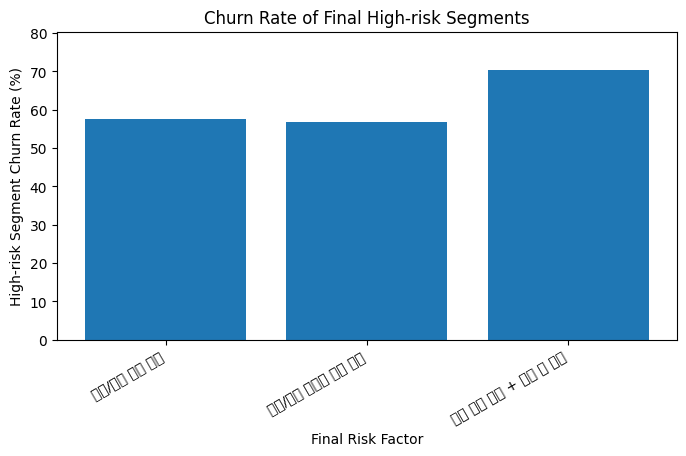

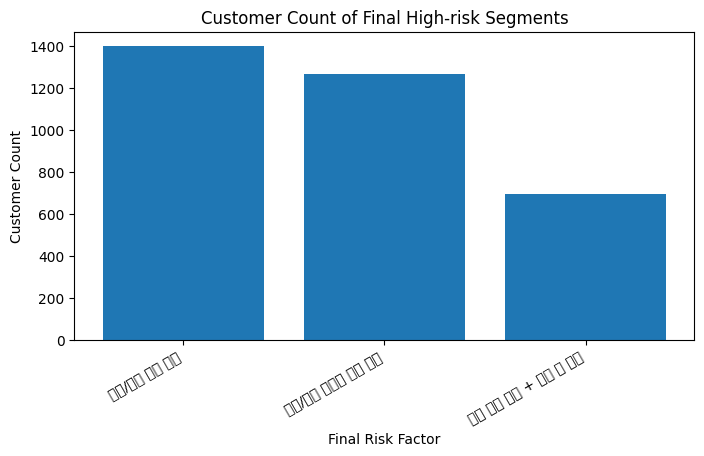

In [39]:
# =========================
# 1-13. 최종 핵심 이탈 위험 요인 3가지 선정
# =========================

target = "Churn Value"

# -------------------------------------------------
# 1. 최종 핵심 위험 요인 3가지 선정
# -------------------------------------------------

final_core_risk_factors = [
    "Contract_Payment_Risk_Level",
    "Support_Service_Level",
    "Low_Tenure_High_Charge"
]

# 보조 해석 변수
supporting_risk_factors = [
    "Tenure_Group",
    "Monthly_Charge_Group",
    "Income_Charge_Burden_Group",
    "Internet_User_No_Support"
]


# -------------------------------------------------
# 2. 이탈률 계산 함수
# -------------------------------------------------

def final_core_churn_table(data, col, target="Churn Value"):
    table = data.groupby(col, dropna=False, observed=False).agg(
        customer_count=(target, "count"),
        churn_count=(target, "sum"),
        churn_rate=(target, "mean")
    ).reset_index()

    table["churn_rate(%)"] = (table["churn_rate"] * 100).round(2)
    table = table.drop(columns="churn_rate")
    table = table.sort_values("churn_rate(%)", ascending=False)

    return table


# -------------------------------------------------
# 3. 최종 핵심 위험 요인 상세 이탈률
# -------------------------------------------------

final_core_detail_list = []

for col in final_core_risk_factors:
    temp = final_core_churn_table(df_fe, col, target)
    temp["risk_factor"] = col
    temp = temp.rename(columns={col: "segment"})
    temp = temp[["risk_factor", "segment", "customer_count", "churn_count", "churn_rate(%)"]]
    final_core_detail_list.append(temp)

final_core_detail = pd.concat(final_core_detail_list, axis=0).reset_index(drop=True)

print("최종 핵심 위험 요인 3가지 상세 이탈률:")
display(final_core_detail)


# -------------------------------------------------
# 4. 최종 핵심 위험 요인 요약표
# -------------------------------------------------

final_core_summary = pd.DataFrame({
    "final_risk_factor": [
        "계약/결제 위험 누적",
        "보안/지원 서비스 이용 부족",
        "짧은 가입 기간 + 높은 월 요금"
    ],
    "main_feature": [
        "Contract_Payment_Risk_Level",
        "Support_Service_Level",
        "Low_Tenure_High_Charge"
    ],
    "source_features": [
        "Contract, Payment Method, Paperless Billing",
        "Online Security, Online Backup, Device Protection, Tech Support, Internet Service",
        "Tenure Months, Monthly Charges"
    ],
    "high_risk_segment": [
        "3_very_high",
        "0_services",
        "1"
    ],
    "high_risk_meaning": [
        "월 단위 계약 + Electronic check + Paperless Billing 사용",
        "인터넷 이용 고객 중 보안/지원 서비스 0개 사용",
        "가입 기간 9개월 이하이면서 월 요금 70.35 초과"
    ],
    "why_selected": [
        "위험 점수가 높아질수록 이탈률이 단계적으로 증가하고, gap이 가장 큼",
        "보안/지원 서비스 이용 개수가 적을수록 이탈률이 뚜렷하게 증가함",
        "짧은 가입 기간과 높은 요금이 결합될 때 가장 높은 고위험군 이탈률을 보임"
    ]
})

# 실제 이탈률 값 추가
summary_rows = []

for _, row in final_core_summary.iterrows():
    feature = row["main_feature"]
    high_segment = row["high_risk_segment"]

    detail = final_core_churn_table(df_fe, feature, target)

    # segment 자료형 차이 보정
    high_row = detail[detail[feature].astype(str) == str(high_segment)].iloc[0]

    summary_rows.append({
        "high_risk_customer_count": high_row["customer_count"],
        "high_risk_churn_count": high_row["churn_count"],
        "high_risk_churn_rate(%)": high_row["churn_rate(%)"]
    })

summary_values = pd.DataFrame(summary_rows)

final_core_summary = pd.concat(
    [final_core_summary, summary_values],
    axis=1
)

print("\n최종 핵심 위험 요인 3가지 요약:")
display(final_core_summary)


# -------------------------------------------------
# 5. 보조 해석 변수 요약
# -------------------------------------------------

supporting_summary_list = []

for col in supporting_risk_factors:
    temp = final_core_churn_table(df_fe, col, target)

    max_rate = temp["churn_rate(%)"].max()
    min_rate = temp["churn_rate(%)"].min()
    gap = max_rate - min_rate

    high_segment = temp.loc[temp["churn_rate(%)"].idxmax(), col]
    low_segment = temp.loc[temp["churn_rate(%)"].idxmin(), col]

    supporting_summary_list.append({
        "supporting_factor": col,
        "high_risk_segment": high_segment,
        "high_risk_churn_rate(%)": max_rate,
        "low_risk_segment": low_segment,
        "low_risk_churn_rate(%)": min_rate,
        "gap(%p)": round(gap, 2)
    })

supporting_factor_summary = pd.DataFrame(supporting_summary_list).sort_values(
    "gap(%p)",
    ascending=False
)

print("\n보조 해석 변수 요약:")
display(supporting_factor_summary)


# -------------------------------------------------
# 6. 최종 핵심 위험 요인 고위험군 이탈률 그래프
# -------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(
    final_core_summary["final_risk_factor"],
    final_core_summary["high_risk_churn_rate(%)"]
)
plt.title("Churn Rate of Final High-risk Segments")
plt.xlabel("Final Risk Factor")
plt.ylabel("High-risk Segment Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(final_core_summary["high_risk_churn_rate(%)"]) + 10)
plt.show()


# -------------------------------------------------
# 7. 최종 핵심 위험 요인별 고객 수 그래프
# -------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(
    final_core_summary["final_risk_factor"],
    final_core_summary["high_risk_customer_count"]
)
plt.title("Customer Count of Final High-risk Segments")
plt.xlabel("Final Risk Factor")
plt.ylabel("Customer Count")
plt.xticks(rotation=30, ha="right")
plt.show()

| 최종 위험 요인           | 고위험군 정의                                        | 고위험 고객 수 | 이탈 고객 수 |    이탈률 |
| ------------------ | ---------------------------------------------- | -------: | ------: | -----: |
| 계약/결제 위험 누적        | 월 단위 계약 + Electronic check + Paperless Billing |    1397명 |    806명 | 57.70% |
| 보안/지원 서비스 이용 부족    | 인터넷 이용 고객 중 보안/지원 서비스 0개 사용                    |    1267명 |    718명 | 56.67% |
| 짧은 가입 기간 + 높은 월 요금 | 가입 기간 9개월 이하 + 월 요금 70.35 초과                   |     692명 |    487명 | 70.38% |


Low_Tenure_High_Charge는 이탈률이 **70.38%**로 가장 높아서 “가장 위험한 집단”입니다. 다만 고객 수는 692명으로 상대적으로 작습니다. 반면 Contract_Payment_Risk_Level과 Support_Service_Level은 이탈률도 높고 고객 수도 1200명 이상이라서, 실제 리텐션 전략에서는 더 넓은 고객군을 커버할 수 있습니다.

> EDA 결과를 종합하여 최종 핵심 이탈 위험 요인 3가지를 선정하였다. 첫째, `Contract_Payment_Risk_Level`은 월 단위 계약, Electronic check 결제, Paperless Billing 사용 여부를 결합한 변수로, 최고 위험군의 이탈률은 57.70%로 나타났다. 둘째, `Support_Service_Level`은 인터넷 이용 고객의 보안/지원 서비스 이용 수준을 나타내며, 보안/지원 서비스를 하나도 사용하지 않는 고객의 이탈률은 56.67%였다. 셋째, `Low_Tenure_High_Charge`는 가입 기간이 9개월 이하이면서 월 요금이 높은 고객을 나타내며, 해당 고객군의 이탈률은 70.38%로 가장 높게 나타났다.
>
> 따라서 최종적으로 계약/결제 위험 누적, 보안/지원 서비스 이용 부족, 짧은 가입 기간과 높은 월 요금의 결합을 주요 이탈 위험 요인으로 선정하였다. 이후 모델링 단계에서는 이 변수들이 실제 예측 성능 향상에도 기여하는지 검증한다.
---

#2.데이터 전처리(4단계후보군 나누기)

##2-1. 모델링용 데이터셋 구성(데이터전처리)

이제 EDA가 끝났으니 모델링으로 넘어갑니다.
모델링에서는 방금 나눈 4단계 후보군을 그대로 사용해서 비교하면 좋습니다.

이번 단계에서는 모델에 넣을 feature set 4개를 만들고, train/test split까지 진행합니다.

In [40]:
# =========================
# 2-1. 모델링용 데이터셋 구성
# =========================

from sklearn.model_selection import train_test_split

target = "Churn Value"

# -------------------------------------------------
# 1. 모델링에서 제외할 누수/식별자 변수
# -------------------------------------------------

exclude_cols = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "Lat Long",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "Churn Reason"
]

# 지역 위치 변수는 고유값이 많고 해석이 어려워 우선 모델에서 제외
location_cols = [
    "City",
    "Zip Code",
    "Latitude",
    "Longitude"
]


# -------------------------------------------------
# 2. 원본 변수 후보 정의
# -------------------------------------------------

original_features_without_income_charge_ratio = [
    "Gender",
    "Senior Citizen",
    "Partner",
    "Dependents",
    "Tenure Months",
    "Phone Service",
    "Multiple Lines",
    "Internet Service",
    "Online Security",
    "Online Backup",
    "Device Protection",
    "Tech Support",
    "Streaming TV",
    "Streaming Movies",
    "Contract",
    "Paperless Billing",
    "Payment Method",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Area_Total_Households",
    "Area_Median_Income",
    "Area_Mean_Income",
    "Area_Income_Level"
]

# Zip Code 기반 소득 대비 요금 부담 변수 포함
original_features_with_income_charge_ratio = original_features_without_income_charge_ratio + [
    "Income_Charge_Ratio"
]


# -------------------------------------------------
# 3. 파생변수 후보 정의
# -------------------------------------------------

derived_features_without_income_charge_ratio = original_features_without_income_charge_ratio + [
    "Is_Internet_User",
    "Support_Service_Count",
    "Support_Service_Level",
    "Internet_User_No_Support",
    "Contract_Payment_Risk_Score",
    "Contract_Payment_Risk_Level",
    "Tenure_Group",
    "Monthly_Charge_Group",
    "Low_Tenure_High_Charge"
]

# Income_Charge_Ratio와 그 파생변수까지 포함
derived_features_with_income_charge_ratio = derived_features_without_income_charge_ratio + [
    "Income_Charge_Ratio",
    "Income_Charge_Burden_Group"
]


# -------------------------------------------------
# 4. 4단계 feature set 구성
# -------------------------------------------------

feature_sets = {
    "1_original_without_income_charge_ratio": original_features_without_income_charge_ratio,
    "2_original_with_income_charge_ratio": original_features_with_income_charge_ratio,
    "3_derived_without_income_charge_ratio": derived_features_without_income_charge_ratio,
    "4_derived_with_income_charge_ratio": derived_features_with_income_charge_ratio
}

# feature set별 컬럼 수 확인
feature_set_summary = pd.DataFrame({
    "feature_set": list(feature_sets.keys()),
    "feature_count": [len(v) for v in feature_sets.values()]
})

print("모델링 feature set 요약:")
display(feature_set_summary)


# -------------------------------------------------
# 5. 모델링용 데이터 준비
# -------------------------------------------------

# df_fe 기준으로 진행
model_df = df_fe.copy()

# Total Charges 결측치는 중앙값으로 대체
model_df["Total Charges"] = model_df["Total Charges"].fillna(model_df["Total Charges"].median())

# 타깃 분리
y = model_df[target]

print("타깃 분포:")
display(y.value_counts().rename(index={0: "Non-Churn", 1: "Churn"}))

print("\n타깃 비율:")
display((y.value_counts(normalize=True) * 100).round(2).rename(index={0: "Non-Churn", 1: "Churn"}))


# -------------------------------------------------
# 6. Train/Test Split
# -------------------------------------------------

train_test_data = {}

for set_name, features in feature_sets.items():
    X = model_df[features].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    train_test_data[set_name] = {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

print("\nFeature set별 Train/Test shape:")
shape_summary = []

for set_name, data in train_test_data.items():
    shape_summary.append({
        "feature_set": set_name,
        "X_train_shape": data["X_train"].shape,
        "X_test_shape": data["X_test"].shape,
        "y_train_shape": data["y_train"].shape,
        "y_test_shape": data["y_test"].shape
    })

shape_summary = pd.DataFrame(shape_summary)
display(shape_summary)


# -------------------------------------------------
# 7. 각 feature set의 범주형/수치형 변수 확인
# -------------------------------------------------

feature_type_summary = []

for set_name, features in feature_sets.items():
    cat_cols = model_df[features].select_dtypes(include=["object", "category"]).columns.tolist()
    num_cols = model_df[features].select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    feature_type_summary.append({
        "feature_set": set_name,
        "categorical_count": len(cat_cols),
        "numeric_count": len(num_cols),
        "categorical_features": cat_cols,
        "numeric_features": num_cols
    })

feature_type_summary = pd.DataFrame(feature_type_summary)

print("\nFeature set별 범주형/수치형 변수 요약:")
display(feature_type_summary)

모델링 feature set 요약:


,feature_set,feature_count
0,1_original_without_income_charge_ratio,24
1,2_original_with_income_charge_ratio,25
2,3_derived_without_income_charge_ratio,33
3,4_derived_with_income_charge_ratio,35


타깃 분포:


,count
Churn Value,
Non-Churn,5174
Churn,1869



타깃 비율:


,proportion
Churn Value,
Non-Churn,73.46
Churn,26.54



Feature set별 Train/Test shape:


,feature_set,X_train_shape,X_test_shape,y_train_shape,y_test_shape
0,1_original_without_income_charge_ratio,"(5634, 24)","(1409, 24)","(5634,)","(1409,)"
1,2_original_with_income_charge_ratio,"(5634, 25)","(1409, 25)","(5634,)","(1409,)"
2,3_derived_without_income_charge_ratio,"(5634, 33)","(1409, 33)","(5634,)","(1409,)"
3,4_derived_with_income_charge_ratio,"(5634, 35)","(1409, 35)","(5634,)","(1409,)"



Feature set별 범주형/수치형 변수 요약:


,feature_set,categorical_count,numeric_count,categorical_features,numeric_features
0,1_original_without_income_charge_ratio,17,7,"[Gender, Senior Citizen, Partner, Dependents, ...","[Tenure Months, Monthly Charges, Total Charges..."
1,2_original_with_income_charge_ratio,17,8,"[Gender, Senior Citizen, Partner, Dependents, ...","[Tenure Months, Monthly Charges, Total Charges..."
2,3_derived_without_income_charge_ratio,21,12,"[Gender, Senior Citizen, Partner, Dependents, ...","[Tenure Months, Monthly Charges, Total Charges..."
3,4_derived_with_income_charge_ratio,22,13,"[Gender, Senior Citizen, Partner, Dependents, ...","[Tenure Months, Monthly Charges, Total Charges..."


> 모델링을 위해 EDA에서 구성한 후보군을 4개의 feature set으로 나누었다. 1단계는 원본 변수만 사용하고 `Income_Charge_Ratio`를 제외한 경우, 2단계는 원본 변수에 `Income_Charge_Ratio`를 추가한 경우, 3단계는 파생변수를 추가하되 `Income_Charge_Ratio`를 제외한 경우, 4단계는 파생변수와 `Income_Charge_Ratio`를 모두 포함한 경우이다. 전체 데이터는 학습 데이터 5634개, 테스트 데이터 1409개로 분할하였으며, 이탈 고객 비율이 26.54%로 클래스 불균형이 존재하므로 이후 모델 평가는 Accuracy보다 Recall, F1-score, ROC-AUC를 중심으로 비교한다.
---

#3. Logistic Regression Baseline 모델 학습

이번 단계에서는 첫 번째 모델로 Logistic Regression을 학습합니다.

Logistic Regression은 복잡한 모델은 아니지만,
각 변수가 이탈 확률을 증가시키는지 감소시키는지 해석하기 쉬워서 baseline 모델로 적합합니다.


[1_original_without_income_charge_ratio] Logistic Regression 학습
범주형 변수 수: 17
수치형 변수 수: 7

평가 결과:
Accuracy : 0.7452
Precision: 0.5132
Recall   : 0.7807
F1-score : 0.6193
ROC-AUC  : 0.8480
PR-AUC   : 0.6372

Confusion Matrix
[[758 277]
 [ 82 292]]

Classification Report
              precision    recall  f1-score   support

   Non-Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409


[2_original_with_income_charge_ratio] Logistic Regression 학습
범주형 변수 수: 17
수치형 변수 수: 8

평가 결과:
Accuracy : 0.7438
Precision: 0.5115
Recall   : 0.7754
F1-score : 0.6164
ROC-AUC  : 0.8481
PR-AUC   : 0.6366

Confusion Matrix
[[758 277]
 [ 84 290]]

Classification Report
              precision    recall  f1-score   support

   Non-Churn       0.90      0.73      0.81      1035
       Churn       0.51    

,feature_set,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,1_original_without_income_charge_ratio,0.7452,0.5132,0.7807,0.6193,0.8480,0.6372
1,3_derived_without_income_charge_ratio,0.7495,0.5187,0.7781,0.6225,0.8495,0.6364
2,2_original_with_income_charge_ratio,0.7438,0.5115,0.7754,0.6164,0.8481,0.6366
3,4_derived_with_income_charge_ratio,0.7466,0.5151,0.7754,0.6190,0.8500,0.6354



Logistic Regression Confusion Matrix 요약:


,feature_set,TN,FP,FN,TP
0,1_original_without_income_charge_ratio,758,277,82,292
1,2_original_with_income_charge_ratio,758,277,84,290
2,3_derived_without_income_charge_ratio,765,270,83,291
3,4_derived_with_income_charge_ratio,762,273,84,290


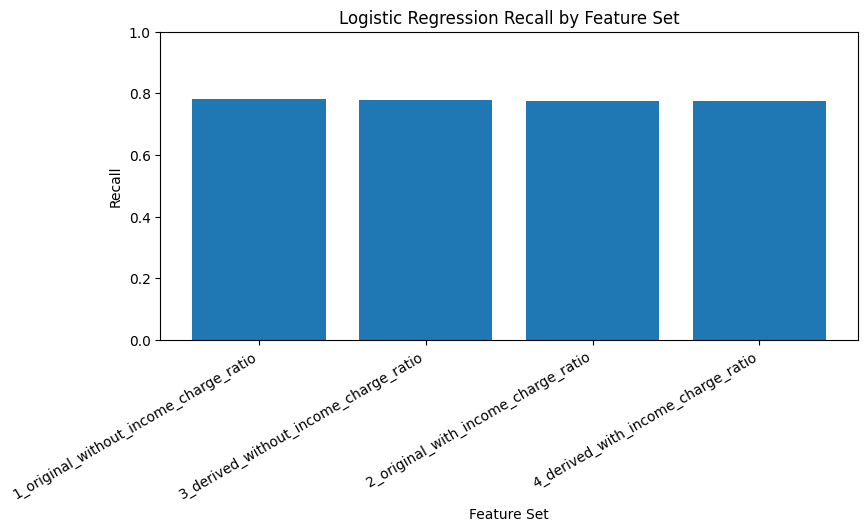

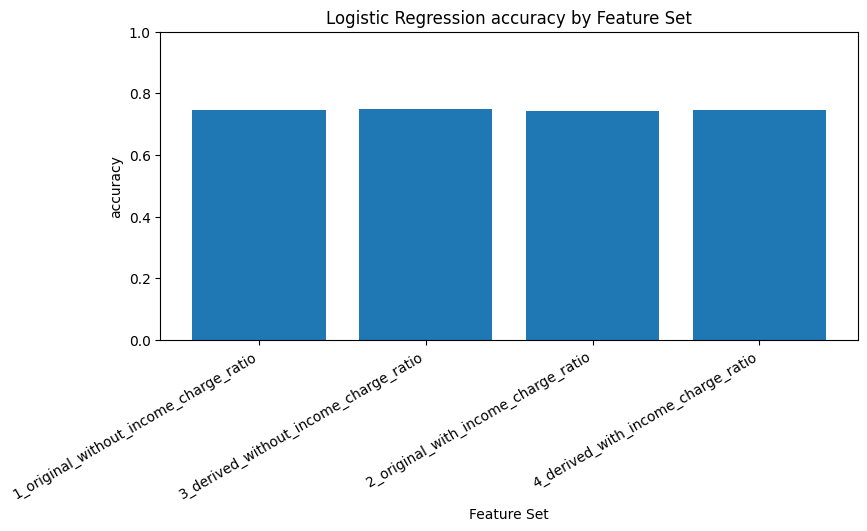

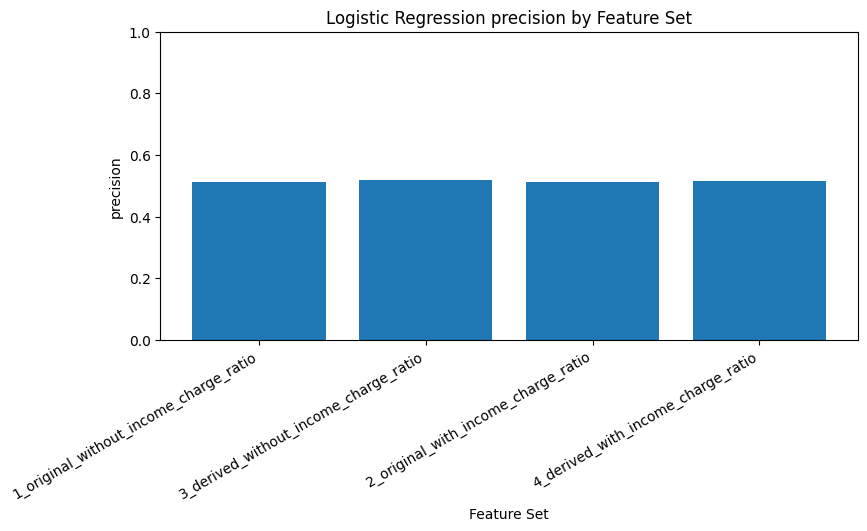

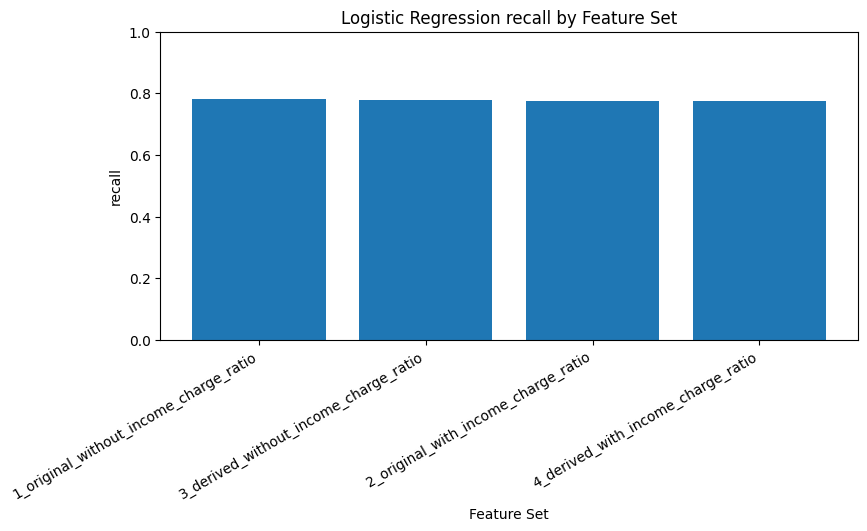

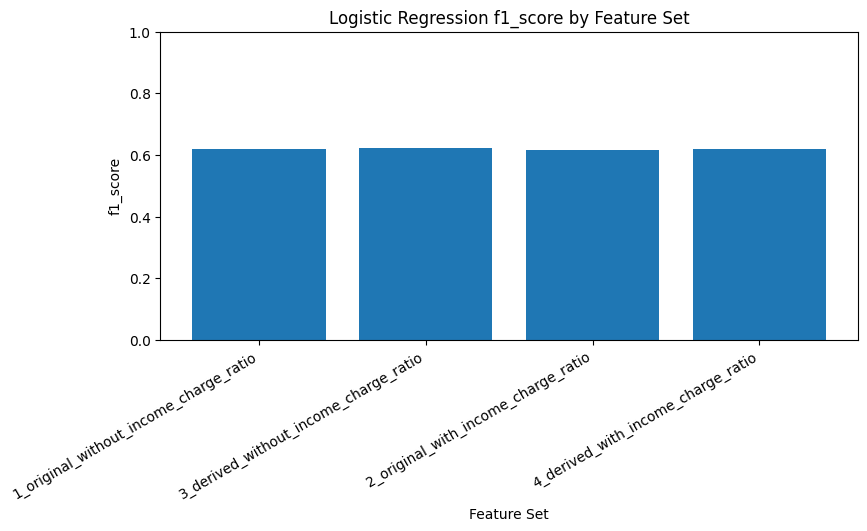

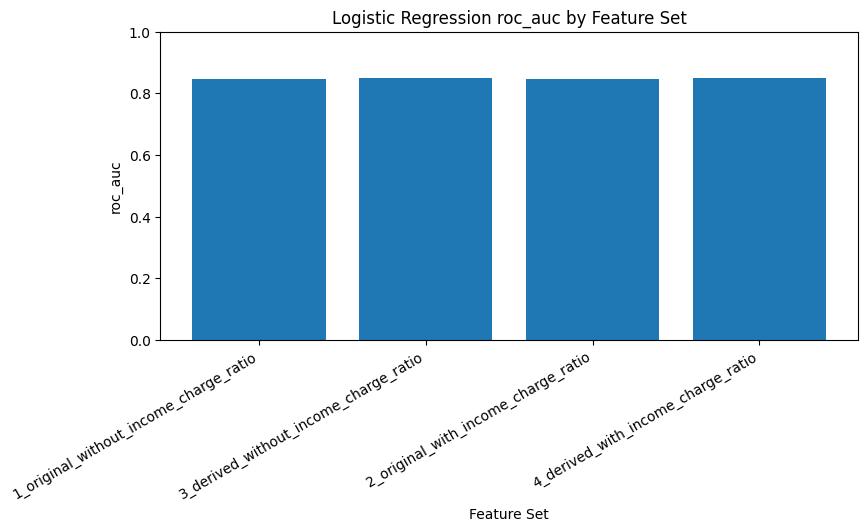

In [41]:
# =========================
# 2-2. Logistic Regression Baseline 모델 학습
# =========================

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# -------------------------------------------------
# 1. 결과 저장용 객체
# -------------------------------------------------

logistic_models = {}
logistic_result_list = []
logistic_confusion_list = []


# -------------------------------------------------
# 2. Feature set별 Logistic Regression 학습
# -------------------------------------------------

for set_name, data in train_test_data.items():

    print("\n" + "=" * 90)
    print(f"[{set_name}] Logistic Regression 학습")

    X_train = data["X_train"].copy()
    X_test = data["X_test"].copy()
    y_train = data["y_train"].copy()
    y_test = data["y_test"].copy()

    # 범주형 / 수치형 변수 분리
    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    print(f"범주형 변수 수: {len(categorical_cols)}")
    print(f"수치형 변수 수: {len(numeric_cols)}")

    # 수치형 전처리: 결측치 중앙값 대체 + 표준화
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    # 범주형 전처리: 결측치 최빈값 대체 + One-Hot Encoding
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    # 전체 전처리
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    # Logistic Regression 모델
    # class_weight="balanced"는 이탈 고객 비율이 낮은 문제를 보정하기 위한 설정
    logit_model = LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        solver="liblinear",
        random_state=42
    )

    # 전처리 + 모델 파이프라인
    model_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", logit_model)
    ])

    # 학습
    model_pipeline.fit(X_train, y_train)

    # 예측
    y_pred = model_pipeline.predict(X_test)
    y_pred_proba = model_pipeline.predict_proba(X_test)[:, 1]

    # 평가 지표 계산
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    logistic_result_list.append({
        "feature_set": set_name,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "roc_auc": round(roc_auc, 4),
        "pr_auc": round(pr_auc, 4)
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)

    tn, fp, fn, tp = cm.ravel()

    logistic_confusion_list.append({
        "feature_set": set_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    # 모델 저장
    logistic_models[set_name] = model_pipeline

    print("\n평가 결과:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred, target_names=["Non-Churn", "Churn"]))


# -------------------------------------------------
# 3. 전체 feature set 성능 비교표
# -------------------------------------------------

logistic_result_summary = pd.DataFrame(logistic_result_list)
logistic_result_summary = logistic_result_summary.sort_values(
    "recall",
    ascending=False
).reset_index(drop=True)

print("\nLogistic Regression 성능 비교:")
display(logistic_result_summary)


# -------------------------------------------------
# 4. Confusion Matrix 요약표
# -------------------------------------------------

logistic_confusion_summary = pd.DataFrame(logistic_confusion_list)

print("\nLogistic Regression Confusion Matrix 요약:")
display(logistic_confusion_summary)


# -------------------------------------------------
# 5. Recall 중심 성능 비교 그래프
# -------------------------------------------------

plt.figure(figsize=(9, 4))
plt.bar(logistic_result_summary["feature_set"], logistic_result_summary["recall"])
plt.title("Logistic Regression Recall by Feature Set")
plt.xlabel("Feature Set")
plt.ylabel("Recall")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()


# -------------------------------------------------
# 6. 주요 지표 비교 그래프
# -------------------------------------------------

metric_cols = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

for metric in metric_cols:
    plt.figure(figsize=(9, 4))
    plt.bar(logistic_result_summary["feature_set"], logistic_result_summary[metric])
    plt.title(f"Logistic Regression {metric} by Feature Set")
    plt.xlabel("Feature Set")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.show()

> Logistic Regression Baseline 모델을 4개의 feature set에 대해 학습한 결과, 전체적으로 Recall은 약 0.775 ~ 0.781, ROC-AUC는 약 0.848 ~ 0.850 수준으로 나타났다. 가장 높은 Recall은 원본 변수만 사용하고 `Income_Charge_Ratio`를 제외한 feature set에서 0.7807로 나타났으며, 파생변수를 포함한 feature set은 Accuracy와 F1-score가 소폭 개선되었다.
>
> 그러나 feature set 간 성능 차이는 크지 않았고, `Income_Charge_Ratio` 추가 역시 Logistic Regression 성능을 뚜렷하게 개선하지는 않았다. 이는 Logistic Regression이 선형 모델이기 때문에 여러 조건이 결합된 고위험 패턴을 충분히 반영하기 어렵기 때문으로 해석할 수 있다. 따라서 다음 단계에서는 Decision Tree를 이용해 고객 이탈 위험을 설명할 수 있는 규칙 기반 세그먼트를 정의한다.
---

#4. Decision Tree 기반 세그먼테이션

##4-1. Decision Tree 기반 세그먼테이션

이번 단계의 목적은 단순히 성능 좋은 모델을 만드는 것이 아니라,
어떤 조건 조합을 가진 고객이 고위험군인지 규칙으로 정의하는 것입니다.

그래서 모든 원본 변수를 다 넣기보다, EDA에서 확인한 핵심 위험 구조를 반영하는 변수들을 사용합니다.

> Decision Tree 기반 세그먼테이션에서는 앞서 정의한 4번 후보군, 즉 파생변수와 `Income_Charge_Ratio`를 모두 포함한 확장 데이터에서 해석 가능한 핵심 변수 10개를 선택하여 사용하였다. 전체 변수를 모두 사용하면 Tree 구조가 복잡해져 세그먼트 해석이 어려워지므로, EDA에서 주요 위험 요인으로 확인된 가입 기간, 월 요금, 계약/결제 위험 점수, 보안/지원 서비스 이용 수준, 소득 대비 요금 부담 변수를 중심으로 세그먼테이션을 수행하였다.

>방금 Decision Tree에 사용한 변수

tree_segmentation_features = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",
    "Income_Charge_Ratio",
    "Is_Internet_User",
    "Support_Service_Count",
    "Internet_User_No_Support",
    "Contract_Payment_Risk_Score",
    "Low_Tenure_High_Charge"
]
>이 변수들은 다음처럼 나뉩니다.
| 변수 종류          | 포함 변수                                                                                                                            |
| -------------- | -------------------------------------------------------------------------------------------------------------------------------- |
| 원본 변수          | `Tenure Months`, `Monthly Charges`, `Total Charges`, `CLTV`                                                                      |
| Zip Code 기반 변수 | `Income_Charge_Ratio`                                                                                                            |
| 파생변수           | `Is_Internet_User`, `Support_Service_Count`, `Internet_User_No_Support`, `Contract_Payment_Risk_Score`, `Low_Tenure_High_Charge` |


Decision Tree 세그먼테이션용 변수:


,feature,meaning
0,Tenure Months,가입 기간
1,Monthly Charges,월 요금
2,Total Charges,누적 요금
3,CLTV,고객 생애 가치
4,Income_Charge_Ratio,지역 소득 대비 요금 부담
5,Is_Internet_User,인터넷 서비스 이용 여부
6,Support_Service_Count,보안/지원 서비스 이용 개수
7,Internet_User_No_Support,인터넷 이용 고객 중 보안/지원 서비스 0개 사용 여부
8,Contract_Payment_Risk_Score,"월 단위 계약, Electronic check, Paperless Billing 위..."
9,Low_Tenure_High_Charge,가입 기간 9개월 이하이면서 월 요금 70.35 초과 여부


Train/Test shape:
X_train_tree: (5634, 10)
X_test_tree : (1409, 10)
y_train_tree: (5634,)
y_test_tree : (1409,)

Decision Tree 성능 요약:


,model,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Decision Tree Segmentation,0.7197,0.483,0.7995,0.6022,0.8066,0.5553



Classification Report:
              precision    recall  f1-score   support

   Non-Churn       0.91      0.69      0.78      1035
       Churn       0.48      0.80      0.60       374

    accuracy                           0.72      1409
   macro avg       0.69      0.75      0.69      1409
weighted avg       0.79      0.72      0.74      1409


Confusion Matrix 요약:


,model,TN,FP,FN,TP
0,Decision Tree Segmentation,715,320,75,299


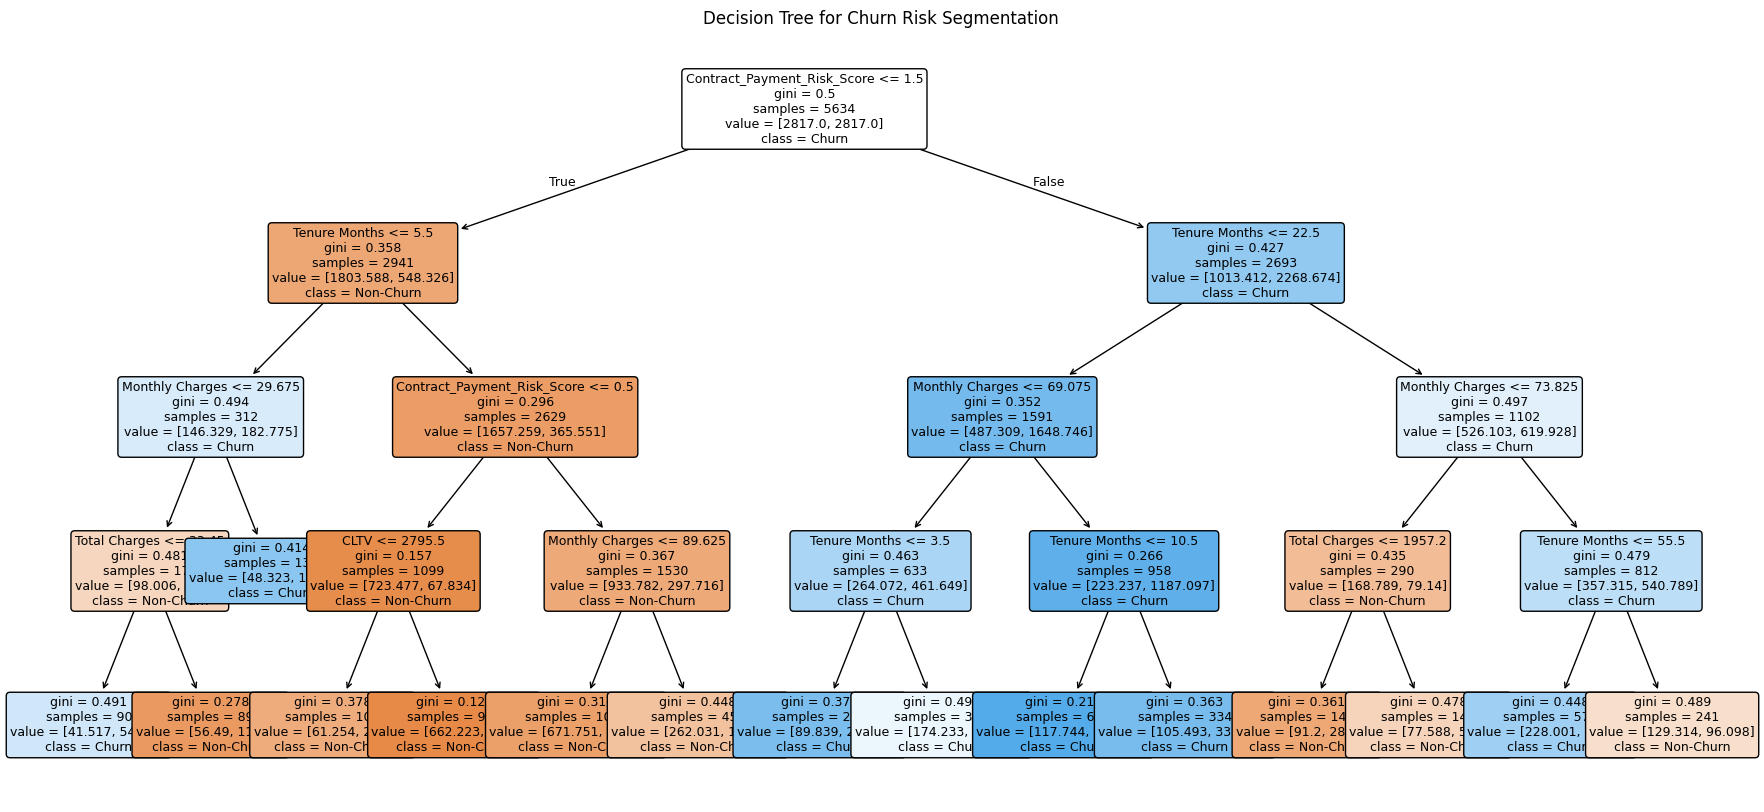


테스트 데이터 Leaf 세그먼트별 이탈률:


,leaf_id,customer_count,churn_count,avg_pred_proba,avg_tenure,avg_monthly_charge,avg_income_charge_ratio,avg_support_service_count,avg_contract_payment_risk_score,churn_rate(%)
0,20,163,108,0.878,4.12,80.96,0.0111,0.54,2.61,66.26
1,6,36,22,0.707,2.33,59.86,0.0082,0.67,0.94,61.11
2,17,75,43,0.750,1.57,38.50,0.0058,0.44,2.33,57.33
3,21,84,42,0.762,16.73,87.53,0.0134,1.04,2.40,50.00
4,27,135,53,0.661,37.07,92.61,0.0129,1.48,2.50,39.26
5,4,27,7,0.568,1.07,21.07,0.0028,0.04,0.85,25.93
6,18,99,24,0.525,11.54,45.30,0.0060,0.87,2.25,24.24
7,28,63,12,0.426,63.89,99.77,0.0132,2.19,2.16,19.05
8,25,39,7,0.396,47.05,59.90,0.0107,1.33,2.28,17.95
9,5,24,4,0.167,2.92,20.79,0.0029,0.00,0.75,16.67



전체 데이터 Leaf 세그먼트별 이탈률:


,leaf_id,customer_count,churn_count,avg_pred_proba,avg_tenure,avg_monthly_charge,avg_income_charge_ratio,avg_support_service_count,avg_contract_payment_risk_score,churn_rate(%)
0,20,787,559,0.878,4.20,81.71,0.0116,0.58,2.59,71.03
1,17,350,186,0.750,1.55,38.66,0.0056,0.38,2.29,53.14
2,21,418,221,0.762,16.03,86.99,0.0126,1.00,2.52,52.87
3,6,169,84,0.707,2.26,57.74,0.0078,0.87,0.96,49.70
4,27,706,289,0.661,37.35,92.86,0.0133,1.48,2.45,40.93
5,4,117,36,0.568,1.05,20.56,0.0028,0.01,0.92,30.77
6,18,457,126,0.525,11.29,43.97,0.0061,0.80,2.31,27.57
7,28,304,63,0.426,64.02,99.17,0.0138,2.20,2.23,20.72
8,25,180,34,0.396,49.09,58.64,0.0084,1.64,2.22,18.89
9,13,561,86,0.338,57.28,102.78,0.0147,2.60,1.00,15.33



Leaf 세그먼트 규칙 + 테스트 데이터 이탈률:


,leaf_id,rule,tree_sample_count,customer_count,churn_count,avg_pred_proba,avg_tenure,avg_monthly_charge,avg_income_charge_ratio,avg_support_service_count,avg_contract_payment_risk_score,churn_rate(%)
0,20,Contract_Payment_Risk_Score > 1.500 AND Tenure...,624,163,108,0.878,4.12,80.96,0.0111,0.54,2.61,66.26
1,6,Contract_Payment_Risk_Score <= 1.500 AND Tenur...,133,36,22,0.707,2.33,59.86,0.0082,0.67,0.94,61.11
2,17,Contract_Payment_Risk_Score > 1.500 AND Tenure...,275,75,43,0.750,1.57,38.50,0.0058,0.44,2.33,57.33
3,21,Contract_Payment_Risk_Score > 1.500 AND Tenure...,334,84,42,0.762,16.73,87.53,0.0134,1.04,2.40,50.00
4,27,Contract_Payment_Risk_Score > 1.500 AND Tenure...,571,135,53,0.661,37.07,92.61,0.0129,1.48,2.50,39.26
5,4,Contract_Payment_Risk_Score <= 1.500 AND Tenur...,90,27,7,0.568,1.07,21.07,0.0028,0.04,0.85,25.93
6,18,Contract_Payment_Risk_Score > 1.500 AND Tenure...,358,99,24,0.525,11.54,45.30,0.0060,0.87,2.25,24.24
7,28,Contract_Payment_Risk_Score > 1.500 AND Tenure...,241,63,12,0.426,63.89,99.77,0.0132,2.19,2.16,19.05
8,25,Contract_Payment_Risk_Score > 1.500 AND Tenure...,141,39,7,0.396,47.05,59.90,0.0107,1.33,2.28,17.95
9,5,Contract_Payment_Risk_Score <= 1.500 AND Tenur...,89,24,4,0.167,2.92,20.79,0.0029,0.00,0.75,16.67



Decision Tree 기반 고위험 세그먼트 후보:


,leaf_id,rule,tree_sample_count,customer_count,churn_count,avg_pred_proba,avg_tenure,avg_monthly_charge,avg_income_charge_ratio,avg_support_service_count,avg_contract_payment_risk_score,churn_rate(%)
0,20,Contract_Payment_Risk_Score > 1.500 AND Tenure...,624,163,108,0.878,4.12,80.96,0.0111,0.54,2.61,66.26
1,6,Contract_Payment_Risk_Score <= 1.500 AND Tenur...,133,36,22,0.707,2.33,59.86,0.0082,0.67,0.94,61.11
2,17,Contract_Payment_Risk_Score > 1.500 AND Tenure...,275,75,43,0.750,1.57,38.50,0.0058,0.44,2.33,57.33
3,21,Contract_Payment_Risk_Score > 1.500 AND Tenure...,334,84,42,0.762,16.73,87.53,0.0134,1.04,2.40,50.00


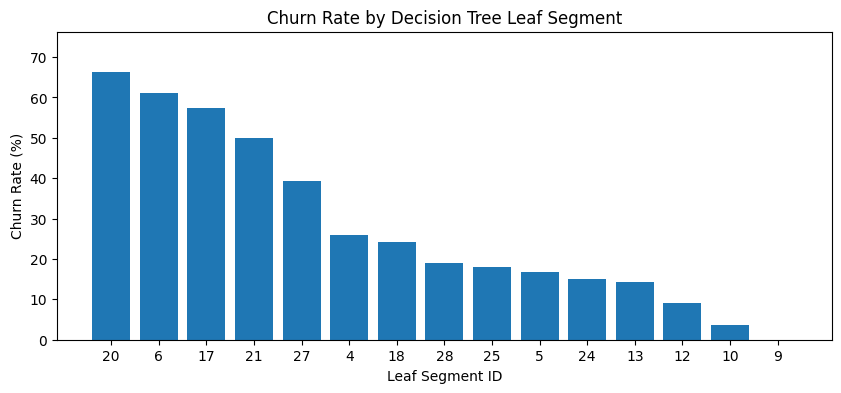

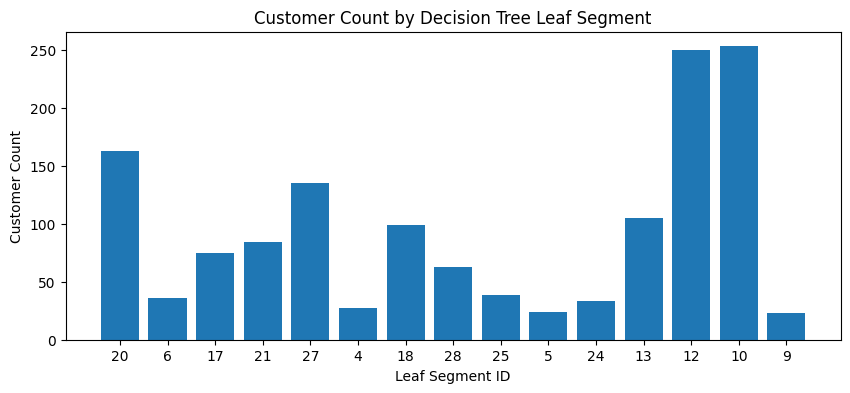

In [43]:
# =========================
# 4-1. Decision Tree 기반 세그먼테이션
# =========================

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.tree import _tree

target = "Churn Value"

# -------------------------------------------------
# 1. Decision Tree 세그먼테이션용 변수 선택
# -------------------------------------------------
# 목적:
# - 성능보다 해석 가능성이 중요
# - EDA에서 발견한 고위험 구조를 반영
# - Tree 규칙이 너무 복잡해지지 않도록 핵심 변수 중심으로 구성

tree_segmentation_features = [
    # 가입 기간 / 요금
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "CLTV",

    # Zip Code 기반 소득 대비 요금 부담
    "Income_Charge_Ratio",

    # 인터넷 및 보안/지원 서비스 관련 파생변수
    "Is_Internet_User",
    "Support_Service_Count",
    "Internet_User_No_Support",

    # 계약/결제 위험 누적 파생변수
    "Contract_Payment_Risk_Score",

    # 짧은 가입 기간 + 높은 월 요금
    "Low_Tenure_High_Charge"
]

tree_feature_description = pd.DataFrame({
    "feature": tree_segmentation_features,
    "meaning": [
        "가입 기간",
        "월 요금",
        "누적 요금",
        "고객 생애 가치",
        "지역 소득 대비 요금 부담",
        "인터넷 서비스 이용 여부",
        "보안/지원 서비스 이용 개수",
        "인터넷 이용 고객 중 보안/지원 서비스 0개 사용 여부",
        "월 단위 계약, Electronic check, Paperless Billing 위험 점수",
        "가입 기간 9개월 이하이면서 월 요금 70.35 초과 여부"
    ]
})

print("Decision Tree 세그먼테이션용 변수:")
display(tree_feature_description)


# -------------------------------------------------
# 2. 데이터 구성
# -------------------------------------------------

X_tree = model_df[tree_segmentation_features].copy()
y_tree = model_df[target].copy()

X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X_tree,
    y_tree,
    test_size=0.2,
    random_state=42,
    stratify=y_tree
)

print("Train/Test shape:")
print("X_train_tree:", X_train_tree.shape)
print("X_test_tree :", X_test_tree.shape)
print("y_train_tree:", y_train_tree.shape)
print("y_test_tree :", y_test_tree.shape)


# -------------------------------------------------
# 3. Decision Tree 모델 학습
# -------------------------------------------------
# max_depth를 낮게 설정해야 사람이 해석 가능한 규칙이 나온다.
# min_samples_leaf는 너무 작은 세그먼트가 생기지 않도록 제한한다.

dt_segment_model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", DecisionTreeClassifier(
        max_depth=4,
        min_samples_leaf=80,
        class_weight="balanced",
        random_state=42
    ))
])

dt_segment_model.fit(X_train_tree, y_train_tree)


# -------------------------------------------------
# 4. 테스트 데이터 성능 평가
# -------------------------------------------------

y_pred_tree = dt_segment_model.predict(X_test_tree)
y_pred_proba_tree = dt_segment_model.predict_proba(X_test_tree)[:, 1]

dt_accuracy = accuracy_score(y_test_tree, y_pred_tree)
dt_precision = precision_score(y_test_tree, y_pred_tree)
dt_recall = recall_score(y_test_tree, y_pred_tree)
dt_f1 = f1_score(y_test_tree, y_pred_tree)
dt_roc_auc = roc_auc_score(y_test_tree, y_pred_proba_tree)
dt_pr_auc = average_precision_score(y_test_tree, y_pred_proba_tree)

dt_segment_result_summary = pd.DataFrame([{
    "model": "Decision Tree Segmentation",
    "accuracy": round(dt_accuracy, 4),
    "precision": round(dt_precision, 4),
    "recall": round(dt_recall, 4),
    "f1_score": round(dt_f1, 4),
    "roc_auc": round(dt_roc_auc, 4),
    "pr_auc": round(dt_pr_auc, 4)
}])

print("\nDecision Tree 성능 요약:")
display(dt_segment_result_summary)

print("\nClassification Report:")
print(classification_report(y_test_tree, y_pred_tree, target_names=["Non-Churn", "Churn"]))

cm = confusion_matrix(y_test_tree, y_pred_tree)
tn, fp, fn, tp = cm.ravel()

dt_segment_confusion_summary = pd.DataFrame([{
    "model": "Decision Tree Segmentation",
    "TN": tn,
    "FP": fp,
    "FN": fn,
    "TP": tp
}])

print("\nConfusion Matrix 요약:")
display(dt_segment_confusion_summary)


# -------------------------------------------------
# 5. Decision Tree 시각화
# -------------------------------------------------

tree_model_only = dt_segment_model.named_steps["model"]

plt.figure(figsize=(22, 10))
plot_tree(
    tree_model_only,
    feature_names=tree_segmentation_features,
    class_names=["Non-Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9
)
plt.title("Decision Tree for Churn Risk Segmentation")
plt.show()


# -------------------------------------------------
# 6. Leaf node별 세그먼트 이탈률 계산
# -------------------------------------------------
# Tree에서 같은 leaf node에 도착한 고객들을 하나의 세그먼트로 본다.

X_test_imputed = dt_segment_model.named_steps["imputer"].transform(X_test_tree)
test_leaf_id = tree_model_only.apply(X_test_imputed)

dt_test_segment_df = X_test_tree.copy()
dt_test_segment_df[target] = y_test_tree.values
dt_test_segment_df["pred_proba"] = y_pred_proba_tree
dt_test_segment_df["leaf_id"] = test_leaf_id

dt_leaf_summary_test = dt_test_segment_df.groupby("leaf_id").agg(
    customer_count=(target, "count"),
    churn_count=(target, "sum"),
    churn_rate=(target, "mean"),
    avg_pred_proba=("pred_proba", "mean"),
    avg_tenure=("Tenure Months", "mean"),
    avg_monthly_charge=("Monthly Charges", "mean"),
    avg_income_charge_ratio=("Income_Charge_Ratio", "mean"),
    avg_support_service_count=("Support_Service_Count", "mean"),
    avg_contract_payment_risk_score=("Contract_Payment_Risk_Score", "mean")
).reset_index()

dt_leaf_summary_test["churn_rate(%)"] = (dt_leaf_summary_test["churn_rate"] * 100).round(2)
dt_leaf_summary_test["avg_pred_proba"] = dt_leaf_summary_test["avg_pred_proba"].round(3)
dt_leaf_summary_test["avg_tenure"] = dt_leaf_summary_test["avg_tenure"].round(2)
dt_leaf_summary_test["avg_monthly_charge"] = dt_leaf_summary_test["avg_monthly_charge"].round(2)
dt_leaf_summary_test["avg_income_charge_ratio"] = dt_leaf_summary_test["avg_income_charge_ratio"].round(4)
dt_leaf_summary_test["avg_support_service_count"] = dt_leaf_summary_test["avg_support_service_count"].round(2)
dt_leaf_summary_test["avg_contract_payment_risk_score"] = dt_leaf_summary_test["avg_contract_payment_risk_score"].round(2)

dt_leaf_summary_test = dt_leaf_summary_test.drop(columns="churn_rate")
dt_leaf_summary_test = dt_leaf_summary_test.sort_values(
    ["churn_rate(%)", "customer_count"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n테스트 데이터 Leaf 세그먼트별 이탈률:")
display(dt_leaf_summary_test)


# -------------------------------------------------
# 7. 전체 데이터 기준 Leaf node별 세그먼트 이탈률
# -------------------------------------------------
# 테스트 데이터는 성능 평가용이고,
# 전체 데이터는 실제 고객군 규모를 파악하기 위한 참고용이다.

X_full_tree = model_df[tree_segmentation_features].copy()
X_full_imputed = dt_segment_model.named_steps["imputer"].transform(X_full_tree)
full_leaf_id = tree_model_only.apply(X_full_imputed)
full_pred_proba = dt_segment_model.predict_proba(X_full_tree)[:, 1]

dt_full_segment_df = X_full_tree.copy()
dt_full_segment_df[target] = y_tree.values
dt_full_segment_df["pred_proba"] = full_pred_proba
dt_full_segment_df["leaf_id"] = full_leaf_id

dt_leaf_summary_full = dt_full_segment_df.groupby("leaf_id").agg(
    customer_count=(target, "count"),
    churn_count=(target, "sum"),
    churn_rate=(target, "mean"),
    avg_pred_proba=("pred_proba", "mean"),
    avg_tenure=("Tenure Months", "mean"),
    avg_monthly_charge=("Monthly Charges", "mean"),
    avg_income_charge_ratio=("Income_Charge_Ratio", "mean"),
    avg_support_service_count=("Support_Service_Count", "mean"),
    avg_contract_payment_risk_score=("Contract_Payment_Risk_Score", "mean")
).reset_index()

dt_leaf_summary_full["churn_rate(%)"] = (dt_leaf_summary_full["churn_rate"] * 100).round(2)
dt_leaf_summary_full["avg_pred_proba"] = dt_leaf_summary_full["avg_pred_proba"].round(3)
dt_leaf_summary_full["avg_tenure"] = dt_leaf_summary_full["avg_tenure"].round(2)
dt_leaf_summary_full["avg_monthly_charge"] = dt_leaf_summary_full["avg_monthly_charge"].round(2)
dt_leaf_summary_full["avg_income_charge_ratio"] = dt_leaf_summary_full["avg_income_charge_ratio"].round(4)
dt_leaf_summary_full["avg_support_service_count"] = dt_leaf_summary_full["avg_support_service_count"].round(2)
dt_leaf_summary_full["avg_contract_payment_risk_score"] = dt_leaf_summary_full["avg_contract_payment_risk_score"].round(2)

dt_leaf_summary_full = dt_leaf_summary_full.drop(columns="churn_rate")
dt_leaf_summary_full = dt_leaf_summary_full.sort_values(
    ["churn_rate(%)", "customer_count"],
    ascending=[False, False]
).reset_index(drop=True)

print("\n전체 데이터 Leaf 세그먼트별 이탈률:")
display(dt_leaf_summary_full)


# -------------------------------------------------
# 8. Leaf node 규칙 추출 함수
# -------------------------------------------------

def extract_leaf_rules(tree_model, feature_names):
    tree_ = tree_model.tree_
    feature_name = [
        feature_names[i] if i != _tree.TREE_UNDEFINED else "undefined"
        for i in tree_.feature
    ]

    rules = []

    def recurse(node, conditions):
        if tree_.feature[node] != _tree.TREE_UNDEFINED:
            name = feature_name[node]
            threshold = tree_.threshold[node]

            left_condition = f"{name} <= {threshold:.3f}"
            right_condition = f"{name} > {threshold:.3f}"

            recurse(tree_.children_left[node], conditions + [left_condition])
            recurse(tree_.children_right[node], conditions + [right_condition])
        else:
            rules.append({
                "leaf_id": node,
                "rule": " AND ".join(conditions),
                "tree_sample_count": int(tree_.n_node_samples[node])
            })

    recurse(0, [])

    return pd.DataFrame(rules)


dt_leaf_rules = extract_leaf_rules(
    tree_model_only,
    tree_segmentation_features
)

# 테스트 데이터 세그먼트 성과와 규칙 결합
dt_leaf_rules_with_test = dt_leaf_rules.merge(
    dt_leaf_summary_test,
    on="leaf_id",
    how="left"
)

dt_leaf_rules_with_test = dt_leaf_rules_with_test.sort_values(
    ["churn_rate(%)", "customer_count"],
    ascending=[False, False]
).reset_index(drop=True)

print("\nLeaf 세그먼트 규칙 + 테스트 데이터 이탈률:")
display(dt_leaf_rules_with_test)


# -------------------------------------------------
# 9. 고위험 Leaf 세그먼트만 추출
# -------------------------------------------------
# 기준:
# - 테스트 고객 수 30명 이상
# - 테스트 이탈률 40% 이상

dt_high_risk_segments_test = dt_leaf_rules_with_test[
    (dt_leaf_rules_with_test["customer_count"] >= 30) &
    (dt_leaf_rules_with_test["churn_rate(%)"] >= 40)
].reset_index(drop=True)

print("\nDecision Tree 기반 고위험 세그먼트 후보:")
display(dt_high_risk_segments_test)


# -------------------------------------------------
# 10. Leaf 세그먼트 이탈률 그래프
# -------------------------------------------------

plot_data = dt_leaf_summary_test.copy()
plot_data["leaf_id"] = plot_data["leaf_id"].astype(str)

plt.figure(figsize=(10, 4))
plt.bar(plot_data["leaf_id"], plot_data["churn_rate(%)"])
plt.title("Churn Rate by Decision Tree Leaf Segment")
plt.xlabel("Leaf Segment ID")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, max(plot_data["churn_rate(%)"]) + 10)
plt.show()


# -------------------------------------------------
# 11. Leaf 세그먼트 고객 수 그래프
# -------------------------------------------------

plt.figure(figsize=(10, 4))
plt.bar(plot_data["leaf_id"], plot_data["customer_count"])
plt.title("Customer Count by Decision Tree Leaf Segment")
plt.xlabel("Leaf Segment ID")
plt.ylabel("Customer Count")
plt.xticks(rotation=0)
plt.show()

> Decision Tree 기반 세그먼테이션 모델은 테스트 데이터에서 Accuracy 0.7197, Recall 0.7995, ROC-AUC 0.8066을 기록하였다. Logistic Regression보다 전반적인 ROC-AUC는 낮았지만, 실제 이탈 고객을 잡아내는 Recall은 더 높게 나타났다. 이는 Decision Tree가 최종 예측 성능보다는 고위험 고객군을 넓게 포착하는 세그먼테이션 모델로 활용하기 적합함을 의미한다.
>
> Leaf 세그먼트별 이탈률을 확인한 결과, leaf 20, 6, 17, 21이 테스트 데이터 기준 이탈률 50% 이상을 보였다. 특히 leaf 20은 고객 수 163명, 이탈률 66.26%로 가장 중요한 고위험 세그먼트로 나타났으며, 평균 가입 기간이 짧고 월 요금과 계약/결제 위험 점수가 높은 특징을 보였다.
---

##4-2. Decision Tree 세그먼트 이름 붙이기 및 커버율 분석

지금 출력에서는 rule 문장이 중간에 잘려 보입니다.
다음 코드는 Tree rule 전체를 출력하고, Leaf를 위험 수준별로 나눈 뒤, 각 세그먼트가 전체 이탈 고객을 얼마나 커버하는지 계산합니다.

Decision Tree Leaf별 위험 등급:


,leaf_id,rule,tree_sample_count,customer_count,churn_count,avg_pred_proba,avg_tenure,avg_monthly_charge,avg_income_charge_ratio,avg_support_service_count,avg_contract_payment_risk_score,churn_rate(%),risk_tier,risk_tier_priority
0,20,Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges > 69.075 AND Tenure Months <= 10.500,624,163,108,0.878,4.12,80.96,0.0111,0.54,2.61,66.26,Core_High_Risk,1
1,6,Contract_Payment_Risk_Score <= 1.500 AND Tenure Months <= 5.500 AND Monthly Charges > 29.675,133,36,22,0.707,2.33,59.86,0.0082,0.67,0.94,61.11,Core_High_Risk,1
2,17,Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges <= 69.075 AND Tenure Months <= 3.500,275,75,43,0.750,1.57,38.50,0.0058,0.44,2.33,57.33,High_Risk,2
3,21,Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges > 69.075 AND Tenure Months > 10.500,334,84,42,0.762,16.73,87.53,0.0134,1.04,2.40,50.00,High_Risk,2
4,27,Contract_Payment_Risk_Score > 1.500 AND Tenure Months > 22.500 AND Monthly Charges > 73.825 AND Tenure Months <= 55.500,571,135,53,0.661,37.07,92.61,0.0129,1.48,2.50,39.26,Moderate_Risk,4
5,18,Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges <= 69.075 AND Tenure Months > 3.500,358,99,24,0.525,11.54,45.30,0.0060,0.87,2.25,24.24,Moderate_Risk,4
6,28,Contract_Payment_Risk_Score > 1.500 AND Tenure Months > 22.500 AND Monthly Charges > 73.825 AND Tenure Months > 55.500,241,63,12,0.426,63.89,99.77,0.0132,2.19,2.16,19.05,Low_Risk,5
7,25,Contract_Payment_Risk_Score > 1.500 AND Tenure Months > 22.500 AND Monthly Charges <= 73.825 AND Total Charges > 1957.200,141,39,7,0.396,47.05,59.90,0.0107,1.33,2.28,17.95,Low_Risk,5
8,24,Contract_Payment_Risk_Score > 1.500 AND Tenure Months > 22.500 AND Monthly Charges <= 73.825 AND Total Charges <= 1957.200,149,33,5,0.237,32.64,39.33,0.0048,1.03,2.12,15.15,Low_Risk,5
9,13,Contract_Payment_Risk_Score <= 1.500 AND Tenure Months > 5.500 AND Contract_Payment_Risk_Score > 0.500 AND Monthly Charges > 89.625,456,105,15,0.338,55.29,102.12,0.0150,2.48,1.00,14.29,Low_Risk,5



Decision Tree 기반 고위험 세그먼트:


,tree_segment_name,risk_tier,leaf_id,rule,customer_count,churn_count,churn_rate(%),avg_pred_proba,avg_tenure,avg_monthly_charge,avg_income_charge_ratio,avg_support_service_count,avg_contract_payment_risk_score
0,Tree_Core_High_Risk_1,Core_High_Risk,20,Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges > 69.075 AND Tenure Months <= 10.500,163,108,66.26,0.878,4.12,80.96,0.0111,0.54,2.61
1,Tree_Core_High_Risk_2,Core_High_Risk,6,Contract_Payment_Risk_Score <= 1.500 AND Tenure Months <= 5.500 AND Monthly Charges > 29.675,36,22,61.11,0.707,2.33,59.86,0.0082,0.67,0.94
2,Tree_High_Risk_3,High_Risk,17,Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges <= 69.075 AND Tenure Months <= 3.500,75,43,57.33,0.750,1.57,38.50,0.0058,0.44,2.33
3,Tree_High_Risk_4,High_Risk,21,Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges > 69.075 AND Tenure Months > 10.500,84,42,50.00,0.762,16.73,87.53,0.0134,1.04,2.40



테스트 데이터 기준 위험 등급별 커버율:


,risk_tier,risk_tier_priority,leaf_count,customer_count,churn_count,customer_coverage(%),churn_coverage(%),churn_rate(%)
0,Core_High_Risk,1,2,199,130,14.12,34.76,65.33
1,High_Risk,2,2,159,85,11.28,22.73,53.46
2,Moderate_Risk,4,2,234,77,16.61,20.59,32.91
3,Low_Risk,5,6,743,71,52.73,18.98,9.56
4,Small_Segment,6,3,74,11,5.25,2.94,14.86



전체 데이터 기준 위험 등급별 커버율:


,risk_tier,risk_tier_priority,leaf_count,customer_count,churn_count,customer_coverage(%),churn_coverage(%),churn_rate(%)
0,Core_High_Risk,1,2,956,643,13.57,34.40,67.26
1,High_Risk,2,2,768,407,10.90,21.78,52.99
2,Moderate_Risk,4,2,1163,415,16.51,22.20,35.68
3,Low_Risk,5,6,3802,347,53.98,18.57,9.13
4,Small_Segment,6,3,354,57,5.03,3.05,16.10



테스트 데이터 기준 Tree 고위험군 전체 요약:


,leaf_count,customer_count,churn_count,customer_coverage(%),churn_coverage(%),churn_rate(%)
0,4,358,215,25.41,57.49,60.06


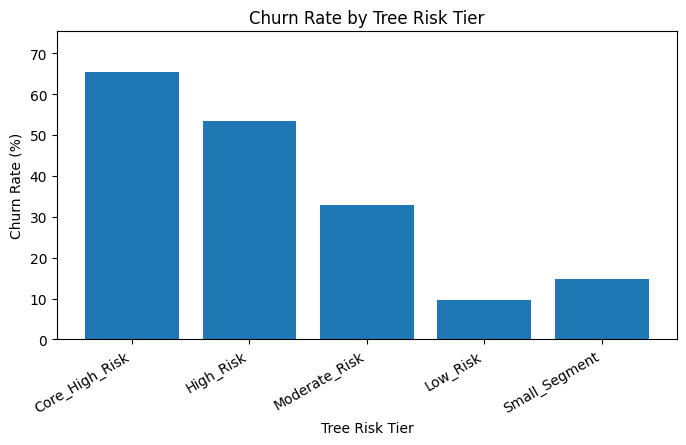

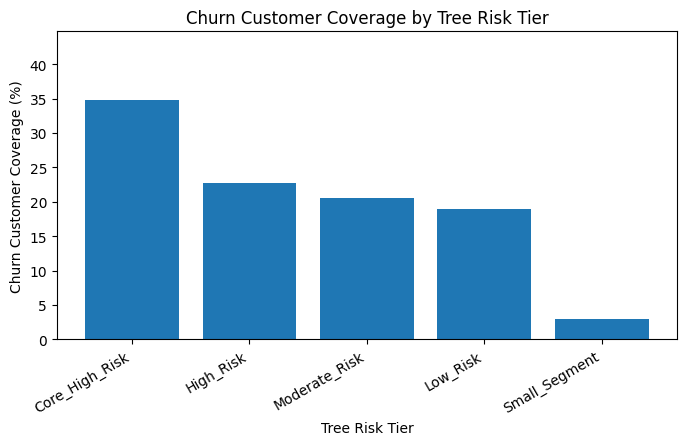


고위험 Leaf 규칙 전체:
Segment Name: Tree_Core_High_Risk_1
Risk Tier: Core_High_Risk
Leaf ID: 20
Customer Count: 163
Churn Count: 108
Churn Rate: 66.26
Rule:
Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges > 69.075 AND Tenure Months <= 10.500
Segment Name: Tree_Core_High_Risk_2
Risk Tier: Core_High_Risk
Leaf ID: 6
Customer Count: 36
Churn Count: 22
Churn Rate: 61.11
Rule:
Contract_Payment_Risk_Score <= 1.500 AND Tenure Months <= 5.500 AND Monthly Charges > 29.675
Segment Name: Tree_High_Risk_3
Risk Tier: High_Risk
Leaf ID: 17
Customer Count: 75
Churn Count: 43
Churn Rate: 57.33
Rule:
Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges <= 69.075 AND Tenure Months <= 3.500
Segment Name: Tree_High_Risk_4
Risk Tier: High_Risk
Leaf ID: 21
Customer Count: 84
Churn Count: 42
Churn Rate: 50.0
Rule:
Contract_Payment_Risk_Score > 1.500 AND Tenure Months <= 22.500 AND Monthly Charges > 69.075 AND Tenure Months > 10.500


In [48]:
# =========================
# 4-2. Decision Tree 세그먼트 이름 붙이기 및 커버율 분석
# =========================

# 표 출력 시 rule이 잘리지 않도록 설정
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

target = "Churn Value"


# -------------------------------------------------
# 1. Leaf 세그먼트에 위험 등급 부여
# -------------------------------------------------
# 기준:
# - Core_High_Risk: 고객 수 30명 이상, 이탈률 60% 이상
# - High_Risk: 고객 수 30명 이상, 이탈률 50~60%
# - Broad_Risk: 고객 수 30명 이상, 이탈률 40~50%
# - Moderate_Risk: 고객 수 30명 이상, 이탈률 20~40%
# - Low_Risk: 고객 수 30명 이상, 이탈률 20% 미만
# - Small_Segment: 고객 수 30명 미만

def assign_tree_risk_tier(row):
    count = row["customer_count"]
    churn_rate = row["churn_rate(%)"]

    if count < 30:
        return "Small_Segment"
    elif churn_rate >= 60:
        return "Core_High_Risk"
    elif churn_rate >= 50:
        return "High_Risk"
    elif churn_rate >= 40:
        return "Broad_Risk"
    elif churn_rate >= 20:
        return "Moderate_Risk"
    else:
        return "Low_Risk"


risk_tier_priority = {
    "Core_High_Risk": 1,
    "High_Risk": 2,
    "Broad_Risk": 3,
    "Moderate_Risk": 4,
    "Low_Risk": 5,
    "Small_Segment": 6
}

dt_segmented_leaf_test = dt_leaf_rules_with_test.copy()
dt_segmented_leaf_test["risk_tier"] = dt_segmented_leaf_test.apply(assign_tree_risk_tier, axis=1)
dt_segmented_leaf_test["risk_tier_priority"] = dt_segmented_leaf_test["risk_tier"].map(risk_tier_priority)

dt_segmented_leaf_test = dt_segmented_leaf_test.sort_values(
    ["risk_tier_priority", "churn_rate(%)", "customer_count"],
    ascending=[True, False, False]
).reset_index(drop=True)

print("Decision Tree Leaf별 위험 등급:")
display(dt_segmented_leaf_test)


# -------------------------------------------------
# 2. 고위험 Leaf 세그먼트만 추출
# -------------------------------------------------

tree_high_risk_leaf_segments = dt_segmented_leaf_test[
    dt_segmented_leaf_test["risk_tier"].isin([
        "Core_High_Risk",
        "High_Risk",
        "Broad_Risk"
    ])
].copy()

# 고위험 세그먼트 이름 부여
tree_high_risk_leaf_segments["segment_rank"] = range(1, len(tree_high_risk_leaf_segments) + 1)

tree_high_risk_leaf_segments["tree_segment_name"] = (
    "Tree_"
    + tree_high_risk_leaf_segments["risk_tier"]
    + "_"
    + tree_high_risk_leaf_segments["segment_rank"].astype(str)
)

tree_high_risk_leaf_segments = tree_high_risk_leaf_segments[
    [
        "tree_segment_name",
        "risk_tier",
        "leaf_id",
        "rule",
        "customer_count",
        "churn_count",
        "churn_rate(%)",
        "avg_pred_proba",
        "avg_tenure",
        "avg_monthly_charge",
        "avg_income_charge_ratio",
        "avg_support_service_count",
        "avg_contract_payment_risk_score"
    ]
]

print("\nDecision Tree 기반 고위험 세그먼트:")
display(tree_high_risk_leaf_segments)


# -------------------------------------------------
# 3. 위험 등급별 고객 커버율 / 이탈 고객 커버율 계산
# -------------------------------------------------
# 고객 커버율:
#   해당 세그먼트 고객 수 / 전체 고객 수
#
# 이탈 고객 커버율:
#   해당 세그먼트 안의 이탈 고객 수 / 전체 이탈 고객 수
#
# 이탈률:
#   해당 세그먼트 안의 이탈 고객 수 / 해당 세그먼트 고객 수

total_test_customers = len(dt_test_segment_df)
total_test_churn = dt_test_segment_df[target].sum()

tree_risk_tier_summary_test = dt_segmented_leaf_test.groupby(
    ["risk_tier", "risk_tier_priority"]
).agg(
    leaf_count=("leaf_id", "nunique"),
    customer_count=("customer_count", "sum"),
    churn_count=("churn_count", "sum")
).reset_index()

tree_risk_tier_summary_test["customer_coverage(%)"] = (
    tree_risk_tier_summary_test["customer_count"] / total_test_customers * 100
).round(2)

tree_risk_tier_summary_test["churn_coverage(%)"] = (
    tree_risk_tier_summary_test["churn_count"] / total_test_churn * 100
).round(2)

tree_risk_tier_summary_test["churn_rate(%)"] = (
    tree_risk_tier_summary_test["churn_count"] / tree_risk_tier_summary_test["customer_count"] * 100
).round(2)

tree_risk_tier_summary_test = tree_risk_tier_summary_test.sort_values(
    "risk_tier_priority"
).reset_index(drop=True)

print("\n테스트 데이터 기준 위험 등급별 커버율:")
display(tree_risk_tier_summary_test)


# -------------------------------------------------
# 4. 전체 데이터에도 같은 Leaf 위험 등급 적용
# -------------------------------------------------
# 테스트 데이터에서 정의한 leaf_id별 risk_tier를 전체 데이터에 적용한다.
# 전체 데이터 기준으로 각 세그먼트의 규모를 참고한다.

leaf_risk_label_map = dt_segmented_leaf_test[
    ["leaf_id", "risk_tier", "risk_tier_priority"]
].copy()

dt_leaf_summary_full_labeled = dt_leaf_summary_full.merge(
    leaf_risk_label_map,
    on="leaf_id",
    how="left"
)

total_full_customers = len(dt_full_segment_df)
total_full_churn = dt_full_segment_df[target].sum()

tree_risk_tier_summary_full = dt_leaf_summary_full_labeled.groupby(
    ["risk_tier", "risk_tier_priority"]
).agg(
    leaf_count=("leaf_id", "nunique"),
    customer_count=("customer_count", "sum"),
    churn_count=("churn_count", "sum")
).reset_index()

tree_risk_tier_summary_full["customer_coverage(%)"] = (
    tree_risk_tier_summary_full["customer_count"] / total_full_customers * 100
).round(2)

tree_risk_tier_summary_full["churn_coverage(%)"] = (
    tree_risk_tier_summary_full["churn_count"] / total_full_churn * 100
).round(2)

tree_risk_tier_summary_full["churn_rate(%)"] = (
    tree_risk_tier_summary_full["churn_count"] / tree_risk_tier_summary_full["customer_count"] * 100
).round(2)

tree_risk_tier_summary_full = tree_risk_tier_summary_full.sort_values(
    "risk_tier_priority"
).reset_index(drop=True)

print("\n전체 데이터 기준 위험 등급별 커버율:")
display(tree_risk_tier_summary_full)


# =========================
# 4-2 수정. 고위험군 전체 요약부터 다시 실행
# =========================

target = "Churn Value"

# -------------------------------------------------
# 5. 고위험군 전체 요약
# -------------------------------------------------

high_risk_tiers = ["Core_High_Risk", "High_Risk", "Broad_Risk"]

high_risk_df_test = tree_risk_tier_summary_test[
    tree_risk_tier_summary_test["risk_tier"].isin(high_risk_tiers)
].copy()

total_test_customers = len(dt_test_segment_df)
total_test_churn = dt_test_segment_df[target].sum()

tree_high_risk_summary_test = pd.DataFrame([{
    "leaf_count": high_risk_df_test["leaf_count"].sum(),
    "customer_count": high_risk_df_test["customer_count"].sum(),
    "churn_count": high_risk_df_test["churn_count"].sum()
}])

tree_high_risk_summary_test["customer_coverage(%)"] = (
    tree_high_risk_summary_test["customer_count"] / total_test_customers * 100
).round(2)

tree_high_risk_summary_test["churn_coverage(%)"] = (
    tree_high_risk_summary_test["churn_count"] / total_test_churn * 100
).round(2)

tree_high_risk_summary_test["churn_rate(%)"] = (
    tree_high_risk_summary_test["churn_count"] / tree_high_risk_summary_test["customer_count"] * 100
).round(2)

print("\n테스트 데이터 기준 Tree 고위험군 전체 요약:")
display(tree_high_risk_summary_test)


# -------------------------------------------------
# 6. 위험 등급별 이탈률 그래프
# -------------------------------------------------

plot_tier = tree_risk_tier_summary_test.copy()

plt.figure(figsize=(8, 4))
plt.bar(plot_tier["risk_tier"], plot_tier["churn_rate(%)"])
plt.title("Churn Rate by Tree Risk Tier")
plt.xlabel("Tree Risk Tier")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(plot_tier["churn_rate(%)"]) + 10)
plt.show()


# -------------------------------------------------
# 7. 위험 등급별 이탈 고객 커버율 그래프
# -------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(plot_tier["risk_tier"], plot_tier["churn_coverage(%)"])
plt.title("Churn Customer Coverage by Tree Risk Tier")
plt.xlabel("Tree Risk Tier")
plt.ylabel("Churn Customer Coverage (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, max(plot_tier["churn_coverage(%)"]) + 10)
plt.show()


# -------------------------------------------------
# 8. Leaf별 규칙 전체 텍스트 출력
# -------------------------------------------------

print("\n고위험 Leaf 규칙 전체:")
for _, row in tree_high_risk_leaf_segments.iterrows():
    print("=" * 100)
    print("Segment Name:", row["tree_segment_name"])
    print("Risk Tier:", row["risk_tier"])
    print("Leaf ID:", row["leaf_id"])
    print("Customer Count:", row["customer_count"])
    print("Churn Count:", row["churn_count"])
    print("Churn Rate:", row["churn_rate(%)"])
    print("Rule:")
    print(row["rule"])

>Decision Tree 기반 세그먼테이션 결과 해석

Decision Tree는 고객을 총 15개의 leaf 세그먼트로 나누었고, 그중 테스트 데이터 기준으로 이탈률이 높은 세그먼트는 4개였습니다.
| 세그먼트 이름                 | 실제 조건                                                                                                 | 고객 수 | 이탈 수 |    이탈률 | 의미                                          |
| ----------------------- | ----------------------------------------------------------------------------------------------------- | ---: | ---: | -----: | ------------------------------------------- |
| `Tree_Core_High_Risk_1` | `Contract_Payment_Risk_Score > 1.5` AND `Tenure Months <= 10.5` AND `Monthly Charges > 69.075`        |  163 |  108 | 66.26% | 계약/결제 위험이 높고, 가입 기간이 짧으며, 월 요금도 높은 핵심 고위험군  |
| `Tree_Core_High_Risk_2` | `Contract_Payment_Risk_Score <= 1.5` AND `Tenure Months <= 5.5` AND `Monthly Charges > 29.675`        |   36 |   22 | 61.11% | 계약/결제 위험은 높지 않지만, 가입 초기에 이탈 가능성이 높은 신규 고객군  |
| `Tree_High_Risk_3`      | `Contract_Payment_Risk_Score > 1.5` AND `Tenure Months <= 3.5` AND `Monthly Charges <= 69.075`        |   75 |   43 | 57.33% | 월 요금은 높지 않아도, 계약/결제 위험이 높고 가입 기간이 매우 짧은 고객군 |
| `Tree_High_Risk_4`      | `Contract_Payment_Risk_Score > 1.5` AND `10.5 < Tenure Months <= 22.5` AND `Monthly Charges > 69.075` |   84 |   42 | 50.00% | 가입 초기 이후에도 계약/결제 위험과 높은 월 요금이 결합된 고객군       |



>세그먼트별 해석
1. Tree_Core_High_Risk_1

이 세그먼트는 가장 중요한 고위험군입니다.
조건은 계약/결제 위험 점수가 높고, 가입 기간이 약 10개월 이하이며, 월 요금이 높은 고객입니다.

즉, 이 고객들은 보통 다음과 같은 특징을 가집니다.

월 단위 계약 또는 Electronic check 또는 Paperless Billing 위험 신호가 2개 이상
+ 가입 기간이 짧음
+ 월 요금이 높음

이 세그먼트의 이탈률은 **66.26%**로 매우 높고, 고객 수도 163명으로 충분히 크기 때문에 리텐션 전략의 최우선 대상입니다.

2. Tree_Core_High_Risk_2

이 세그먼트는 계약/결제 위험 점수가 높지는 않지만, 가입 기간이 매우 짧은 신규 고객군입니다.
가입 기간이 5.5개월 이하이고 월 요금이 29.675보다 크면 이탈률이 **61.11%**까지 올라갑니다.

즉, 계약이나 결제 방식이 특별히 위험하지 않아도, 초기 사용 경험이 불안정한 고객은 이탈 위험이 높다는 의미입니다.

3. Tree_High_Risk_3

이 세그먼트는 가입 기간이 3.5개월 이하로 매우 짧고, 계약/결제 위험 점수가 높은 고객군입니다.
월 요금은 69.075 이하로 아주 높은 편은 아니지만, 이탈률은 **57.33%**입니다.

즉, 월 요금이 높지 않아도 가입 초기 + 계약/결제 위험 신호가 결합되면 이탈 위험이 커질 수 있습니다.

4. Tree_High_Risk_4

이 세그먼트는 가입 기간이 아주 짧지는 않지만, 아직 장기 고객은 아닌 10.5~22.5개월 구간 고객입니다.
여기에 계약/결제 위험 점수가 높고 월 요금도 높으면 이탈률이 **50.00%**로 나타났습니다.

즉, 이 고객군은 완전 신규 고객은 아니지만, 아직 충성 고객으로 정착하지 못한 상태에서 높은 요금과 불안정한 계약/결제 조건이 결합된 위험군입니다.

> Decision Tree 기반 세그먼테이션 결과, 테스트 데이터에서 총 15개의 leaf 세그먼트가 생성되었고 이 중 4개 세그먼트가 고위험군으로 분류되었다. 가장 중요한 세그먼트는 `Tree_Core_High_Risk_1`로, 계약/결제 위험 점수가 높고 가입 기간이 짧으며 월 요금이 높은 고객군이었다. 해당 세그먼트는 고객 수 163명, 이탈률 66.26%로 나타났다.
>
> Tree 기반 고위험군 전체는 테스트 고객의 25.41%를 차지했지만, 전체 이탈 고객의 57.49%를 포함하였다. 또한 고위험군 전체 이탈률은 60.06%로 전체 평균 이탈률보다 크게 높았다. 따라서 Decision Tree 세그먼테이션은 전체 고객 중 집중 관리가 필요한 고위험 고객군을 설명 가능한 규칙으로 정의하는 데 유용하다.
---

>참고용 파생변수 생성(1-11)
| 파생변수                          | 묶은 원본 변수                                                                | 생성 의미                                                               | 유용성                                                |
| ----------------------------- | ----------------------------------------------------------------------- | ------------------------------------------------------------------- | -------------------------------------------------- |
| `Is_Internet_User`            | `Internet Service`                                                      | 인터넷 서비스 이용 여부                                                       | 인터넷 미이용 고객과 이용 고객의 이탈률 구조가 다르므로 기본 구분 변수로 사용       |
| `Support_Service_Count`       | `Online Security`, `Online Backup`, `Device Protection`, `Tech Support` | 보안/지원 서비스 이용 개수                                                     | 서비스 이용 개수가 많을수록 이탈률이 낮아지는지 확인 가능                   |
| `Support_Service_Level`       | `Support_Service_Count` + `Internet Service`                            | 인터넷 미이용 고객을 따로 분리하고, 인터넷 이용 고객은 0~4개 서비스 이용 수준으로 구분                 | 가장 유용함. 0개 이용 고객 이탈률 56.67%, 4개 이용 고객 5.32%로 차이가 큼 |
| `Internet_User_No_Support`    | `Internet Service` + 보안/지원 4개 변수                                        | 인터넷은 쓰지만 보안/지원 서비스를 하나도 쓰지 않는 고객                                    | 명확한 고위험군 정의 가능. 해당 고객 이탈률 56.67%                   |
| `Contract_Payment_Risk_Score` | `Contract`, `Payment Method`, `Paperless Billing`                       | Month-to-month, Electronic check, Paperless Billing Yes를 각각 1점으로 합산 | 계약/결제 위험 신호가 누적될수록 이탈률이 단계적으로 증가                   |
| `Contract_Payment_Risk_Level` | `Contract_Payment_Risk_Score`                                           | 위험 점수를 low/moderate/high/very high로 라벨링                             | 보고서와 전략 제안에서 해석하기 쉬움                               |
| `Tenure_Group`                | `Tenure Months`                                                         | 가입 기간을 0-9, 10-29, 30-55, 56-72개월로 구간화                              | 신규 고객일수록 이탈률이 높은 패턴을 명확히 보여줌                       |
| `Monthly_Charge_Group`        | `Monthly Charges`                                                       | 월 요금 수준을 low/mid/high/very high로 구간화                                | 요금 부담과 이탈률의 관계 확인 가능                               |
| `Income_Charge_Burden_Group`  | `Income_Charge_Ratio`                                                   | 지역 소득 대비 요금 부담 수준 구간화                                               | 단순 요금보다 상대적 요금 부담을 반영                              |
| `Low_Tenure_High_Charge`      | `Tenure Months`, `Monthly Charges`                                      | 가입 기간 9개월 이하이면서 월 요금이 높은 고객                                         | 가장 강한 고위험군 중 하나. 이탈률 70.38%                        |


#5. Random Forest 모델 학습


##5-1. Random Forest 모델 학습

이제 5번 단계로 넘어가겠습니다.

Random Forest는 여러 개의 Decision Tree를 조합한 모델입니다.
방금 만든 단일 Decision Tree는 해석이 쉽지만 성능이 제한적일 수 있습니다. 반면 Random Forest는 여러 Tree를 평균내기 때문에 보통 더 안정적인 예측 성능을 기대할 수 있습니다.

이번 코드는 앞서 만든 4개 feature set 전체를 각각 Random Forest로 학습해서 비교합니다.

| 실행              | 사용한 데이터                                  | 의미                                 |
| --------------- | ---------------------------------------- | ---------------------------------- |
| Random Forest 1 | `1_original_without_income_charge_ratio` | 원본 변수만, Income_Charge_Ratio 제외     |
| Random Forest 2 | `2_original_with_income_charge_ratio`    | 원본 변수 + Income_Charge_Ratio        |
| Random Forest 3 | `3_derived_without_income_charge_ratio`  | 원본 변수 + 파생변수                       |
| Random Forest 4 | `4_derived_with_income_charge_ratio`     | 원본 변수 + 파생변수 + Income_Charge_Ratio |



[1_original_without_income_charge_ratio] Random Forest 학습
범주형 변수 수: 17
수치형 변수 수: 7

평가 결과:
Accuracy : 0.7651
Precision: 0.5400
Recall   : 0.7754
F1-score : 0.6367
ROC-AUC  : 0.8530
PR-AUC   : 0.6582

Confusion Matrix
[[788 247]
 [ 84 290]]

Classification Report
              precision    recall  f1-score   support

   Non-Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.78      0.64       374

    accuracy                           0.77      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.77      0.78      1409


[2_original_with_income_charge_ratio] Random Forest 학습
범주형 변수 수: 17
수치형 변수 수: 8

평가 결과:
Accuracy : 0.7637
Precision: 0.5385
Recall   : 0.7674
F1-score : 0.6329
ROC-AUC  : 0.8524
PR-AUC   : 0.6598

Confusion Matrix
[[789 246]
 [ 87 287]]

Classification Report
              precision    recall  f1-score   support

   Non-Churn       0.90      0.76      0.83      1035
       Churn       0.54      0.77      

,feature_set,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,1_original_without_income_charge_ratio,0.7651,0.5400,0.7754,0.6367,0.8530,0.6582
1,2_original_with_income_charge_ratio,0.7637,0.5385,0.7674,0.6329,0.8524,0.6598
2,3_derived_without_income_charge_ratio,0.7630,0.5375,0.7674,0.6322,0.8515,0.6577
3,4_derived_with_income_charge_ratio,0.7658,0.5415,0.7674,0.6350,0.8514,0.6538



Random Forest Confusion Matrix 요약:


,feature_set,TN,FP,FN,TP
0,1_original_without_income_charge_ratio,788,247,84,290
1,2_original_with_income_charge_ratio,789,246,87,287
2,3_derived_without_income_charge_ratio,788,247,87,287
3,4_derived_with_income_charge_ratio,792,243,87,287



모델 성능 비교:


,model,feature_set,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression,1_original_without_income_charge_ratio,0.7452,0.5132,0.7807,0.6193,0.8480,0.6372
1,Logistic Regression,3_derived_without_income_charge_ratio,0.7495,0.5187,0.7781,0.6225,0.8495,0.6364
2,Logistic Regression,2_original_with_income_charge_ratio,0.7438,0.5115,0.7754,0.6164,0.8481,0.6366
3,Logistic Regression,4_derived_with_income_charge_ratio,0.7466,0.5151,0.7754,0.6190,0.8500,0.6354
4,Decision Tree Segmentation,tree_segmentation_features,0.7197,0.4830,0.7995,0.6022,0.8066,0.5553
5,Random Forest,1_original_without_income_charge_ratio,0.7651,0.5400,0.7754,0.6367,0.8530,0.6582
6,Random Forest,2_original_with_income_charge_ratio,0.7637,0.5385,0.7674,0.6329,0.8524,0.6598
7,Random Forest,3_derived_without_income_charge_ratio,0.7630,0.5375,0.7674,0.6322,0.8515,0.6577
8,Random Forest,4_derived_with_income_charge_ratio,0.7658,0.5415,0.7674,0.6350,0.8514,0.6538


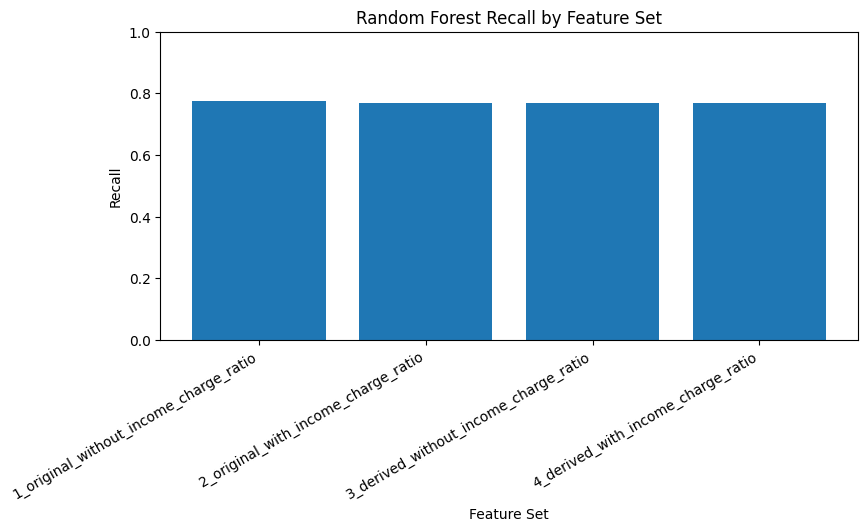

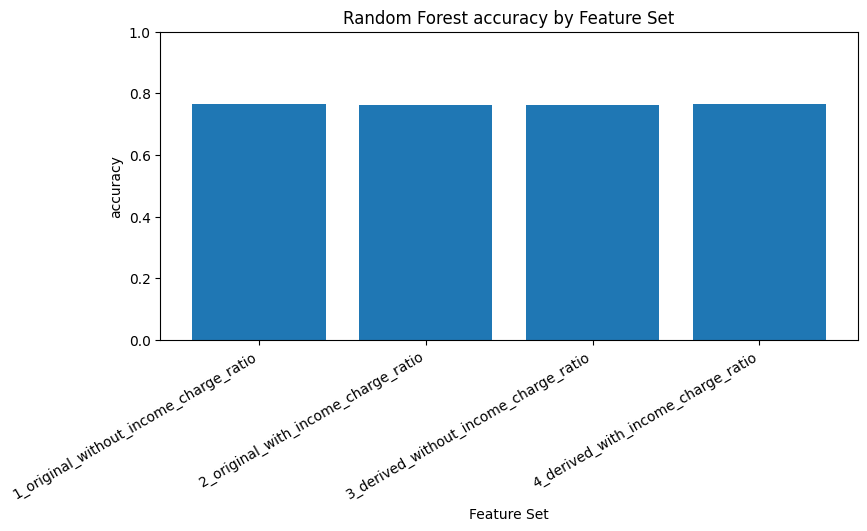

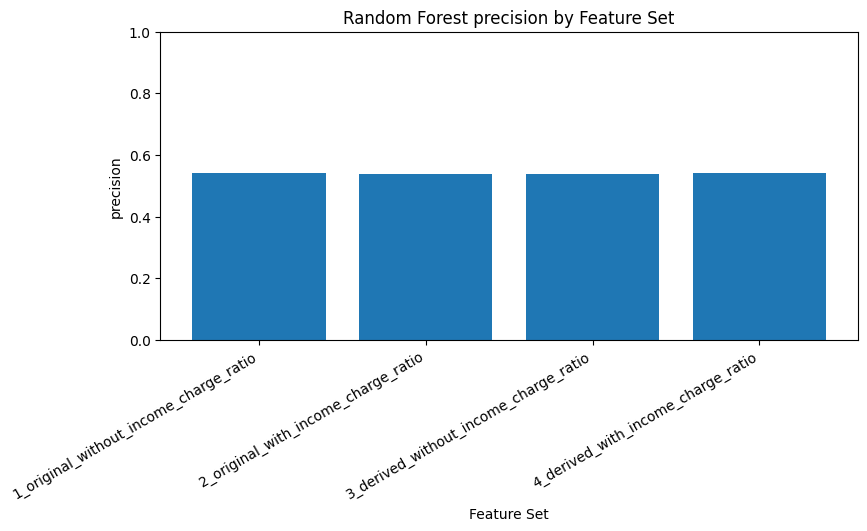

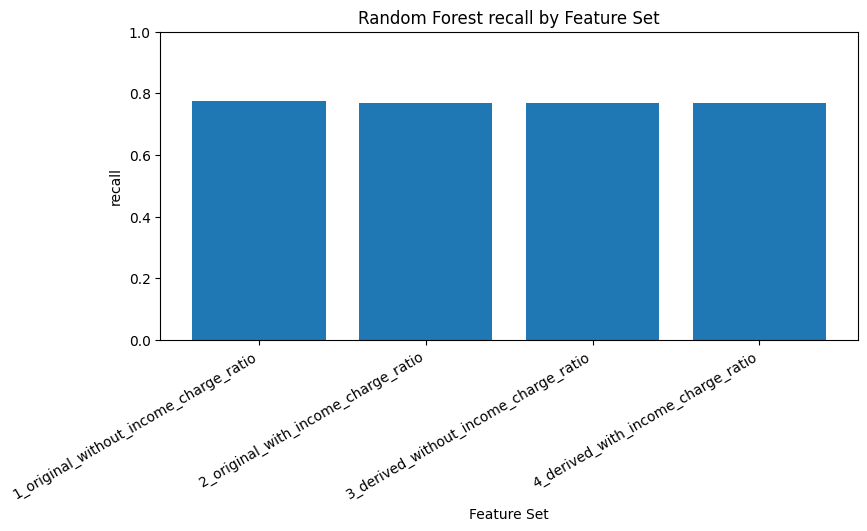

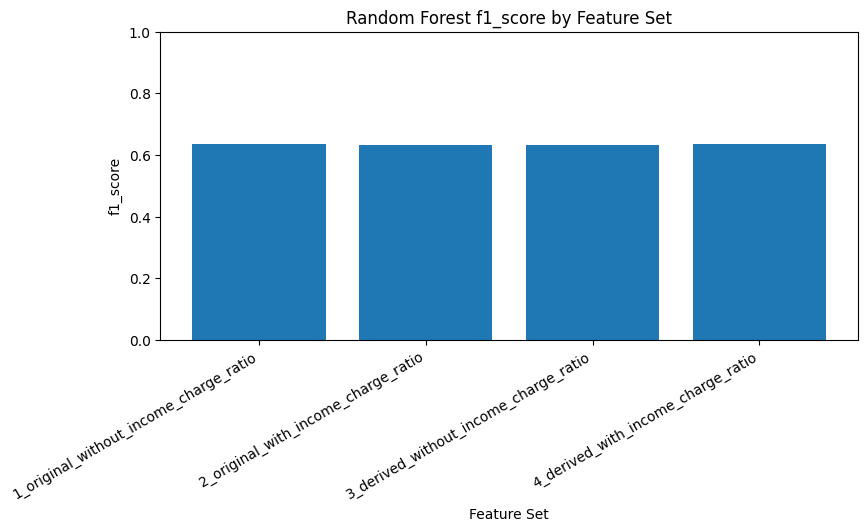

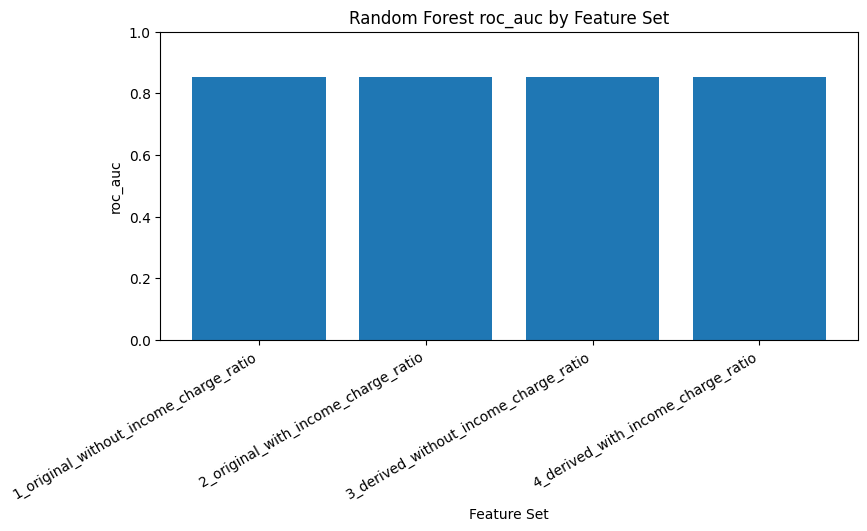

In [49]:
# =========================
# 5-1. Random Forest 모델 학습
# =========================

from sklearn.ensemble import RandomForestClassifier
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# -------------------------------------------------
# 1. OneHotEncoder 버전 호환 처리
# -------------------------------------------------

try:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot_encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)


# -------------------------------------------------
# 2. 결과 저장용 객체
# -------------------------------------------------

rf_models = {}
rf_result_list = []
rf_confusion_list = []


# -------------------------------------------------
# 3. Feature set별 Random Forest 학습
# -------------------------------------------------

for set_name, data in train_test_data.items():

    print("\n" + "=" * 90)
    print(f"[{set_name}] Random Forest 학습")

    X_train = data["X_train"].copy()
    X_test = data["X_test"].copy()
    y_train = data["y_train"].copy()
    y_test = data["y_test"].copy()

    # 범주형 / 수치형 변수 분리
    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    print(f"범주형 변수 수: {len(categorical_cols)}")
    print(f"수치형 변수 수: {len(numeric_cols)}")

    # 수치형 전처리: 결측치 중앙값 대체
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    # 범주형 전처리: 결측치 최빈값 대체 + One-Hot Encoding
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", onehot_encoder)
    ])

    # 전체 전처리
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    # Random Forest 모델
    rf_model = RandomForestClassifier(
        n_estimators=300,
        max_depth=8,
        min_samples_leaf=20,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    # 전처리 + 모델 파이프라인
    rf_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", rf_model)
    ])

    # 학습
    rf_pipeline.fit(X_train, y_train)

    # 예측
    y_pred = rf_pipeline.predict(X_test)
    y_pred_proba = rf_pipeline.predict_proba(X_test)[:, 1]

    # 평가 지표 계산
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    rf_result_list.append({
        "feature_set": set_name,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "roc_auc": round(roc_auc, 4),
        "pr_auc": round(pr_auc, 4)
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    rf_confusion_list.append({
        "feature_set": set_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    # 모델 저장
    rf_models[set_name] = rf_pipeline

    print("\n평가 결과:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred, target_names=["Non-Churn", "Churn"]))


# -------------------------------------------------
# 4. 전체 feature set 성능 비교표
# -------------------------------------------------

rf_result_summary = pd.DataFrame(rf_result_list)
rf_result_summary = rf_result_summary.sort_values(
    "recall",
    ascending=False
).reset_index(drop=True)

print("\nRandom Forest 성능 비교:")
display(rf_result_summary)


# -------------------------------------------------
# 5. Confusion Matrix 요약표
# -------------------------------------------------

rf_confusion_summary = pd.DataFrame(rf_confusion_list)

print("\nRandom Forest Confusion Matrix 요약:")
display(rf_confusion_summary)


# -------------------------------------------------
# 6. Logistic Regression / Decision Tree / Random Forest 비교
# -------------------------------------------------

model_comparison_summary = pd.concat([
    logistic_result_summary.assign(model="Logistic Regression"),
    dt_segment_result_summary.assign(feature_set="tree_segmentation_features"),
    rf_result_summary.assign(model="Random Forest")
], axis=0, ignore_index=True)

# Decision Tree 행의 컬럼 정리
model_comparison_summary["model"] = model_comparison_summary["model"].fillna("Decision Tree Segmentation")

model_comparison_summary = model_comparison_summary[
    ["model", "feature_set", "accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]
]

print("\n모델 성능 비교:")
display(model_comparison_summary)


# -------------------------------------------------
# 7. Random Forest Recall 비교 그래프
# -------------------------------------------------

plt.figure(figsize=(9, 4))
plt.bar(rf_result_summary["feature_set"], rf_result_summary["recall"])
plt.title("Random Forest Recall by Feature Set")
plt.xlabel("Feature Set")
plt.ylabel("Recall")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()


# -------------------------------------------------
# 8. Random Forest 주요 지표 비교 그래프
# -------------------------------------------------

metric_cols = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

for metric in metric_cols:
    plt.figure(figsize=(9, 4))
    plt.bar(rf_result_summary["feature_set"], rf_result_summary[metric])
    plt.title(f"Random Forest {metric} by Feature Set")
    plt.xlabel("Feature Set")
    plt.ylabel(metric)
    plt.xticks(rotation=30, ha="right")
    plt.ylim(0, 1)
    plt.show()

> Random Forest는 여러 개의 Decision Tree를 결합한 앙상블 모델이다. 본 분석에서는 4개의 후보 feature set을 한 번에 합쳐서 학습한 것이 아니라, 각 후보군별로 Random Forest 모델을 각각 학습하여 성능을 비교하였다. 즉, 원본 변수만 사용한 경우, `Income_Charge_Ratio`를 추가한 경우, 파생변수를 추가한 경우, 파생변수와 `Income_Charge_Ratio`를 모두 추가한 경우를 각각 별도의 Random Forest 모델로 학습하였다.
>
> 분석 결과, Random Forest에서는 원본 변수만 사용하고 `Income_Charge_Ratio`를 제외한 feature set이 Recall 0.7754, ROC-AUC 0.8530으로 가장 좋은 성능을 보였다. 따라서 Random Forest 기준에서는 파생변수와 Zip Code 기반 요금 부담 변수를 추가해도 성능 향상이 뚜렷하지 않았다.

#6.LightGBM 모델 학습

##6-1. LightGBM 모델 학습
LightGBM은 Gradient Boosting 계열 모델이라서 Random Forest보다 더 정교하게 패턴을 학습할 수 있습니다.
이번 단계에서는 앞과 동일하게 4개 feature set 전체를 학습해서 성능을 비교합니다.


[1_original_without_income_charge_ratio] LightGBM 학습
범주형 변수 수: 17
수치형 변수 수: 7
scale_pos_weight: 2.769


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



평가 결과:
Accuracy : 0.7693
Precision: 0.5479
Recall   : 0.7487
F1-score : 0.6328
ROC-AUC  : 0.8449
PR-AUC   : 0.6560

Confusion Matrix
[[804 231]
 [ 94 280]]

Classification Report
              precision    recall  f1-score   support

   Non-Churn       0.90      0.78      0.83      1035
       Churn       0.55      0.75      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409


[2_original_with_income_charge_ratio] LightGBM 학습
범주형 변수 수: 17
수치형 변수 수: 8
scale_pos_weight: 2.769


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



평가 결과:
Accuracy : 0.7630
Precision: 0.5380
Recall   : 0.7567
F1-score : 0.6289
ROC-AUC  : 0.8436
PR-AUC   : 0.6508

Confusion Matrix
[[792 243]
 [ 91 283]]

Classification Report
              precision    recall  f1-score   support

   Non-Churn       0.90      0.77      0.83      1035
       Churn       0.54      0.76      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.76      0.77      1409


[3_derived_without_income_charge_ratio] LightGBM 학습
범주형 변수 수: 21
수치형 변수 수: 12
scale_pos_weight: 2.769


...

,feature_set,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,2_original_with_income_charge_ratio,0.7630,0.5380,0.7567,0.6289,0.8436,0.6508
1,1_original_without_income_charge_ratio,0.7693,0.5479,0.7487,0.6328,0.8449,0.6560
2,4_derived_with_income_charge_ratio,0.7637,0.5397,0.7460,0.6263,0.8428,0.6492
3,3_derived_without_income_charge_ratio,0.7615,0.5367,0.7433,0.6233,0.8448,0.6553



LightGBM Confusion Matrix 요약:


,feature_set,TN,FP,FN,TP
0,1_original_without_income_charge_ratio,804,231,94,280
1,2_original_with_income_charge_ratio,792,243,91,283
2,3_derived_without_income_charge_ratio,795,240,96,278
3,4_derived_with_income_charge_ratio,797,238,95,279



전체 모델 성능 비교:


,model,feature_set,accuracy,precision,recall,f1_score,roc_auc,pr_auc
0,Logistic Regression,1_original_without_income_charge_ratio,0.7452,0.5132,0.7807,0.6193,0.8480,0.6372
1,Logistic Regression,3_derived_without_income_charge_ratio,0.7495,0.5187,0.7781,0.6225,0.8495,0.6364
2,Logistic Regression,2_original_with_income_charge_ratio,0.7438,0.5115,0.7754,0.6164,0.8481,0.6366
3,Logistic Regression,4_derived_with_income_charge_ratio,0.7466,0.5151,0.7754,0.6190,0.8500,0.6354
4,Decision Tree Segmentation,tree_segmentation_features,0.7197,0.4830,0.7995,0.6022,0.8066,0.5553
5,Random Forest,1_original_without_income_charge_ratio,0.7651,0.5400,0.7754,0.6367,0.8530,0.6582
6,Random Forest,2_original_with_income_charge_ratio,0.7637,0.5385,0.7674,0.6329,0.8524,0.6598
7,Random Forest,3_derived_without_income_charge_ratio,0.7630,0.5375,0.7674,0.6322,0.8515,0.6577
8,Random Forest,4_derived_with_income_charge_ratio,0.7658,0.5415,0.7674,0.6350,0.8514,0.6538
9,LightGBM,2_original_with_income_charge_ratio,0.7630,0.5380,0.7567,0.6289,0.8436,0.6508


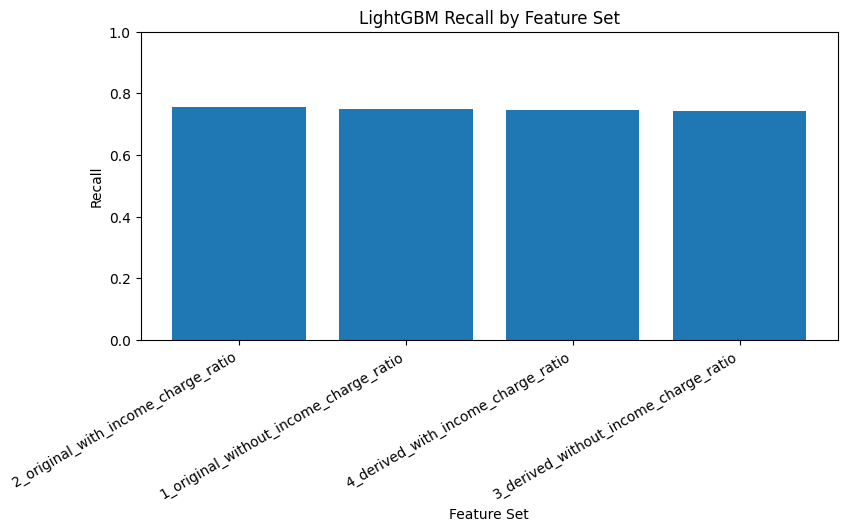

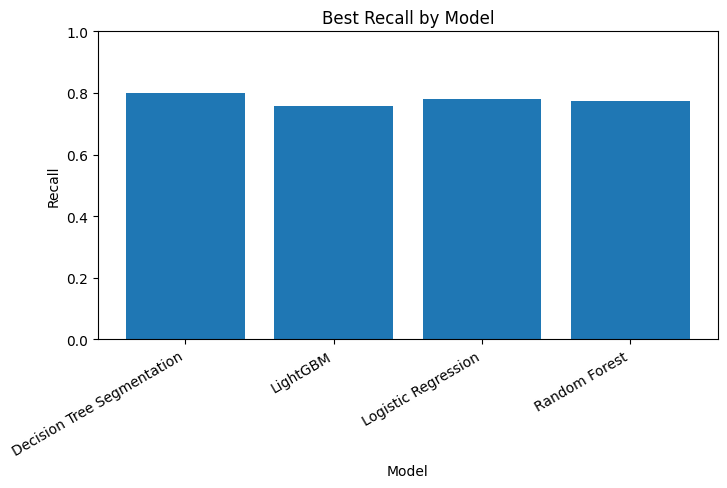

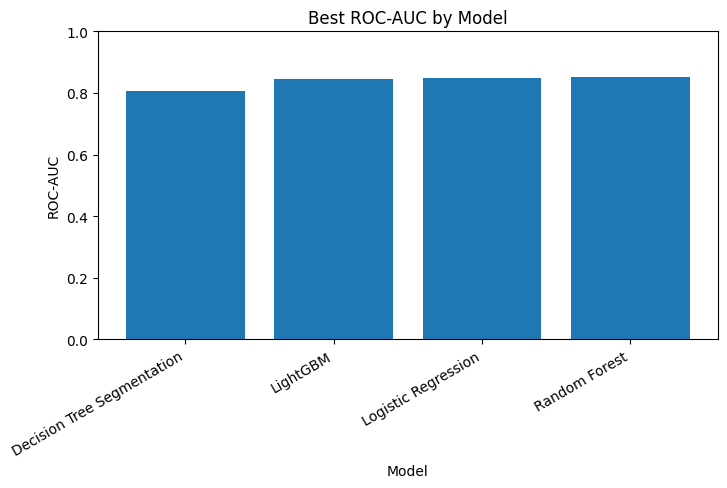

In [51]:
# =========================
# 6-1. LightGBM 모델 학습
# =========================

import sys
import subprocess

try:
    from lightgbm import LGBMClassifier
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "lightgbm", "-q"])
    from lightgbm import LGBMClassifier

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# -------------------------------------------------
# 1. OneHotEncoder 버전 호환 처리 함수
# -------------------------------------------------

def make_onehot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


# -------------------------------------------------
# 2. 결과 저장용 객체
# -------------------------------------------------

lgbm_models = {}
lgbm_result_list = []
lgbm_confusion_list = []


# -------------------------------------------------
# 3. Feature set별 LightGBM 학습
# -------------------------------------------------

for set_name, data in train_test_data.items():

    print("\n" + "=" * 90)
    print(f"[{set_name}] LightGBM 학습")

    X_train = data["X_train"].copy()
    X_test = data["X_test"].copy()
    y_train = data["y_train"].copy()
    y_test = data["y_test"].copy()

    # 범주형 / 수치형 변수 분리
    categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
    numeric_cols = X_train.select_dtypes(include=["int64", "float64", "int32", "float32"]).columns.tolist()

    print(f"범주형 변수 수: {len(categorical_cols)}")
    print(f"수치형 변수 수: {len(numeric_cols)}")

    # 클래스 불균형 보정용 scale_pos_weight
    # 비이탈 고객 수 / 이탈 고객 수
    negative_count = (y_train == 0).sum()
    positive_count = (y_train == 1).sum()
    scale_pos_weight = negative_count / positive_count

    print(f"scale_pos_weight: {scale_pos_weight:.3f}")

    # 수치형 전처리: 결측치 중앙값 대체
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    # 범주형 전처리: 결측치 최빈값 대체 + One-Hot Encoding
    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", make_onehot_encoder())
    ])

    # 전체 전처리
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ]
    )

    # LightGBM 모델
    lgbm_model = LGBMClassifier(
        n_estimators=500,
        learning_rate=0.03,
        max_depth=5,
        num_leaves=31,
        min_child_samples=30,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1,
        verbose=-1
    )

    # 전처리 + 모델 파이프라인
    lgbm_pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", lgbm_model)
    ])

    # 학습
    lgbm_pipeline.fit(X_train, y_train)

    # 예측
    y_pred = lgbm_pipeline.predict(X_test)
    y_pred_proba = lgbm_pipeline.predict_proba(X_test)[:, 1]

    # 평가 지표 계산
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    pr_auc = average_precision_score(y_test, y_pred_proba)

    lgbm_result_list.append({
        "feature_set": set_name,
        "accuracy": round(accuracy, 4),
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1_score": round(f1, 4),
        "roc_auc": round(roc_auc, 4),
        "pr_auc": round(pr_auc, 4)
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()

    lgbm_confusion_list.append({
        "feature_set": set_name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

    # 모델 저장
    lgbm_models[set_name] = lgbm_pipeline

    print("\n평가 결과:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")
    print(f"ROC-AUC  : {roc_auc:.4f}")
    print(f"PR-AUC   : {pr_auc:.4f}")

    print("\nConfusion Matrix")
    print(cm)

    print("\nClassification Report")
    print(classification_report(y_test, y_pred, target_names=["Non-Churn", "Churn"]))


# -------------------------------------------------
# 4. 전체 feature set 성능 비교표
# -------------------------------------------------

lgbm_result_summary = pd.DataFrame(lgbm_result_list)
lgbm_result_summary = lgbm_result_summary.sort_values(
    "recall",
    ascending=False
).reset_index(drop=True)

print("\nLightGBM 성능 비교:")
display(lgbm_result_summary)


# -------------------------------------------------
# 5. Confusion Matrix 요약표
# -------------------------------------------------

lgbm_confusion_summary = pd.DataFrame(lgbm_confusion_list)

print("\nLightGBM Confusion Matrix 요약:")
display(lgbm_confusion_summary)


# -------------------------------------------------
# 6. 전체 모델 성능 비교
# -------------------------------------------------

model_comparison_summary_v2 = pd.concat([
    logistic_result_summary.assign(model="Logistic Regression"),
    dt_segment_result_summary.assign(
        model="Decision Tree Segmentation",
        feature_set="tree_segmentation_features"
    ),
    rf_result_summary.assign(model="Random Forest"),
    lgbm_result_summary.assign(model="LightGBM")
], axis=0, ignore_index=True)

model_comparison_summary_v2 = model_comparison_summary_v2[
    ["model", "feature_set", "accuracy", "precision", "recall", "f1_score", "roc_auc", "pr_auc"]
]

print("\n전체 모델 성능 비교:")
display(model_comparison_summary_v2)


# -------------------------------------------------
# 7. LightGBM Recall 비교 그래프
# -------------------------------------------------

plt.figure(figsize=(9, 4))
plt.bar(lgbm_result_summary["feature_set"], lgbm_result_summary["recall"])
plt.title("LightGBM Recall by Feature Set")
plt.xlabel("Feature Set")
plt.ylabel("Recall")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()


# -------------------------------------------------
# 8. 전체 모델 Recall 비교 그래프
# -------------------------------------------------

best_by_model = model_comparison_summary_v2.sort_values(
    ["model", "recall"],
    ascending=[True, False]
).groupby("model").head(1)

plt.figure(figsize=(8, 4))
plt.bar(best_by_model["model"], best_by_model["recall"])
plt.title("Best Recall by Model")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()


# -------------------------------------------------
# 9. 전체 모델 ROC-AUC 비교 그래프
# -------------------------------------------------

best_auc_by_model = model_comparison_summary_v2.sort_values(
    ["model", "roc_auc"],
    ascending=[True, False]
).groupby("model").head(1)

plt.figure(figsize=(8, 4))
plt.bar(best_auc_by_model["model"], best_auc_by_model["roc_auc"])
plt.title("Best ROC-AUC by Model")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()

| Feature set                            | Accuracy | Precision | Recall | F1-score | ROC-AUC |
| -------------------------------------- | -------: | --------: | -----: | -------: | ------: |
| 2_original_with_income_charge_ratio    |   0.7630 |    0.5380 | 0.7567 |   0.6289 |  0.8436 |
| 1_original_without_income_charge_ratio |   0.7693 |    0.5479 | 0.7487 |   0.6328 |  0.8449 |
| 4_derived_with_income_charge_ratio     |   0.7637 |    0.5397 | 0.7460 |   0.6263 |  0.8428 |
| 3_derived_without_income_charge_ratio  |   0.7615 |    0.5367 | 0.7433 |   0.6233 |  0.8448 |


> LightGBM 모델을 4개의 feature set에 대해 학습한 결과, Recall 기준으로는 `Income_Charge_Ratio`를 포함한 원본 변수 후보군이 0.7567로 가장 높게 나타났다. 반면 Accuracy, F1-score, ROC-AUC 기준으로는 `Income_Charge_Ratio`를 제외한 원본 변수 후보군이 상대적으로 더 좋은 결과를 보였다.
>
> 전체 모델을 비교하면 Decision Tree 세그먼테이션은 Recall이 가장 높아 이탈 고객을 넓게 포착하는 데 유리했고, Random Forest는 ROC-AUC와 F1-score 측면에서 안정적인 성능을 보였다. LightGBM은 Gradient Boosting 기반 모델이지만, 현재 설정에서는 Random Forest보다 뚜렷한 성능 향상을 보이지 않았다. 따라서 이후 해석 단계에서는 LightGBM과 Random Forest의 Feature Importance 및 SHAP 값을 함께 확인하여 주요 이탈 요인을 비교한다.
---

| 모델                  | 현재 결과상 역할                                    |
| ------------------- | -------------------------------------------- |
| Logistic Regression | baseline 비교용                                 |
| Decision Tree       | Recall이 높고 규칙 해석이 쉬운 세그먼테이션 모델               |
| Random Forest       | Accuracy, Precision, F1, ROC-AUC가 안정적인 예측 모델 |
| LightGBM            | Boosting 모델이지만 현재 기본 threshold에서는 Recall이 낮음 |


> Random Forest와 LightGBM은 Decision Tree보다 복잡한 앙상블 모델이지만, 기본 threshold 0.5 기준에서는 Decision Tree보다 Recall이 낮게 나타났다. 이는 Decision Tree 세그먼테이션 모델이 고위험 고객을 넓게 포착하도록 동작하면서 Recall은 높아진 반면, Precision은 낮아졌기 때문이다.
>
> 반면 Random Forest는 ROC-AUC가 Decision Tree보다 높아 고객의 이탈 위험도를 순서화하는 능력은 더 우수했다. 따라서 단순히 기본 threshold 0.5에서의 Recall만 비교하기보다, 리텐션 목적에 맞게 threshold를 조정하여 Random Forest와 LightGBM의 Recall을 최적화할 필요가 있다.
---

##6-2. Threshold 조정으로 Recall 최적화

아래 코드는 Logistic Regression, Random Forest, LightGBM 중에서 각 모델의 예측 확률 threshold를 바꿔가며 Recall, Precision, F1-score를 비교합니다.

6-2에서는 4개 후보군 전체를 threshold 튜닝한 게 아니라, 각 모델에서 기본 threshold 0.5 기준 Recall이 가장 높았던 후보군 1개씩만 골라서 threshold 튜닝했습니다.

| 모델                  | 6-2에서 사용한 후보군                            | 선택 이유                                  |
| ------------------- | ---------------------------------------- | -------------------------------------- |
| Logistic Regression | `1_original_without_income_charge_ratio` | Logistic Regression 결과 중 Recall이 가장 높음 |
| Random Forest       | `1_original_without_income_charge_ratio` | Random Forest 결과 중 Recall이 가장 높음       |
| LightGBM            | `2_original_with_income_charge_ratio`    | LightGBM 결과 중 Recall이 가장 높음            |


Threshold 튜닝 대상 feature set
Logistic Regression: 1_original_without_income_charge_ratio
Random Forest: 1_original_without_income_charge_ratio
LightGBM: 2_original_with_income_charge_ratio


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Threshold별 성능 비교:


,model,feature_set,threshold,accuracy,precision,recall,f1_score,TN,FP,FN,TP
0,Logistic Regression,1_original_without_income_charge_ratio,0.20,0.6153,0.4058,0.9679,0.5719,505,530,12,362
1,Logistic Regression,1_original_without_income_charge_ratio,0.25,0.6430,0.4222,0.9358,0.5819,556,479,24,350
2,Logistic Regression,1_original_without_income_charge_ratio,0.30,0.6664,0.4378,0.9037,0.5899,601,434,36,338
3,Logistic Regression,1_original_without_income_charge_ratio,0.35,0.6899,0.4568,0.8904,0.6038,639,396,41,333
4,Logistic Regression,1_original_without_income_charge_ratio,0.40,0.7126,0.4772,0.8690,0.6161,679,356,49,325
5,Logistic Regression,1_original_without_income_charge_ratio,0.45,0.7324,0.4976,0.8182,0.6188,726,309,68,306
6,Logistic Regression,1_original_without_income_charge_ratio,0.50,0.7452,0.5132,0.7807,0.6193,758,277,82,292
7,Logistic Regression,1_original_without_income_charge_ratio,0.55,0.7637,0.5395,0.7487,0.6271,796,239,94,280
8,Logistic Regression,1_original_without_income_charge_ratio,0.60,0.7729,0.5556,0.7219,0.6279,819,216,104,270
9,Logistic Regression,1_original_without_income_charge_ratio,0.65,0.7800,0.5724,0.6765,0.6201,846,189,121,253



Precision >= 0.45 조건에서 모델별 Recall 최적 threshold:


,model,feature_set,threshold,accuracy,precision,recall,f1_score,TN,FP,FN,TP
0,LightGBM,2_original_with_income_charge_ratio,0.30,0.7083,0.4731,0.8690,0.6126,673,362,49,325
1,Logistic Regression,1_original_without_income_charge_ratio,0.35,0.6899,0.4568,0.8904,0.6038,639,396,41,333
2,Random Forest,1_original_without_income_charge_ratio,0.35,0.6934,0.4601,0.8930,0.6073,643,392,40,334


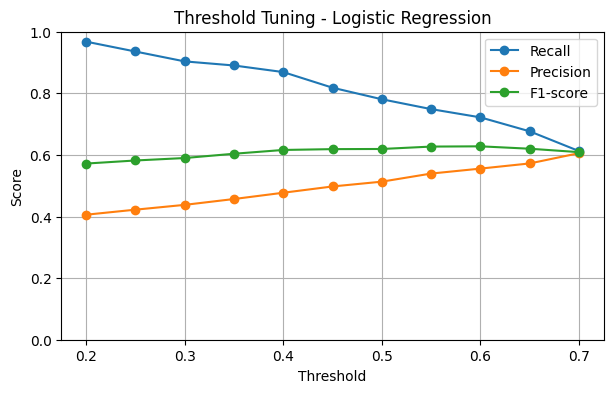

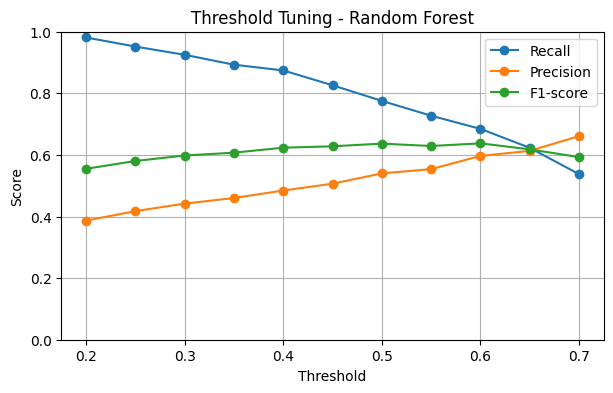

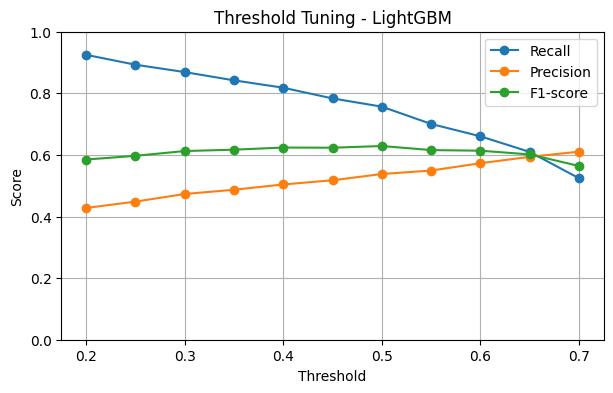

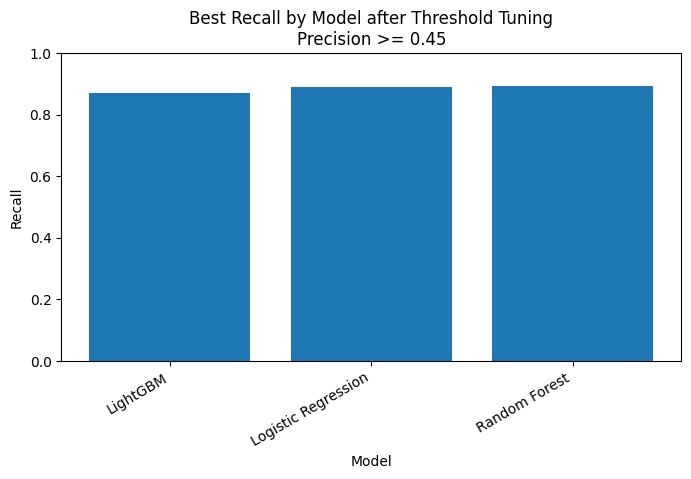

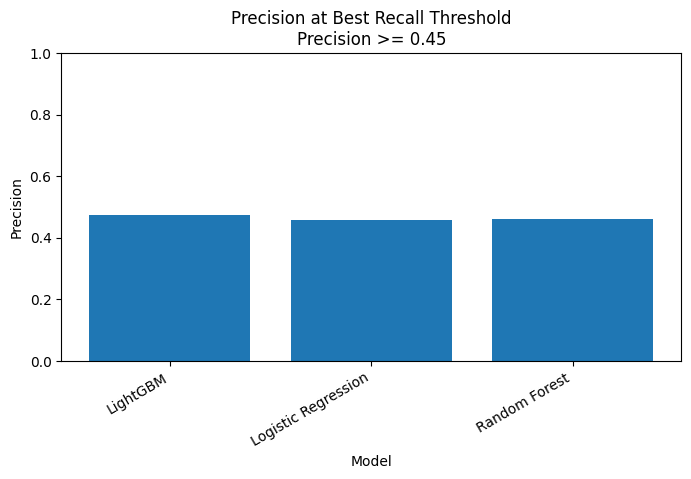

In [52]:
# =========================
# 6-2. Threshold 조정으로 Recall 최적화
# =========================

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# -------------------------------------------------
# 1. threshold별 성능 계산 함수
# -------------------------------------------------

def evaluate_thresholds(model, X_test, y_test, model_name, feature_set, thresholds):
    y_proba = model.predict_proba(X_test)[:, 1]

    result_list = []

    for threshold in thresholds:
        y_pred = (y_proba >= threshold).astype(int)

        accuracy = accuracy_score(y_test, y_pred)
        precision = precision_score(y_test, y_pred, zero_division=0)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

        result_list.append({
            "model": model_name,
            "feature_set": feature_set,
            "threshold": threshold,
            "accuracy": round(accuracy, 4),
            "precision": round(precision, 4),
            "recall": round(recall, 4),
            "f1_score": round(f1, 4),
            "TN": tn,
            "FP": fp,
            "FN": fn,
            "TP": tp
        })

    return pd.DataFrame(result_list)


# -------------------------------------------------
# 2. threshold 후보
# -------------------------------------------------

thresholds = np.arange(0.20, 0.71, 0.05).round(2)


# -------------------------------------------------
# 3. 모델별 best feature set 선택
# -------------------------------------------------
# Logistic Regression: Recall 기준 best
best_logit_feature_set = logistic_result_summary.sort_values(
    "recall",
    ascending=False
).iloc[0]["feature_set"]

# Random Forest: Recall 기준 best
best_rf_feature_set = rf_result_summary.sort_values(
    "recall",
    ascending=False
).iloc[0]["feature_set"]

# LightGBM: Recall 기준 best
best_lgbm_feature_set = lgbm_result_summary.sort_values(
    "recall",
    ascending=False
).iloc[0]["feature_set"]

print("Threshold 튜닝 대상 feature set")
print("Logistic Regression:", best_logit_feature_set)
print("Random Forest:", best_rf_feature_set)
print("LightGBM:", best_lgbm_feature_set)


# -------------------------------------------------
# 4. threshold별 성능 계산
# -------------------------------------------------

threshold_result_list = []

# Logistic Regression
X_test_logit = train_test_data[best_logit_feature_set]["X_test"]
y_test_logit = train_test_data[best_logit_feature_set]["y_test"]

threshold_result_list.append(
    evaluate_thresholds(
        logistic_models[best_logit_feature_set],
        X_test_logit,
        y_test_logit,
        "Logistic Regression",
        best_logit_feature_set,
        thresholds
    )
)

# Random Forest
X_test_rf = train_test_data[best_rf_feature_set]["X_test"]
y_test_rf = train_test_data[best_rf_feature_set]["y_test"]

threshold_result_list.append(
    evaluate_thresholds(
        rf_models[best_rf_feature_set],
        X_test_rf,
        y_test_rf,
        "Random Forest",
        best_rf_feature_set,
        thresholds
    )
)

# LightGBM
X_test_lgbm = train_test_data[best_lgbm_feature_set]["X_test"]
y_test_lgbm = train_test_data[best_lgbm_feature_set]["y_test"]

threshold_result_list.append(
    evaluate_thresholds(
        lgbm_models[best_lgbm_feature_set],
        X_test_lgbm,
        y_test_lgbm,
        "LightGBM",
        best_lgbm_feature_set,
        thresholds
    )
)

threshold_result_summary = pd.concat(
    threshold_result_list,
    axis=0
).reset_index(drop=True)

print("Threshold별 성능 비교:")
display(threshold_result_summary)


# -------------------------------------------------
# 5. Precision 최소 기준을 둔 Recall 최적화
# -------------------------------------------------
# 너무 많은 고객을 Churn으로 예측하면 Recall은 높지만 Precision이 너무 낮아진다.
# 그래서 Precision이 0.45 이상인 조건에서 Recall이 가장 높은 threshold를 선택한다.

min_precision = 0.45

threshold_best_by_model = threshold_result_summary[
    threshold_result_summary["precision"] >= min_precision
].sort_values(
    ["model", "recall", "f1_score"],
    ascending=[True, False, False]
).groupby("model").head(1).reset_index(drop=True)

print(f"\nPrecision >= {min_precision} 조건에서 모델별 Recall 최적 threshold:")
display(threshold_best_by_model)


# -------------------------------------------------
# 6. threshold별 Recall 그래프
# -------------------------------------------------

for model_name in threshold_result_summary["model"].unique():
    temp = threshold_result_summary[
        threshold_result_summary["model"] == model_name
    ]

    plt.figure(figsize=(7, 4))
    plt.plot(temp["threshold"], temp["recall"], marker="o", label="Recall")
    plt.plot(temp["threshold"], temp["precision"], marker="o", label="Precision")
    plt.plot(temp["threshold"], temp["f1_score"], marker="o", label="F1-score")
    plt.title(f"Threshold Tuning - {model_name}")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()


# -------------------------------------------------
# 7. 최적 threshold 기준 모델 비교 그래프
# -------------------------------------------------

plt.figure(figsize=(8, 4))
plt.bar(threshold_best_by_model["model"], threshold_best_by_model["recall"])
plt.title(f"Best Recall by Model after Threshold Tuning\nPrecision >= {min_precision}")
plt.xlabel("Model")
plt.ylabel("Recall")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()

plt.figure(figsize=(8, 4))
plt.bar(threshold_best_by_model["model"], threshold_best_by_model["precision"])
plt.title(f"Precision at Best Recall Threshold\nPrecision >= {min_precision}")
plt.xlabel("Model")
plt.ylabel("Precision")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.show()

>6-2. Threshold 튜닝 결과 분석

>기본 threshold 0.5에서는 Decision Tree의 Recall이 가장 높았지만, Random Forest와 LightGBM은 예측 확률 threshold를 조정할 수 있습니다. Threshold를 낮추면 더 많은 고객을 이탈 위험군으로 분류하므로 Recall이 올라갑니다.

>이번에는 Precision ≥ 0.45라는 최소 조건을 두고 Recall을 최적화했습니다. 결과는 다음과 같습니다.


| 모델                  | 선택 threshold | Precision |     Recall | F1-score |  TP | FN | 해석                    |
| ------------------- | -----------: | --------: | ---------: | -------: | --: | -: | --------------------- |
| Random Forest       |         0.35 |    0.4601 | **0.8930** |   0.6073 | 334 | 40 | 가장 높은 Recall          |
| Logistic Regression |         0.35 |    0.4568 |     0.8904 |   0.6038 | 333 | 41 | RF와 거의 유사             |
| LightGBM            |         0.30 |    0.4731 |     0.8690 |   0.6126 | 325 | 49 | Precision과 F1 균형은 괜찮음 |


즉, 기본 threshold 0.5에서는 Decision Tree Recall이 0.7995로 가장 높았지만, threshold 튜닝 후에는 Random Forest Recall이 0.8930까지 올라갔습니다. 따라서 “Random Forest와 LightGBM을 쓰는 이유가 더 좋은 성능인데 Recall이 낮으면 안 되는 것 아닌가?”라는 문제는, threshold 튜닝을 통해 Random Forest가 더 높은 Recall을 달성했다고 정리하면 됩니다.

다만 Random Forest threshold 0.35는 Recall을 크게 높이는 대신 Precision이 0.4601로 낮아집니다. 즉, 이탈 고객을 많이 잡지만 비이탈 고객도 고위험군으로 많이 포함됩니다. 리텐션 캠페인 관점에서는 이 정도 trade-off가 오히려 괜찮을 수 있습니다. 이탈 고객을 놓치는 비용이 크기 때문입니다.

> 기본 threshold 0.5 기준에서는 Decision Tree 세그먼테이션 모델의 Recall이 0.7995로 가장 높았으나, Random Forest와 LightGBM은 예측 확률 threshold를 조정하여 Recall을 최적화할 수 있다. Precision이 0.45 이상인 조건에서 threshold를 조정한 결과, Random Forest는 threshold 0.35에서 Recall 0.8930을 기록하여 가장 높은 이탈 고객 탐지 성능을 보였다.
>
> 이는 Random Forest가 기본 threshold에서는 Decision Tree보다 Recall이 낮았지만, threshold 조정 후에는 더 많은 이탈 고객을 포착할 수 있음을 보여준다. 따라서 최종 예측 모델 관점에서는 Random Forest를 threshold 0.35로 조정한 모델을 Recall 중심 모델로 활용하고, Decision Tree는 고위험 고객군을 설명 가능한 규칙으로 정의하는 세그먼테이션 모델로 활용한다.
---

#7. SHAP / Feature Importance

##7-1. Random Forest Feature Importance / SHAP 분석

이제 7. SHAP / Feature Importance로 넘어가면 됩니다.

Threshold 튜닝 후 최종 Recall이 가장 높았던 모델은 Random Forest + 1_original_without_income_charge_ratio + threshold 0.35입니다.
따라서 이번 해석 단계에서는 이 Random Forest 모델이 어떤 변수를 중요하게 판단했는지 확인합니다.

Feature Importance / SHAP 분석 대상 모델
Model: Random Forest
Feature set: 1_original_without_income_charge_ratio
Selected threshold: 0.35

전처리 후 feature 수: 54


,num__Tenure Months,num__Monthly Charges,num__Total Charges,num__CLTV,num__Area_Total_Households,num__Area_Median_Income,num__Area_Mean_Income,cat__Gender_Female,cat__Gender_Male,cat__Senior Citizen_No,cat__Senior Citizen_Yes,cat__Partner_No,cat__Partner_Yes,cat__Dependents_No,cat__Dependents_Yes,cat__Phone Service_No,cat__Phone Service_Yes,cat__Multiple Lines_No,cat__Multiple Lines_No phone service,cat__Multiple Lines_Yes,cat__Internet Service_DSL,cat__Internet Service_Fiber optic,cat__Internet Service_No,cat__Online Security_No,cat__Online Security_No internet service,cat__Online Security_Yes,cat__Online Backup_No,cat__Online Backup_No internet service,cat__Online Backup_Yes,cat__Device Protection_No,cat__Device Protection_No internet service,cat__Device Protection_Yes,cat__Tech Support_No,cat__Tech Support_No internet service,cat__Tech Support_Yes,cat__Streaming TV_No,cat__Streaming TV_No internet service,cat__Streaming TV_Yes,cat__Streaming Movies_No,cat__Streaming Movies_No internet service,cat__Streaming Movies_Yes,cat__Contract_Month-to-month,cat__Contract_One year,cat__Contract_Two year,cat__Paperless Billing_No,cat__Paperless Billing_Yes,cat__Payment Method_Bank transfer (automatic),cat__Payment Method_Credit card (automatic),cat__Payment Method_Electronic check,cat__Payment Method_Mailed check,cat__Area_Income_Level_High,cat__Area_Income_Level_Low,cat__Area_Income_Level_Medium,cat__Area_Income_Level_Very High
2196,72.0,114.05,8468.20,4842.0,12225.0,61862.0,78463.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3549,8.0,100.15,908.55,5157.0,1092.0,156957.0,263158.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3515,41.0,78.35,3211.20,2894.0,7661.0,158462.0,196997.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
5162,18.0,78.20,1468.75,2831.0,1847.0,107899.0,124011.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0
4642,72.0,82.65,5919.35,4324.0,26141.0,69485.0,86311.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0



Random Forest Feature Importance 상위 30개:


,transformed_feature,importance
0,cat__Contract_Month-to-month,0.152714
1,num__Tenure Months,0.095645
2,cat__Online Security_No,0.067542
3,num__Total Charges,0.065369
4,cat__Contract_Two year,0.064079
5,cat__Tech Support_No,0.063158
6,cat__Internet Service_Fiber optic,0.055286
7,cat__Dependents_Yes,0.049958
8,cat__Dependents_No,0.045098
9,num__Monthly Charges,0.039485



원본 변수 기준 Random Forest Feature Importance:


,original_feature,total_importance
0,Contract,0.235790
1,Tenure Months,0.095645
2,Dependents,0.095056
3,Online Security,0.091380
4,Tech Support,0.086488
5,Internet Service,0.082348
6,Total Charges,0.065369
7,Payment Method,0.041994
8,Monthly Charges,0.039485
9,Online Backup,0.027407


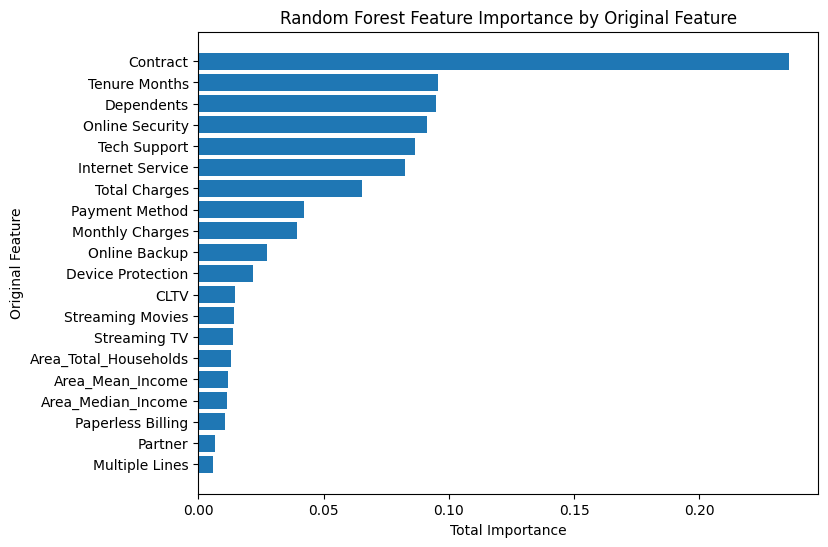


SHAP 계산 완료
X_shap shape: (500, 54)
SHAP values shape: (500, 54)

SHAP Importance 상위 30개:


,transformed_feature,mean_abs_shap,original_feature
0,cat__Contract_Month-to-month,0.072872,Contract
1,num__Tenure Months,0.047652,Tenure Months
2,cat__Internet Service_Fiber optic,0.037298,Internet Service
3,cat__Online Security_No,0.032913,Online Security
4,cat__Contract_Two year,0.031565,Contract
5,cat__Dependents_Yes,0.030865,Dependents
6,cat__Tech Support_No,0.029761,Tech Support
7,cat__Dependents_No,0.028446,Dependents
8,num__Total Charges,0.026786,Total Charges
9,cat__Payment Method_Electronic check,0.021772,Payment Method



원본 변수 기준 SHAP Importance:


,original_feature,total_mean_abs_shap
0,Contract,0.113088
1,Dependents,0.059311
2,Internet Service,0.056837
3,Tenure Months,0.047652
4,Online Security,0.046924
5,Tech Support,0.044032
6,Total Charges,0.026786
7,Payment Method,0.025578
8,Online Backup,0.018406
9,Monthly Charges,0.016582


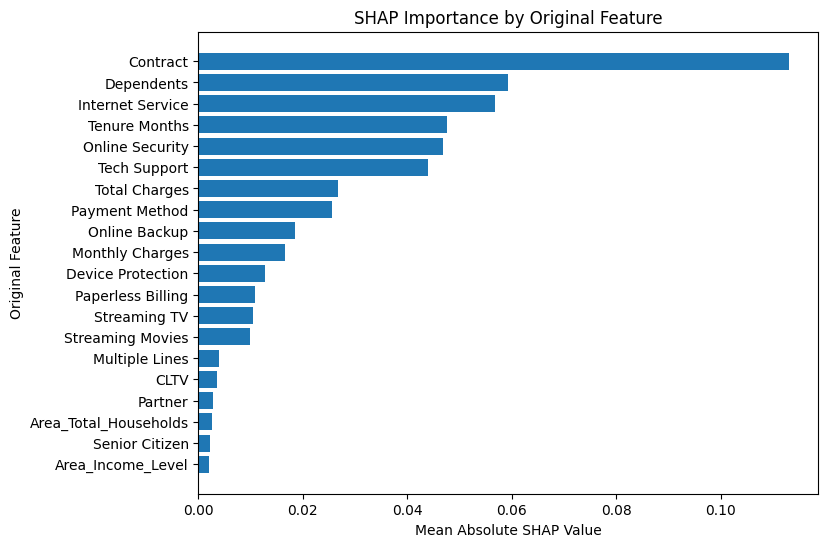

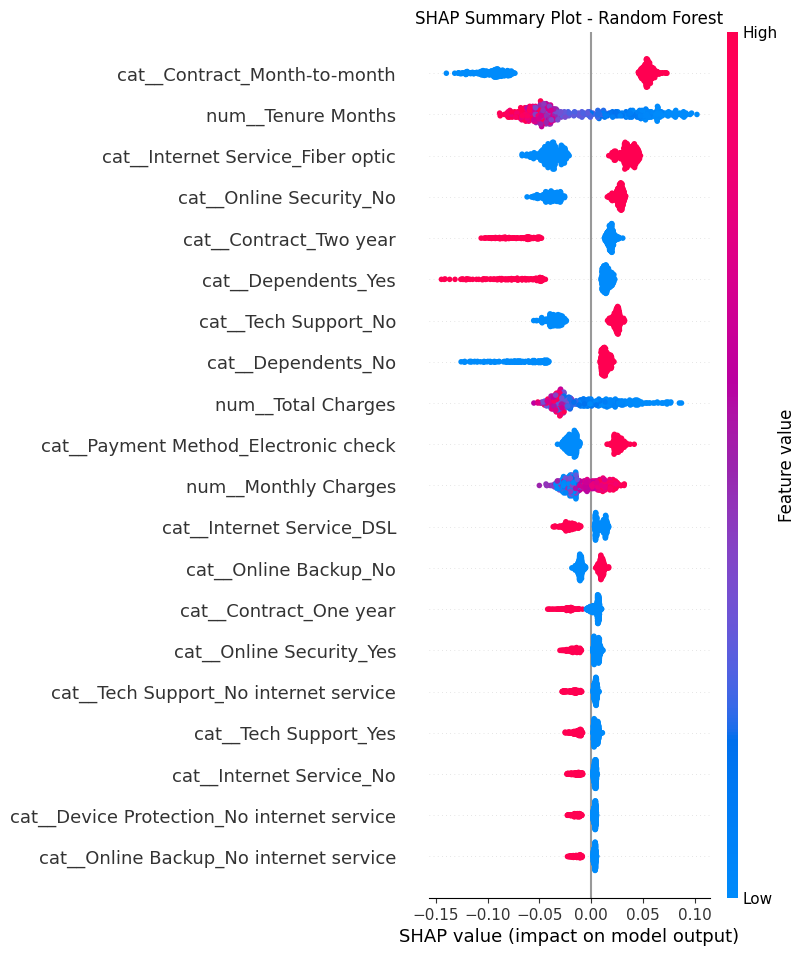


Feature Importance vs SHAP 비교:


,original_feature,total_importance,total_mean_abs_shap,importance_rank,shap_rank
0,Contract,0.235790,0.113088,1,1
1,Dependents,0.095056,0.059311,3,2
2,Internet Service,0.082348,0.056837,6,3
3,Tenure Months,0.095645,0.047652,2,4
4,Online Security,0.091380,0.046924,4,5
5,Tech Support,0.086488,0.044032,5,6
6,Total Charges,0.065369,0.026786,7,7
7,Payment Method,0.041994,0.025578,8,8
8,Online Backup,0.027407,0.018406,10,9
9,Monthly Charges,0.039485,0.016582,9,10


In [53]:
# =========================
# 7-1. Random Forest Feature Importance / SHAP 분석
# =========================

import sys
import subprocess
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import shap
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "shap", "-q"])
    import shap


# -------------------------------------------------
# 1. Threshold 튜닝 결과 기준 최종 Random Forest 모델 선택
# -------------------------------------------------

best_rf_row = threshold_best_by_model[
    threshold_best_by_model["model"] == "Random Forest"
].iloc[0]

best_rf_feature_set = best_rf_row["feature_set"]
best_rf_threshold = best_rf_row["threshold"]

best_rf_pipeline = rf_models[best_rf_feature_set]

print("Feature Importance / SHAP 분석 대상 모델")
print("Model: Random Forest")
print("Feature set:", best_rf_feature_set)
print("Selected threshold:", best_rf_threshold)


# -------------------------------------------------
# 2. 해당 feature set의 test 데이터 가져오기
# -------------------------------------------------

X_test_best = train_test_data[best_rf_feature_set]["X_test"].copy()
y_test_best = train_test_data[best_rf_feature_set]["y_test"].copy()

preprocessor = best_rf_pipeline.named_steps["preprocessor"]
rf_model_only = best_rf_pipeline.named_steps["model"]


# -------------------------------------------------
# 3. 전처리 후 feature matrix와 feature name 추출
# -------------------------------------------------

X_test_transformed = preprocessor.transform(X_test_best)

# sparse matrix인 경우 dense로 변환
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

try:
    transformed_feature_names = preprocessor.get_feature_names_out()
except:
    transformed_feature_names = [f"feature_{i}" for i in range(X_test_transformed.shape[1])]

X_test_transformed_df = pd.DataFrame(
    X_test_transformed,
    columns=transformed_feature_names,
    index=X_test_best.index
)

print("\n전처리 후 feature 수:", X_test_transformed_df.shape[1])
display(X_test_transformed_df.head())


# -------------------------------------------------
# 4. Random Forest 기본 Feature Importance
# -------------------------------------------------

rf_importance_df = pd.DataFrame({
    "transformed_feature": transformed_feature_names,
    "importance": rf_model_only.feature_importances_
}).sort_values("importance", ascending=False).reset_index(drop=True)

print("\nRandom Forest Feature Importance 상위 30개:")
display(rf_importance_df.head(30))


# -------------------------------------------------
# 5. One-Hot Encoding된 feature를 원본 변수 기준으로 묶기
# -------------------------------------------------

original_features = feature_sets[best_rf_feature_set]

def map_to_original_feature(transformed_feature, original_features):
    """
    num__Tenure Months -> Tenure Months
    cat__Contract_Month-to-month -> Contract
    형태로 원본 변수명을 복원한다.
    """
    name = transformed_feature

    if name.startswith("num__"):
        return name.replace("num__", "")

    if name.startswith("cat__"):
        cat_name = name.replace("cat__", "")

        # 원본 변수명이 긴 것부터 확인해야 안전함
        for original_col in sorted(original_features, key=len, reverse=True):
            if cat_name == original_col or cat_name.startswith(original_col + "_"):
                return original_col

    return name


rf_importance_df["original_feature"] = rf_importance_df["transformed_feature"].apply(
    lambda x: map_to_original_feature(x, original_features)
)

rf_original_importance = rf_importance_df.groupby("original_feature").agg(
    total_importance=("importance", "sum")
).reset_index()

rf_original_importance = rf_original_importance.sort_values(
    "total_importance",
    ascending=False
).reset_index(drop=True)

print("\n원본 변수 기준 Random Forest Feature Importance:")
display(rf_original_importance)


# -------------------------------------------------
# 6. 원본 변수 기준 Feature Importance 그래프
# -------------------------------------------------

top_n = 20

plot_importance = rf_original_importance.head(top_n).sort_values(
    "total_importance",
    ascending=True
)

plt.figure(figsize=(8, 6))
plt.barh(plot_importance["original_feature"], plot_importance["total_importance"])
plt.title("Random Forest Feature Importance by Original Feature")
plt.xlabel("Total Importance")
plt.ylabel("Original Feature")
plt.show()


# -------------------------------------------------
# 7. SHAP 값 계산
# -------------------------------------------------
# Random Forest SHAP은 계산량이 클 수 있으므로 test 데이터 중 500개만 샘플링

shap_sample_size = min(500, X_test_transformed_df.shape[0])

X_shap = X_test_transformed_df.sample(
    n=shap_sample_size,
    random_state=42
)

explainer = shap.TreeExplainer(rf_model_only)
shap_values = explainer.shap_values(X_shap)

# SHAP 출력 형태 처리
# 구버전: list 형태 [class0, class1]
# 신버전: ndarray 형태, 경우에 따라 (n_samples, n_features, n_classes)
if isinstance(shap_values, list):
    shap_values_positive = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    shap_values_positive = shap_values[:, :, 1]
else:
    shap_values_positive = shap_values

print("\nSHAP 계산 완료")
print("X_shap shape:", X_shap.shape)
print("SHAP values shape:", shap_values_positive.shape)


# -------------------------------------------------
# 8. transformed feature 기준 평균 절대 SHAP
# -------------------------------------------------

shap_importance_df = pd.DataFrame({
    "transformed_feature": X_shap.columns,
    "mean_abs_shap": np.abs(shap_values_positive).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

shap_importance_df["original_feature"] = shap_importance_df["transformed_feature"].apply(
    lambda x: map_to_original_feature(x, original_features)
)

print("\nSHAP Importance 상위 30개:")
display(shap_importance_df.head(30))


# -------------------------------------------------
# 9. 원본 변수 기준 SHAP Importance
# -------------------------------------------------

shap_original_importance = shap_importance_df.groupby("original_feature").agg(
    total_mean_abs_shap=("mean_abs_shap", "sum")
).reset_index()

shap_original_importance = shap_original_importance.sort_values(
    "total_mean_abs_shap",
    ascending=False
).reset_index(drop=True)

print("\n원본 변수 기준 SHAP Importance:")
display(shap_original_importance)


# -------------------------------------------------
# 10. 원본 변수 기준 SHAP Importance 그래프
# -------------------------------------------------

plot_shap = shap_original_importance.head(top_n).sort_values(
    "total_mean_abs_shap",
    ascending=True
)

plt.figure(figsize=(8, 6))
plt.barh(plot_shap["original_feature"], plot_shap["total_mean_abs_shap"])
plt.title("SHAP Importance by Original Feature")
plt.xlabel("Mean Absolute SHAP Value")
plt.ylabel("Original Feature")
plt.show()


# -------------------------------------------------
# 11. SHAP Summary Plot
# -------------------------------------------------
# feature 값이 높을 때 이탈 확률을 올리는지/내리는지 방향 확인

shap.summary_plot(
    shap_values_positive,
    X_shap,
    max_display=20,
    show=False
)

plt.title("SHAP Summary Plot - Random Forest")
plt.show()


# -------------------------------------------------
# 12. Feature Importance와 SHAP 결과 비교표
# -------------------------------------------------

importance_comparison = rf_original_importance.merge(
    shap_original_importance,
    on="original_feature",
    how="outer"
).fillna(0)

importance_comparison["importance_rank"] = importance_comparison["total_importance"].rank(
    ascending=False,
    method="min"
).astype(int)

importance_comparison["shap_rank"] = importance_comparison["total_mean_abs_shap"].rank(
    ascending=False,
    method="min"
).astype(int)

importance_comparison = importance_comparison.sort_values("shap_rank").reset_index(drop=True)

print("\nFeature Importance vs SHAP 비교:")
display(importance_comparison)

>이번 7-1은 Random Forest + 1_original_without_income_charge_ratio + threshold 0.35 모델을 기준으로 해석한 결과입니다. 따라서 이 SHAP 분석에는 Income_Charge_Ratio는 포함되지 않았음

>Random Forest Feature Importance와 SHAP Importance 모두에서 가장 중요한 변수는 **Contract**였습니다.
| 순위 | Feature Importance 기준 | SHAP 기준          |
| -: | --------------------- | ---------------- |
|  1 | Contract              | Contract         |
|  2 | Tenure Months         | Dependents       |
|  3 | Dependents            | Internet Service |
|  4 | Online Security       | Tenure Months    |
|  5 | Tech Support          | Online Security  |
|  6 | Internet Service      | Tech Support     |
|  7 | Total Charges         | Total Charges    |
|  8 | Payment Method        | Payment Method   |


>SHAP Summary Plot 해석

>SHAP Summary Plot을 보면 방향성도 명확합니다.
| 변수                                | 모델 해석                                                    |
| --------------------------------- | -------------------------------------------------------- |
| `Contract_Month-to-month`         | 값이 1일 때 SHAP 값이 양수 방향 → 이탈 확률 증가                         |
| `Contract_Two year`               | 값이 1일 때 SHAP 값이 음수 방향 → 이탈 확률 감소                         |
| `Tenure Months`                   | 값이 높을수록 SHAP 값이 음수 방향 → 가입 기간이 길수록 이탈 확률 감소              |
| `Internet Service_Fiber optic`    | 값이 1일 때 SHAP 값이 양수 방향 → Fiber optic 고객의 이탈 위험 증가         |
| `Online Security_No`              | 값이 1일 때 SHAP 값이 양수 방향 → 보안 서비스 미사용 시 이탈 위험 증가            |
| `Tech Support_No`                 | 값이 1일 때 SHAP 값이 양수 방향 → 기술 지원 미사용 시 이탈 위험 증가             |
| `Payment Method_Electronic check` | 값이 1일 때 SHAP 값이 양수 방향 → Electronic check 결제 고객의 이탈 위험 증가 |
| `Dependents_Yes`                  | 값이 1일 때 SHAP 값이 음수 방향 → 부양가족이 있는 고객은 이탈 위험 감소            |


>특히 Contract_Month-to-month, Internet Service_Fiber optic, Online Security_No, Tech Support_No, Payment Method_Electronic check는 이탈 확률을 높이는 방향으로 작용했습니다. 반대로 Contract_Two year, Dependents_Yes, 긴 Tenure Months는 이탈 확률을 낮추는 방향으로 작용했습니다.

>지역 소득 변수의 모델상 효용성

지역 소득 변수는 모델에서 중요도가 낮게 나왔습니다.

변수	SHAP 순위
Area_Total_Households	18위
Area_Income_Level	20위
Area_Mean_Income	21위
Area_Median_Income	22위

즉, Random Forest 기준에서는 지역 소득 자체는 주요 예측 변수로 강하게 사용되지 않았습니다.
앞선 EDA에서 봤던 것처럼, 지역 소득 변수는 단독으로 이탈을 설명하기보다는 Income_Charge_Ratio처럼 요금 부담과 결합했을 때 해석적 가치가 더 크다고 정리하는 것이 좋습니다.

>최종 주요 이탈 요인 3개

>EDA, Decision Tree, Random Forest SHAP 결과를 종합하면 최종 주요 이탈 요인은 아래 3개로 정리하는 게 가장 자연스럽습니다.
| 최종 요인        | 근거                                                                               |
| ------------ | -------------------------------------------------------------------------------- |
| 계약/결제 위험     | `Contract`가 Feature Importance와 SHAP 모두 1위, `Payment Method`도 상위권                |
| 짧은 가입 기간     | `Tenure Months`, `Total Charges`가 상위권이며, SHAP에서 가입 기간이 길수록 이탈 확률 감소              |
| 보안/지원 서비스 부족 | `Online Security`, `Tech Support`, `Internet Service`가 상위권이며, 서비스 미사용 시 이탈 확률 증가 |

>Dependents도 SHAP 기준 2위로 중요하게 나왔지만, 리텐션 전략으로 직접 개입하기 어려운 고객 속성입니다. 따라서 최종 전략 요인으로는 계약/결제, 가입 초기 관리, 보안/지원 서비스 이용 부족을 중심으로 잡는 것이 좋습니다.

> Random Forest 모델의 Feature Importance와 SHAP 값을 확인한 결과, `Contract`가 두 기준 모두에서 가장 중요한 변수로 나타났다. 그 외에도 `Tenure Months`, `Internet Service`, `Online Security`, `Tech Support`, `Total Charges`, `Payment Method`, `Dependents`가 주요 변수로 확인되었다.
>
> SHAP Summary Plot을 보면 `Month-to-month` 계약, `Fiber optic` 인터넷 서비스, `Online Security` 미사용, `Tech Support` 미사용, `Electronic check` 결제는 이탈 확률을 높이는 방향으로 작용하였다. 반대로 긴 가입 기간, Two year 계약, 부양가족이 있는 고객은 이탈 확률을 낮추는 방향으로 작용하였다.
>
> 따라서 모델 해석 결과를 종합하면 주요 이탈 요인은 계약/결제 위험, 짧은 가입 기간, 보안/지원 서비스 이용 부족으로 정리할 수 있다. 지역 소득 변수는 모델 중요도가 낮아 단독 예측 변수보다는 요금 부담 해석을 보완하는 외부 데이터 변수로 활용하는 것이 적절하다.
---

#8. 리텐션 전략

##8-1. 리텐션 전략 정리표 생성
아래 코드는 지금까지의 EDA, Decision Tree, SHAP 결과를 바탕으로 최종 리텐션 전략 표를 만드는 코드입니다.

최종 주요 이탈 요인 요약:


,final_churn_factor,related_features,evidence_from_eda,evidence_from_model
0,계약/결제 위험,"Contract, Payment Method, Paperless Billing",Month-to-month 계약과 Electronic check 결제 고객의 이탈률이 높음,SHAP 및 Feature Importance에서 Contract와 Payment Method가 상위 변수로 나타남
1,짧은 가입 기간,"Tenure Months, Total Charges",가입 기간이 짧은 고객일수록 이탈률이 높음,"SHAP에서 Tenure Months가 주요 변수로 나타났고, 가입 기간이 길수록 이탈 확률이 낮아짐"
2,보안/지원 서비스 이용 부족,"Online Security, Tech Support, Online Backup, Device Protection",보안/지원 서비스를 사용하지 않는 고객의 이탈률이 반복적으로 높음,"Online Security, Tech Support가 SHAP 및 Feature Importance 상위권에 포함됨"
3,요금 부담,"Monthly Charges, Income_Charge_Ratio",월 요금과 소득 대비 요금 부담이 높은 고객군에서 이탈률이 높음,"Monthly Charges가 SHAP 상위권에 포함되며, Decision Tree에서도 월 요금 조건이 고위험 세그먼트를 구분함"
4,Fiber optic 인터넷 서비스,Internet Service,Fiber optic 이용 고객의 이탈률이 DSL 또는 인터넷 미사용 고객보다 높음,"Internet Service가 SHAP 상위권에 포함되고, Fiber optic 값이 이탈 확률을 높이는 방향으로 작용함"



리텐션 전략 표:


,target_segment,risk_reason,retention_strategy,expected_effect,priority
0,Month-to-month + Electronic check 고객,계약 유지 장벽이 낮고 결제 방식이 이탈 위험과 강하게 연결됨,"자동이체 또는 신용카드 결제 전환 유도, 장기 계약 전환 시 할인 또는 혜택 제공",계약 지속성을 높이고 결제 마찰을 줄여 이탈 위험 감소,High
1,가입 초기 고객,서비스 경험이 충분히 형성되기 전에 이탈 가능성이 높음,"가입 후 1~3개월 온보딩 메시지, 사용 가이드, 초기 만족도 점검",초기 고객 경험을 개선하여 신규 고객 이탈 방지,High
2,보안/지원 서비스 미사용 인터넷 고객,문제 발생 시 지원 경험이 부족하여 서비스 만족도가 낮을 수 있음,"Online Security 또는 Tech Support 무료 체험 제공, 번들 상품 추천",서비스 의존도와 만족도를 높여 경쟁사 전환 가능성 감소,High
3,짧은 가입 기간 + 높은 월 요금 고객,서비스에 적응하기 전에 높은 요금 부담을 느낄 가능성이 큼,"초기 요금 할인, 맞춤형 요금제 추천, 사용량 기반 요금 최적화 안내",요금 부담을 낮춰 가격 민감 고객의 이탈 방지,Very High
4,Fiber optic 이용 고객,고가 서비스 사용에 비해 기대 품질 또는 체감 가치가 낮을 경우 이탈 가능성이 큼,"품질 점검, 속도/장애 모니터링, 고가 요금제 고객 대상 프리미엄 지원 제공",고가 서비스 고객의 체감 가치를 높여 불만 기반 이탈 감소,Medium


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51077 (\N{HANGUL SYLLABLE IB}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52488 (\N{HANGUL SYLLABLE CO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

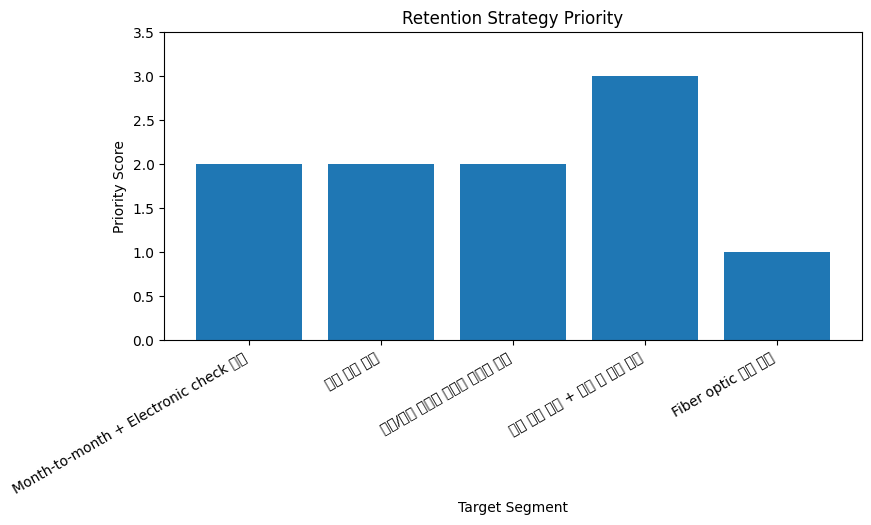


프로젝트 최종 요약:


,analysis_step,main_result
0,EDA,"계약, 가입 기간, 보안/지원 서비스, 요금 부담이 주요 이탈 위험 후보로 확인됨"
1,Decision Tree Segmentation,Tree 고위험군은 테스트 고객의 25.41%를 차지하지만 전체 이탈 고객의 57.49%를 포함함
2,Random Forest / LightGBM,Threshold 튜닝 후 Random Forest가 Recall 0.8930으로 가장 높은 이탈 탐지 성능을 보임
3,SHAP / Feature Importance,"Contract, Tenure Months, Internet Service, Online Security, Tech Support가 주요 변수로 확인됨"
4,Retention Strategy,"계약/결제 전환, 초기 고객 온보딩, 보안/지원 서비스 번들, 요금 최적화 전략 제안"


In [54]:
# =========================
# 8-1. 리텐션 전략 정리표 생성
# =========================

# -------------------------------------------------
# 1. 최종 주요 이탈 요인과 근거 정리
# -------------------------------------------------

final_churn_factor_summary = pd.DataFrame({
    "final_churn_factor": [
        "계약/결제 위험",
        "짧은 가입 기간",
        "보안/지원 서비스 이용 부족",
        "요금 부담",
        "Fiber optic 인터넷 서비스"
    ],
    "related_features": [
        "Contract, Payment Method, Paperless Billing",
        "Tenure Months, Total Charges",
        "Online Security, Tech Support, Online Backup, Device Protection",
        "Monthly Charges, Income_Charge_Ratio",
        "Internet Service"
    ],
    "evidence_from_eda": [
        "Month-to-month 계약과 Electronic check 결제 고객의 이탈률이 높음",
        "가입 기간이 짧은 고객일수록 이탈률이 높음",
        "보안/지원 서비스를 사용하지 않는 고객의 이탈률이 반복적으로 높음",
        "월 요금과 소득 대비 요금 부담이 높은 고객군에서 이탈률이 높음",
        "Fiber optic 이용 고객의 이탈률이 DSL 또는 인터넷 미사용 고객보다 높음"
    ],
    "evidence_from_model": [
        "SHAP 및 Feature Importance에서 Contract와 Payment Method가 상위 변수로 나타남",
        "SHAP에서 Tenure Months가 주요 변수로 나타났고, 가입 기간이 길수록 이탈 확률이 낮아짐",
        "Online Security, Tech Support가 SHAP 및 Feature Importance 상위권에 포함됨",
        "Monthly Charges가 SHAP 상위권에 포함되며, Decision Tree에서도 월 요금 조건이 고위험 세그먼트를 구분함",
        "Internet Service가 SHAP 상위권에 포함되고, Fiber optic 값이 이탈 확률을 높이는 방향으로 작용함"
    ]
})

print("최종 주요 이탈 요인 요약:")
display(final_churn_factor_summary)


# -------------------------------------------------
# 2. 리텐션 전략 표
# -------------------------------------------------

retention_strategy_table = pd.DataFrame({
    "target_segment": [
        "Month-to-month + Electronic check 고객",
        "가입 초기 고객",
        "보안/지원 서비스 미사용 인터넷 고객",
        "짧은 가입 기간 + 높은 월 요금 고객",
        "Fiber optic 이용 고객"
    ],
    "risk_reason": [
        "계약 유지 장벽이 낮고 결제 방식이 이탈 위험과 강하게 연결됨",
        "서비스 경험이 충분히 형성되기 전에 이탈 가능성이 높음",
        "문제 발생 시 지원 경험이 부족하여 서비스 만족도가 낮을 수 있음",
        "서비스에 적응하기 전에 높은 요금 부담을 느낄 가능성이 큼",
        "고가 서비스 사용에 비해 기대 품질 또는 체감 가치가 낮을 경우 이탈 가능성이 큼"
    ],
    "retention_strategy": [
        "자동이체 또는 신용카드 결제 전환 유도, 장기 계약 전환 시 할인 또는 혜택 제공",
        "가입 후 1~3개월 온보딩 메시지, 사용 가이드, 초기 만족도 점검",
        "Online Security 또는 Tech Support 무료 체험 제공, 번들 상품 추천",
        "초기 요금 할인, 맞춤형 요금제 추천, 사용량 기반 요금 최적화 안내",
        "품질 점검, 속도/장애 모니터링, 고가 요금제 고객 대상 프리미엄 지원 제공"
    ],
    "expected_effect": [
        "계약 지속성을 높이고 결제 마찰을 줄여 이탈 위험 감소",
        "초기 고객 경험을 개선하여 신규 고객 이탈 방지",
        "서비스 의존도와 만족도를 높여 경쟁사 전환 가능성 감소",
        "요금 부담을 낮춰 가격 민감 고객의 이탈 방지",
        "고가 서비스 고객의 체감 가치를 높여 불만 기반 이탈 감소"
    ],
    "priority": [
        "High",
        "High",
        "High",
        "Very High",
        "Medium"
    ]
})

print("\n리텐션 전략 표:")
display(retention_strategy_table)


# -------------------------------------------------
# 3. 전략 우선순위 시각화를 위한 점수화
# -------------------------------------------------
# Very High = 3, High = 2, Medium = 1

priority_score_map = {
    "Very High": 3,
    "High": 2,
    "Medium": 1
}

retention_strategy_table["priority_score"] = retention_strategy_table["priority"].map(priority_score_map)

plt.figure(figsize=(9, 4))
plt.bar(
    retention_strategy_table["target_segment"],
    retention_strategy_table["priority_score"]
)
plt.title("Retention Strategy Priority")
plt.xlabel("Target Segment")
plt.ylabel("Priority Score")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 3.5)
plt.show()


# -------------------------------------------------
# 4. 보고서용 최종 요약표
# -------------------------------------------------

final_project_summary = pd.DataFrame({
    "analysis_step": [
        "EDA",
        "Decision Tree Segmentation",
        "Random Forest / LightGBM",
        "SHAP / Feature Importance",
        "Retention Strategy"
    ],
    "main_result": [
        "계약, 가입 기간, 보안/지원 서비스, 요금 부담이 주요 이탈 위험 후보로 확인됨",
        "Tree 고위험군은 테스트 고객의 25.41%를 차지하지만 전체 이탈 고객의 57.49%를 포함함",
        "Threshold 튜닝 후 Random Forest가 Recall 0.8930으로 가장 높은 이탈 탐지 성능을 보임",
        "Contract, Tenure Months, Internet Service, Online Security, Tech Support가 주요 변수로 확인됨",
        "계약/결제 전환, 초기 고객 온보딩, 보안/지원 서비스 번들, 요금 최적화 전략 제안"
    ]
})

print("\n프로젝트 최종 요약:")
display(final_project_summary)

>8. 리텐션 전략 결과 해석

>최종 주요 이탈 요인은 5개로 정리됐습니다.
| 주요 요인               | 관련 변수                                                                   | 전략 방향                    |
| ------------------- | ----------------------------------------------------------------------- | ------------------------ |
| 계약/결제 위험            | `Contract`, `Payment Method`, `Paperless Billing`                       | 장기계약 전환, 자동이체/신용카드 결제 유도 |
| 짧은 가입 기간            | `Tenure Months`, `Total Charges`                                        | 가입 초기 온보딩, 초기 만족도 점검     |
| 보안/지원 서비스 이용 부족     | `Online Security`, `Tech Support`, `Online Backup`, `Device Protection` | 보안/지원 서비스 무료 체험, 번들 추천   |
| 요금 부담               | `Monthly Charges`, `Income_Charge_Ratio`                                | 요금제 최적화, 초기 할인, 가격 부담 완화 |
| Fiber optic 인터넷 서비스 | `Internet Service`                                                      | 품질 점검, 장애 모니터링, 프리미엄 지원  |


>특히 짧은 가입 기간 + 높은 월 요금 고객은 우선순위가 Very High로 설정되었습니다. 이 고객군은 서비스에 충분히 적응하기 전에 높은 요금 부담을 느낄 가능성이 크기 때문에, 초기 요금 할인이나 맞춤형 요금제 추천이 가장 직접적인 리텐션 전략이 됩니다.

> 본 프로젝트에서는 고객의 계약 정보, 서비스 이용 정보, 요금 정보, 지역 소득 정보를 바탕으로 고객 이탈 예측 및 리텐션 전략을 수립하였다. EDA 결과, 계약 형태, 가입 기간, 보안/지원 서비스 이용 여부, 요금 부담이 주요 이탈 위험 후보로 나타났다. 특히 월 단위 계약, Electronic check 결제, 짧은 가입 기간, 보안/지원 서비스 미사용, 높은 월 요금 고객군에서 이탈률이 높게 나타났다.
>
> 모델링 단계에서는 Logistic Regression을 baseline으로 사용하고, Decision Tree 기반 세그먼테이션, Random Forest, LightGBM을 비교하였다. Decision Tree 세그먼테이션은 테스트 고객의 25.41%를 고위험군으로 분류하면서 전체 이탈 고객의 57.49%를 포함하여 설명 가능한 고위험군 정의에 유용했다. 예측 모델 측면에서는 threshold 튜닝 후 Random Forest가 Recall 0.8930으로 가장 높은 이탈 고객 탐지 성능을 보였다.
>
> SHAP 및 Feature Importance 분석 결과, `Contract`, `Tenure Months`, `Internet Service`, `Online Security`, `Tech Support`, `Payment Method`가 주요 변수로 확인되었다. 이를 바탕으로 계약/결제 전환, 가입 초기 온보딩, 보안/지원 서비스 번들 제공, 요금제 최적화, Fiber optic 고객 품질 관리 전략을 제안하였다. 따라서 본 프로젝트는 단순한 이탈 예측을 넘어, 예측 결과를 실제 고객 리텐션 전략으로 연결했다는 점에서 의미가 있다.
---

> 최종적으로 이탈 위험은 계약/결제 위험, 짧은 가입 기간, 보안/지원 서비스 이용 부족, 요금 부담에서 크게 나타났으며, Random Forest threshold tuning을 통해 Recall 0.8930의 이탈 탐지 모델을 구축하고 이에 기반한 리텐션 전략을 제안하였다.